# 1.	14-3-3 Binding Proteins Exhibit Distinct Properties in Biomolecular Condensates and Phase Separation

Task 1: Compile a dataset of known 14-3-3 docking sites and proteins (see Table 1) and gather an independent dataset that has not been used by previous models.

In [1]:
# download the dataset (bioinformatics_31_14_2276_s1.zip) used in 14-3-3-pre
# https://academic.oup.com/bioinformatics/article/31/14/2276/254687#supplementary-data
# saved as bioinformatics_31_14_2276_s1.zip
import zipfile
import os

# Define the zip file name and the folder to extract to
zip_file_name = 'data/bioinformatics_31_14_2276_s1.zip'
extract_folder = 'data/bioinformatics_31_14_2276_s1'

# Check if the folder exists, if not, create it
if not os.path.exists(extract_folder):
    os.makedirs(extract_folder)

# Open the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    # Extract all the contents into the specified folder
    zip_ref.extractall(extract_folder)

print(f'Extracted {zip_file_name} into {extract_folder}')

Extracted data/bioinformatics_31_14_2276_s1.zip into data/bioinformatics_31_14_2276_s1


In [2]:
# download the dataset (NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx) used in 14-3-3 finder
# https://pmc.ncbi.nlm.nih.gov/articles/PMC10099770/#SM1
# save as NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx

In [3]:
# to establish a independent dataset, we will extract the data point in the dataset (20240518final_merge_data_with_high_1433pre_mapped_to_human.csv) but not 14-3-3 pred and 14-3-3 finder dataset
import pandas as pd
pred_dataset_name = 'data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx'
finder_dataset_name = "data/NIHMS1881042-supplement-Supplementary_table_dataset_2.xlsx"
curated_dataset_name = "data/20240518final_merge_data_with_high_1433pre_mapped_to_human.csv"

In [4]:
# the data in data/bioinformatics_31_14_2276_s1/Supplementary_Tables.xlsx have 4 tab, combine them into one
file_path = pred_dataset_name
excel_file = pd.ExcelFile(file_path)

# Let's get the sheet names
sheet_names = excel_file.sheet_names

# Create an empty list to hold dataframes
dfs = []

# Loop through the sheet names and read each sheet into a dataframe
for sheet in sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    # Optionally, you can add a column indicating the sheet name, useful for tracking the data source
    df['Source_Sheet'] = sheet
    dfs.append(df)

# Concatenate all the dataframes
pred_dataset_df = pd.concat(dfs, ignore_index=True)
pred_dataset_df = pred_dataset_df[pred_dataset_df['PMID'] != '*Likely NEG sites ']
pred_dataset_df = pred_dataset_df[["Uniprot ID","Site","Residue"]]
pred_dataset_df["Site"] = pred_dataset_df["Site"].astype(int)
pred_dataset_df.head(2)

/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/newuser/anaconda3/envs/1433predictor20250101/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Uniprot ID,Site,Residue
0,P78314,225,S
1,P78314,278,S


In [5]:
# 14-3-3 finder dataset preprocess
finder_dataset_df = pd.read_excel(finder_dataset_name)
finder_dataset_df = finder_dataset_df[["Uniprot ID", 'Site',"Residue"]]
finder_dataset_df.head(2)

,Uniprot ID,Site,Residue
0,A7KAX9,1796,S
1,O00159,736,S


In [6]:
# combine the 14-3-3 pred and 14-3-3 finder dataset
# remove duplicates
import re
previous_datset_df = pd.concat([pred_dataset_df, finder_dataset_df], ignore_index=True)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(str)

# Define the replacement function
def replace_value(value):
    matches = re.findall(r'\(([^)]+)\)', value)    
    if matches:
        return matches[0]  # Replace with the number within parentheses
    else:
        return value


# Apply the function to the 'Site' column
previous_datset_df['Site'] = previous_datset_df['Site'].apply(replace_value)
previous_datset_df["Site"] = previous_datset_df["Site"].astype(int)

# remove duplicates
previous_datset_df = previous_datset_df.drop_duplicates(subset=["Uniprot ID", "Site"], keep='first')

previous_datset_df["uniqueID"] = (
    previous_datset_df["Uniprot ID"].str.strip() + "_" +
    previous_datset_df["Residue"].str.strip().str.upper() +
    previous_datset_df["Site"].astype(str).str.strip() +
    previous_datset_df["Residue"].str.strip().str.lower()
)

# put the uniqueID into a set
uniqueid_dict = set(previous_datset_df["uniqueID"])

has_duplicates = previous_datset_df["uniqueID"].duplicated().any()
print(f"Are there duplicates in column uniqueID? {has_duplicates}")

Are there duplicates in column uniqueID? False


In [7]:
# preprocess the curated dataset
curated_dataset_df = pd.read_csv(curated_dataset_name)
curated_dataset_df["uniqueID"] = (
    curated_dataset_df["human homology accession"].str.strip() + "_" +
    curated_dataset_df['human Site and Mutation'].str.strip()
)
curated_dataset_df = curated_dataset_df.drop_duplicates(subset=["uniqueID"], keep="first")

# save curated_dataset as table 1 as the supplement for the paper
table1_df = curated_dataset_df[["human homology accession","human homology site without letter", "human Site and Mutation", "label", "PMID"]]
table1_df.to_csv("data/Table 1.csv", index=False)

In [8]:
# curation wrong label sites
table1_df.loc[(table1_df["human homology accession"] == "P41181") & (table1_df["human Site and Mutation"] == "S269s"), "human Site and Mutation"] = "T269t"
table1_df.loc[(table1_df["human homology accession"] == "P61587") & (table1_df["human Site and Mutation"] == "T240t"), "human Site and Mutation"] = "S240s"
table1_df.loc[(table1_df["human homology accession"] == "P68431") & (table1_df["human Site and Mutation"] == "S10s"), "human Site and Mutation"] = "S11s"
table1_df.loc[(table1_df["human homology accession"] == "P68431") & (table1_df["human Site and Mutation"] == "S10s/G12P"), "human Site and Mutation"] = "S11s/G13P"

table1_df.loc[(table1_df["human homology accession"] == "P55042") & (table1_df["human Site and Mutation"] == "S301s/S298D"), "human Site and Mutation"] = "S301s/S299D"

table1_df.loc[(table1_df["human homology accession"] == "P68431") & (table1_df["human Site and Mutation"] == "S28s"), "human Site and Mutation"] = "S29s"
table1_df.loc[(table1_df["human homology accession"] == "Q96RK0") & (table1_df["human Site and Mutation"] == "S173s"), "human homology accession"] = "Q96RK0-2"
table1_df.loc[(table1_df["human homology accession"] == "Q96RK0") & (table1_df["human Site and Mutation"] == "S301s"), "human homology accession"] = "Q96RK0-2"
table1_df = table1_df[~((table1_df["human homology accession"] == 'Q5D1E8') & (table1_df["human Site and Mutation"] == 'S21s'))]
table1_df = table1_df[~((table1_df["human homology accession"] == 'Q8IVT5') & (table1_df["human Site and Mutation"] == 'S291s'))]
table1_df = table1_df.drop_duplicates(subset=["human homology accession", "human Site and Mutation"], keep="first")

# save curated_dataset as table 1 as the supplement for the paper
table1_df.to_csv("data/Table 1.csv", index=False)

In [9]:
# table1_df[table1_df["human homology accession"].isin(["P41181", "P68431", "P61587", "Q96RK0", "Q96RK0-2"])]

In [10]:
# check final dataset Tabel 1 for uniqueID
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df["uniqueID"] = (
    curated_dataset_df["human homology accession"].str.strip() + "_" +
    curated_dataset_df['human Site and Mutation'].str.strip()
)

# number of datapoint have not been used in previous datasets
independent_dataset_df = curated_dataset_df[~curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
independent_dataset_df["label"].value_counts()

label
0    181
1    179
Name: count, dtype: int64

In [11]:
# number of datapoint have been used in previous datasets
used_dataset_df =  curated_dataset_df[curated_dataset_df['uniqueID'].isin(uniqueid_dict)]
used_dataset_df["label"].value_counts()

label
0    308
1    277
Name: count, dtype: int64

In [12]:
# we have too much independent data here, some of the indepnedent data will also be used for training.

Task 2: In the curated dataset, we observed a significant overlap between proteins with positive and negative samples.

In [13]:
curated_dataset_df = pd.read_csv("data/Table 1.csv")
curated_dataset_df.head(2)

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461


In [14]:
# !conda install conda-forge::matplotlib-venn

Label 0 unique proteins: 152
Label 1 unique proteins: 288
Overlapping proteins: 141


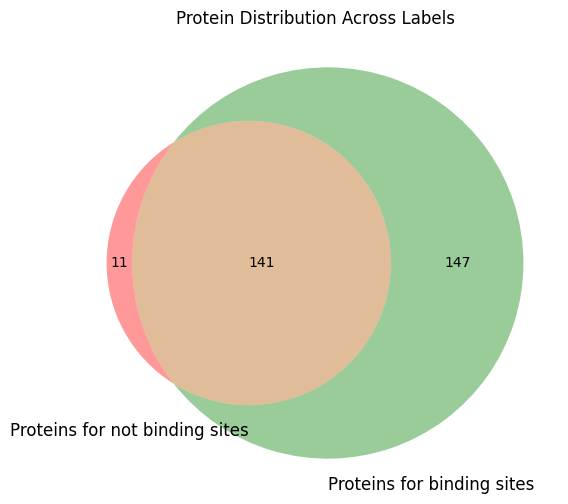

In [15]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd

def plot_protein_venn(df, protein_col='human homology accession', label_col='label'):
    # Get sets of proteins for each label
    label_0_proteins = set(df[df[label_col] == 0][protein_col])
    label_1_proteins = set(df[df[label_col] == 1][protein_col])
    
    # Create Venn diagram
    plt.figure(figsize=(10, 6))
    venn2([label_0_proteins, label_1_proteins], 
          set_labels=('Proteins for not binding sites', 'Proteins for binding sites'))
    plt.title('Protein Distribution Across Labels')
    
    # Display counts
    print(f"Label 0 unique proteins: {len(label_0_proteins)}")
    print(f"Label 1 unique proteins: {len(label_1_proteins)}")
    print(f"Overlapping proteins: {len(label_0_proteins.intersection(label_1_proteins))}")
    
    plt.show()
    
plot_protein_venn(curated_dataset_df, protein_col='human homology accession', label_col='label')

In [16]:
# calculate the site frequency per protein

import pandas as pd

# Load the dataset
curated_dataset_df = pd.read_csv("data/Table 1.csv")

# Filter the dataset to include only positive labels
curated_dataset_df_positive = curated_dataset_df[curated_dataset_df["label"] == 1]

# Group by "human homology accession" and calculate the count of each unique protein ID
protein_counts = curated_dataset_df_positive.groupby("human homology accession").size().reset_index(name='count')

protein_counts["count"].value_counts()

count
1    166
2     88
3     25
4      6
5      3
Name: count, dtype: int64

Task 3: We curated a dataset from BioGrid, which includes all 14-3-3 binding proteins reported in the literature.

In [17]:
# get all the human protein which interaction with 14-3-3

# download protein protein interaction dataset from Biogrid
# Read the tab-separated file into a DataFrame

file_path = "data/BIOGRID-ALL-4.4.237.mitab.zip"

biogrid = pd.read_csv(file_path, delimiter='\t', encoding='utf-8')

# Display the DataFrame
biogrid.head(2)

,#ID Interactor A,ID Interactor B,Alt IDs Interactor A,Alt IDs Interactor B,Aliases Interactor A,Aliases Interactor B,Interaction Detection Method,Publication 1st Author,Publication Identifiers,Taxid Interactor A,Taxid Interactor B,Interaction Types,Source Database,Interaction Identifiers,Confidence Values
0,entrez gene/locuslink:6416,entrez gene/locuslink:2318,biogrid:112315|entrez gene/locuslink:MAP2K4|un...,biogrid:108607|entrez gene/locuslink:FLNC|unip...,entrez gene/locuslink:JNKK(gene name synonym)|...,entrez gene/locuslink:ABP-280(gene name synony...,"psi-mi:""MI:0018""(two hybrid)",Marti A (1997),pubmed:9006895,taxid:9606,taxid:9606,"psi-mi:""MI:0407""(direct interaction)","psi-mi:""MI:0463""(biogrid)",biogrid:103,-
1,entrez gene/locuslink:84665,entrez gene/locuslink:88,biogrid:124185|entrez gene/locuslink:MYPN|unip...,biogrid:106603|entrez gene/locuslink:ACTN2|uni...,entrez gene/locuslink:CMD1DD(gene name synonym...,entrez gene/locuslink:CMD1AA(gene name synonym),"psi-mi:""MI:0018""(two hybrid)",Bang ML (2001),pubmed:11309420,taxid:9606,taxid:9606,"psi-mi:""MI:0407""(direct interaction)","psi-mi:""MI:0463""(biogrid)",biogrid:117,-


In [18]:
# select all the interaction happening between human proteins
biogrid = biogrid[(biogrid['Taxid Interactor A'] == "taxid:9606")&(biogrid['Taxid Interactor B'] == "taxid:9606")]
import pandas as pd
import re
def extract_and_clean_uniprot_id(text):
    # Regex pattern to match exampe: 'uniprot/swiss-prot:P45985'
    match = re.search(r'uniprot/swiss-prot:([\w\d]+)', text)
    return match.group(1) if match else None

# Apply the function to the DataFrame columns
biogrid['Uniprot ID A'] = biogrid['Alt IDs Interactor A'].apply(extract_and_clean_uniprot_id)
biogrid['Uniprot ID B'] = biogrid['Alt IDs Interactor B'].apply(extract_and_clean_uniprot_id)
biogrid_interactions = biogrid[['Uniprot ID A','Uniprot ID B']]
biogrid_interactions.head(2)

,Uniprot ID A,Uniprot ID B
0,P45985,Q14315
1,Q86TC9,P35609


In [19]:
# there are totally 1760 human protein interaction with human 14-3-3s
Protins_1433 = ["P62258", "P27348", "Q04917", "P61981", "P31946", "P31947", "P63104"]
Protein_1433_interactome_df = biogrid_interactions[biogrid_interactions["Uniprot ID A"].isin(Protins_1433)]
Protein_1433_interactome = set(Protein_1433_interactome_df["Uniprot ID B"])
len(Protein_1433_interactome)

1760

In [20]:
# save the 1433_interactome as a dataset

task 4: Using Gene Ontology (GO) analysis, we discovered that these proteins are associated with several GO terms related to condensation, including non-membrane-bounded organelles 

In [21]:
df = pd.read_csv("data/Table 1.csv")
df_1433 = df[df["label"]==1]
Protein_1433_interactome_known_motif = set(df_1433["human homology accession"]) 
len(Protein_1433_interactome_known_motif)

288

In [22]:
# Gene Ontology (GO) analysis

In [23]:
# # Install gprofiler-official
# !pip install gprofiler-official

In [24]:
from gprofiler import GProfiler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to transform p-values to -log10(p-value)
def transform_pvalues(df):
    df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
    return df

def go_analysis(uniprot_ids):
    # Initialize g:Profiler
    gp = GProfiler(return_dataframe=True)

    # Convert UniProt IDs to Gene Symbols (using g:Convert)
    converted_ids = gp.convert(organism='hsapiens', query=uniprot_ids, target_namespace='ENTREZGENE_ACC')

    # Extract the gene symbols
    gene_symbols = converted_ids['converted'].tolist()
#     print("Converted Gene Symbols:", gene_symbols)

    # Perform GO enrichment analysis using the converted gene symbols
    BP_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:BP'])
    MF_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:MF'])
    CC_go_results = gp.profile(organism='hsapiens', query=gene_symbols, sources=['GO:CC'])

    # Display results
#     print(go_results.head())

    # Optional: Visualize the top 10 GO terms
    import matplotlib.pyplot as plt
    import seaborn as sns
    
#     print(BP_go_results)
    # Select top terms
    BP_top_go_terms = BP_go_results.head(20)
    MF_top_go_terms = MF_go_results.head(20)
    CC_top_go_terms = CC_go_results.head(20)

    # Transform p-values to -log10(p-value)
    BP_top_go_terms = transform_pvalues(BP_top_go_terms)
    MF_top_go_terms = transform_pvalues(MF_top_go_terms)
    CC_top_go_terms = transform_pvalues(CC_top_go_terms)

    # Combine data into a single DataFrame
    BP_top_go_terms['Category'] = 'Biological Process'
    MF_top_go_terms['Category'] = 'Molecular Function'
    CC_top_go_terms['Category'] = 'Cellular Component'

    combined_df = pd.concat([BP_top_go_terms, MF_top_go_terms, CC_top_go_terms])

    # Create a plot
    plt.figure(figsize=(14, 12))

    # Create a bar plot with custom width
    sns.barplot(
        data=combined_df,
        y='name',
        x='-log10(p-value)',
        hue='Category',
        palette={'Biological Process': 'skyblue', 'Molecular Function': 'lightgreen', 'Cellular Component': 'salmon'},
        dodge=False  # This ensures that bars are not split by hue
    )

    # Adjust bar width by setting the aspect ratio
    plt.gca().set_aspect('auto', adjustable='box')

    # Title and labels
    plt.title('Top GO Terms by Category')
    plt.xlabel('-log10(p-value)')
    plt.ylabel('GO Term')

#     # Invert y-axis
#     plt.gca().invert_yaxis()

    # Add a legend
    plt.legend(title='GO Category')

    # Show the plot
    plt.tight_layout()
    plt.show()

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yc

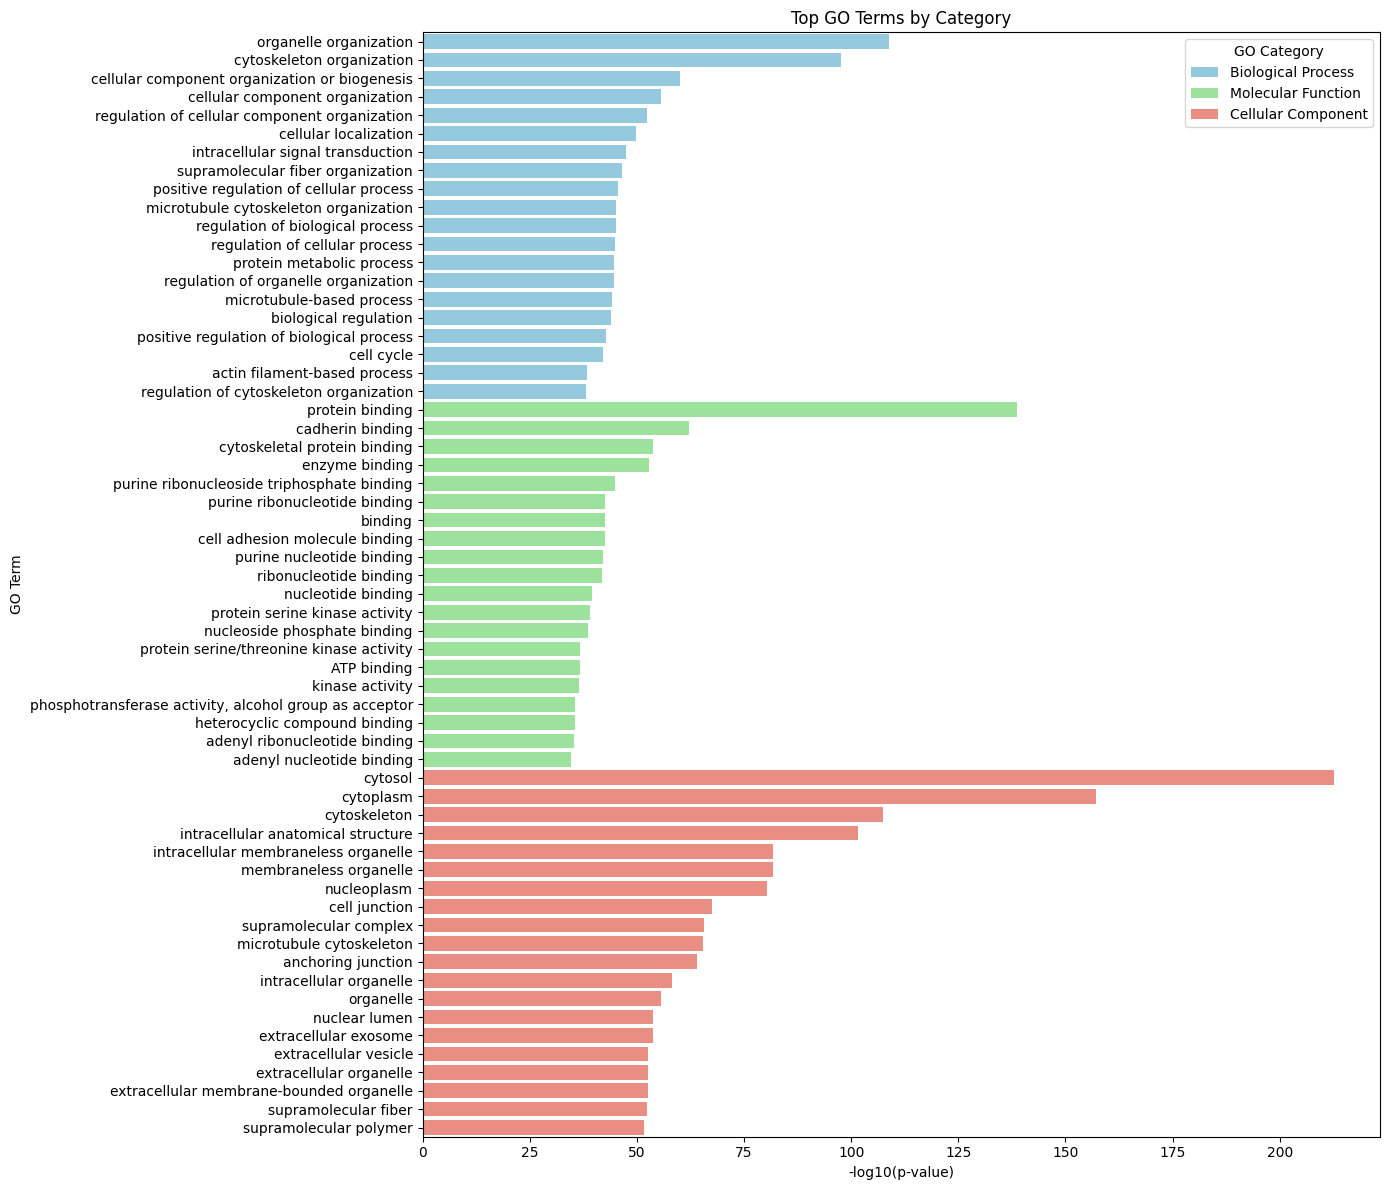

In [25]:
# GO analysis of 14-3-3 binding dataset from BioGrid
go_analysis(list(Protein_1433_interactome))

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/431369735.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['-log10(p-value)'] = -np.log10(df['p_value'].replace(0, np.nan))  # Replace 0 with NaN to avoid -inf values
/var/folders/jl/gnkp_hvs3zqb957750yc

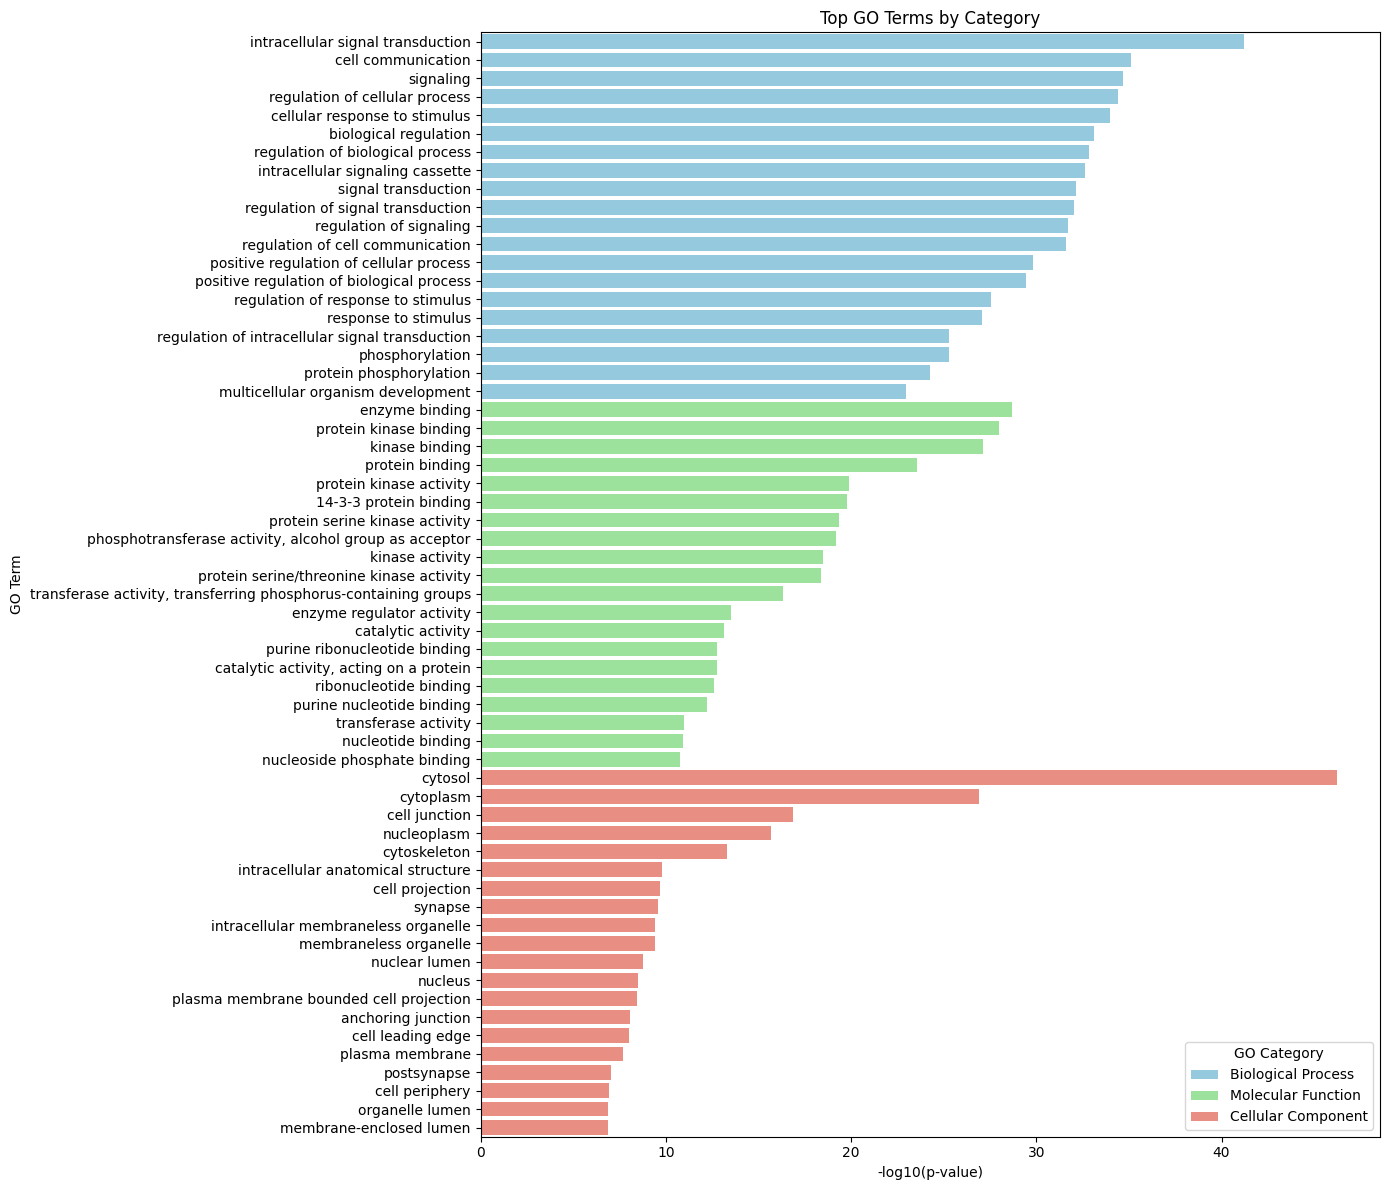

In [26]:
# GO analysis of 14-3-3 binding dataset curated by this paper
go_analysis(list(Protein_1433_interactome_known_motif))

Task 5: We also conducted KEGG analysis on both 14-3-3 binding proteins and BioGrid 14-3-3 binding proteins.

In [27]:
# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Perform enrichment for your own proteins and BioGrid proteins separately
results_my_proteins = gp.profile(
    organism='hsapiens',  # Homo sapiens. Change based on your organism.
    query=list(Protein_1433_interactome_known_motif),
    sources=['KEGG'])  # Specify to use KEGG pathways

# Ensure the results are DataFrame
if not isinstance(results_my_proteins, pd.DataFrame):
    raise TypeError('Expected the results of my_proteins to be a DataFrame.')

results_biogrid_proteins = gp.profile(
    organism='hsapiens',
    query=list(Protein_1433_interactome),
    sources=['KEGG'])

# Ensure the results are DataFrame
if not isinstance(results_biogrid_proteins, pd.DataFrame):
    raise TypeError('Expected the results of biogrid_proteins to be a DataFrame.')
    

# Function to convert list columns to strings
def convert_list_columns_to_string(df, columns):
    for col in columns:
        if col in df.columns and df[col].apply(lambda x: isinstance(x, list)).any():
            df[col] = df[col].apply(lambda x: ','.join(map(str, x)) if isinstance(x, list) else x)
    return df

# Columns to convert
columns_to_convert = ['native', 'parents']

# Convert list columns to strings in both DataFrames
results_my_proteins = convert_list_columns_to_string(results_my_proteins, columns_to_convert)
results_biogrid_proteins = convert_list_columns_to_string(results_biogrid_proteins, columns_to_convert)

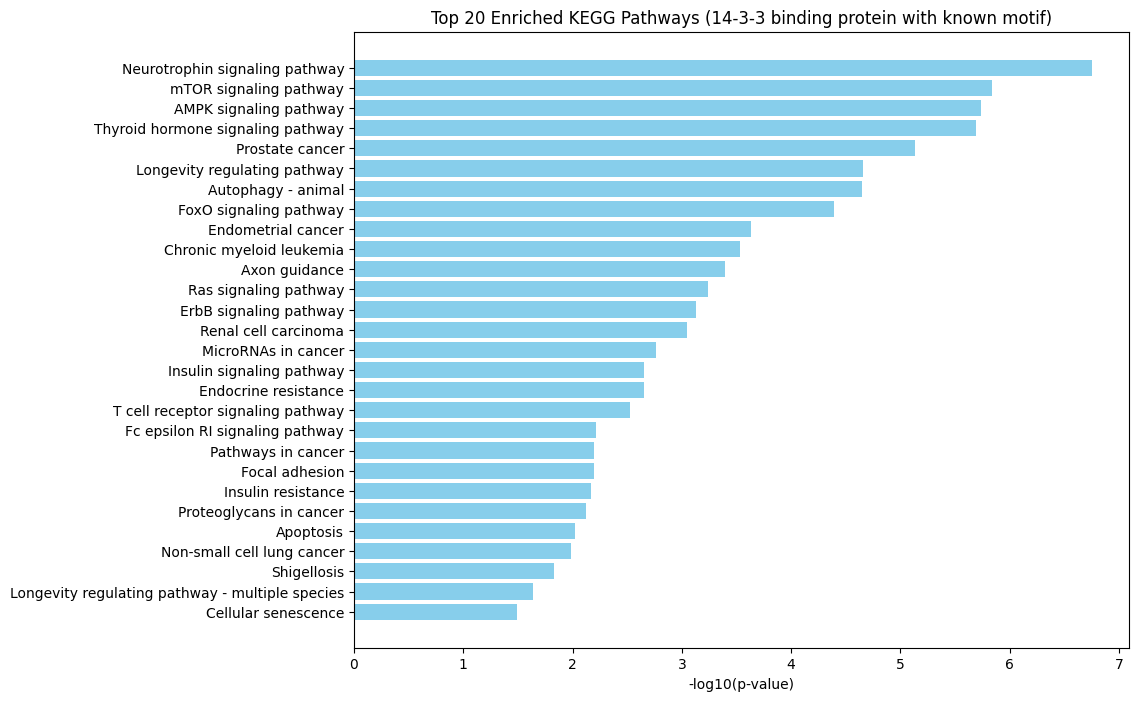

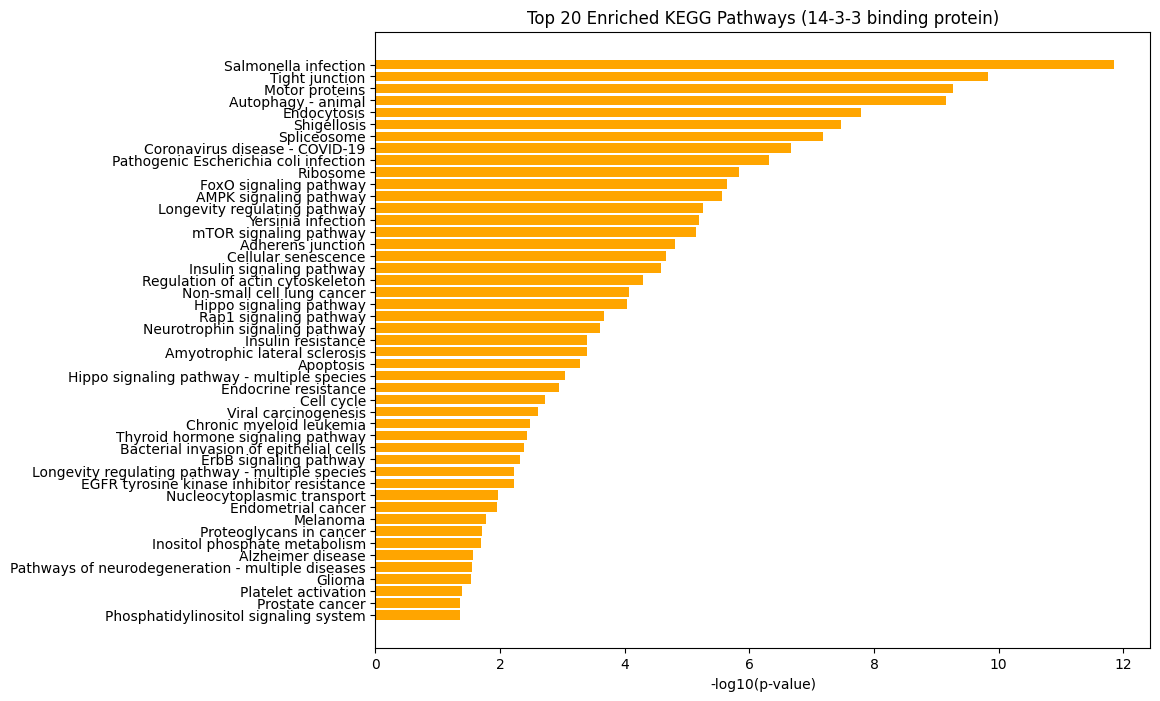

In [28]:
# Select top pathways based on adjusted p-value
top_my_proteins = results_my_proteins.sort_values(by='p_value').head(50)
top_biogrid_proteins = results_biogrid_proteins.sort_values(by='p_value').head(50)

# Plot the results for my_proteins
plt.figure(figsize=(10, 8))
plt.barh(top_my_proteins['name'], -np.log10(top_my_proteins['p_value']), color='skyblue')
plt.xlabel('-log10(p-value)')
plt.title('Top 20 Enriched KEGG Pathways (14-3-3 binding protein with known motif)')
plt.gca().invert_yaxis()
plt.show()

# Plot the results for biogrid_proteins
plt.figure(figsize=(10, 8))
plt.barh(top_biogrid_proteins['name'], -np.log10(top_biogrid_proteins['p_value']), color='orange')
plt.xlabel('-log10(p-value)')
plt.title('Top 20 Enriched KEGG Pathways (14-3-3 binding protein)')
plt.gca().invert_yaxis()
plt.show()

In [29]:
# common pathway in 14-3-3 binding and 14-3-3 binding with known motif dataset
set(top_my_proteins['name'])&set(top_biogrid_proteins['name'])

{'AMPK signaling pathway',
 'Apoptosis',
 'Autophagy - animal',
 'Cellular senescence',
 'Chronic myeloid leukemia',
 'Endocrine resistance',
 'Endometrial cancer',
 'ErbB signaling pathway',
 'FoxO signaling pathway',
 'Insulin resistance',
 'Insulin signaling pathway',
 'Longevity regulating pathway',
 'Longevity regulating pathway - multiple species',
 'Neurotrophin signaling pathway',
 'Non-small cell lung cancer',
 'Prostate cancer',
 'Proteoglycans in cancer',
 'Shigellosis',
 'Thyroid hormone signaling pathway',
 'mTOR signaling pathway'}

## Analysis of Protein Condensation Potential and Phase Separation Properties

Task 6: Download the predicted condensation scores from Picnic, DeePhase, and PhaSePred.

In [30]:
# download picnic data from https://picnic.cd-code.org/download/
# get the picnic value for each unique id
df_picnic = pd.read_csv('data/PICNIC-9606-data.csv')
df_picnic.head(2)

,ID,PICNIC score,PICNIC GO score,Uniprot ID,Proteins,Genes,Organism,Organism ID,CD-Code included
0,A0A024R1R8,0.851484,0.771362,A0A024R1R8,Translation machinery-associated protein 7 (Co...,LOC112268293 hCG_2014768,Homo sapiens (Human),9606,False
1,A0A024RBG1,0.689599,0.770870,A0A024RBG1,Diphosphoinositol polyphosphate phosphohydrola...,NUDT4B,Homo sapiens (Human),9606,False


In [31]:
# download DeePhase dataset
# import pandas as pd
# import requests
# import os

# # URL of the raw file
# url = 'https://github.com/kadiliissaar/DeePhase/raw/main/Paper_code/Predictions/Swissprot/all_predictions.csv'

# # Define the filename and the path to save it
# filename = 'all_predictions.csv'
# save_path = os.path.join('data', filename)

# # Create the 'data' directory if it does not exist
# os.makedirs('data', exist_ok=True)

# # Download the file
# response = requests.get(url)
# response.raise_for_status()  # Ensure we notice bad responses

# # Save the content of the response to a file in the data directory
# with open(save_path, 'wb') as f:
#     f.write(response.content)

# print(f"Downloaded file: {save_path}")

# Read the CSV file into a DataFrame
df_DeePhase = pd.read_csv('data/all_prediction_with_docker_deephase_score.csv')
# df_DeePhase = pd.read_csv('data/all_predictions.csv')


# Display the first few rows of the DataFrame
df_DeePhase.head(2)

,prediction_phys_1,Sequence,Uniprot_ID,Category,prediction_phys_2,prediction_phys_multi,prediction_w2v_1,prediction_w2v_2,prediction_w2v_multi,sequence_final,docker_score
0,0.20,MESNHKSGDGLSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPG...,Q9NQ94,Swiss-Prot,0.31,0.237093,0.562697,0.700156,0.529143,MESNHKSGDGLSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPG...,"(0.211, 0.552, 0.382)"
1,0.04,MWAQLLLGMLALSPAIAEELPNYLVTLPARLNFPSVQKVCLDLSPG...,A8K2U0,Swiss-Prot,0.45,0.105490,0.558333,0.732476,0.574357,MWAQLLLGMLALSPAIAEELPNYLVTLPARLNFPSVQKVCLDLSPG...,"(0.159, 0.761, 0.46)"


In [32]:
# seperate docker socre:
# Step 1: Remove the parentheses
df_DeePhase['docker_score'] = df_DeePhase['docker_score'].str.strip('()')

# Step 2: Split the string by commas and expand into separate columns
df_DeePhase[['docker_score_phys_multi', 'docker_score_w2v_multi', 'docker_score_DeePhase']] = df_DeePhase['docker_score'].str.split(',', expand=True)

# Step 3: Convert the new columns to numeric (if needed)
df_DeePhase[['docker_score_phys_multi', 'docker_score_w2v_multi', 'docker_score_DeePhase']] = df_DeePhase[['docker_score_phys_multi', 'docker_score_w2v_multi', 'docker_score_DeePhase']].apply(pd.to_numeric)

df_DeePhase.head(2)

,prediction_phys_1,Sequence,Uniprot_ID,Category,prediction_phys_2,prediction_phys_multi,prediction_w2v_1,prediction_w2v_2,prediction_w2v_multi,sequence_final,docker_score,docker_score_phys_multi,docker_score_w2v_multi,docker_score_DeePhase
0,0.20,MESNHKSGDGLSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPG...,Q9NQ94,Swiss-Prot,0.31,0.237093,0.562697,0.700156,0.529143,MESNHKSGDGLSGTQKEAALRALVQRTGYSLVQENGQRKYGGPPPG...,"0.211, 0.552, 0.382",0.211,0.552,0.382
1,0.04,MWAQLLLGMLALSPAIAEELPNYLVTLPARLNFPSVQKVCLDLSPG...,A8K2U0,Swiss-Prot,0.45,0.105490,0.558333,0.732476,0.574357,MWAQLLLGMLALSPAIAEELPNYLVTLPARLNFPSVQKVCLDLSPG...,"0.159, 0.761, 0.46",0.159,0.761,0.460


In [33]:
# PhaSePred
# ### download the dataset    
# import pandas as pd
# import requests
# import os

# # URL of the raw file
# url = 'http://predict.phasep.pro/static/phasepred/database/human_reviewed.zip'

# # Define the filename and the path to save it
# zip_filename = 'human_reviewed.zip'
# save_path = os.path.join('data', zip_filename)

# # Create the 'data' directory if it does not exist
# os.makedirs('data', exist_ok=True)

# # Download the file
# response = requests.get(url)
# response.raise_for_status()  # Ensure we notice bad responses

# # Save the content of the response to a file in the data directory
# with open(save_path, 'wb') as f:
#     f.write(response.content)

# print(f"Downloaded file: {save_path}")

In [34]:
# human_reviewed.zip is a json file
import zipfile
import json
import pandas as pd
import os

# Specify the path to your zip file and the output directory
zip_file_path = 'data/human_reviewed.zip'

import pandas as pd
import json
from collections import defaultdict

def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

def process_data(data):
    flattened_data = defaultdict(dict)
    
    for key, value in data.items():
        flat = flatten_dict(value)
        for k, v in flat.items():
            flattened_data[k][key] = v
    
    return pd.DataFrame(flattened_data)


# Define the output directory (can be the same directory as the zip file or any other)
output_directory = os.path.splitext(zip_file_path)[0]  # This will remove the .zip extension

#
print(output_directory)

# Ensure the output directory exists
os.makedirs(output_directory, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_directory)

# Read JSON file
json_file_path = os.path.join(output_directory, 'human_reviewed.json')  # adjust according to your actual file name

with open(json_file_path, 'r') as file:
    data = json.load(file)

# Process the data and create DataFrame
df_PhaSePred = process_data(data)

# Display the first few rows of the DataFrame
df_PhaSePred.head(2)

data/human_reviewed


,Entry name,Status,Gene names,Organism,Sequence,catGRANULE_residue,catGRANULE_single,catGRANULE_start,catGRANULE_end,catGRANULE_rnk,...,PhaSePred_SaPS-10fea,PhaSePred_PdPS-10fea,PhaSePred_SaPS-8fea_rnk,PhaSePred_PdPS-8fea_rnk,PhaSePred_SaPS-10fea_rnk,PhaSePred_PdPS-10fea_rnk,InterPro_PfamID,InterPro_domain,InterPro_start,InterPro_end
Q9H553,ALG2_HUMAN,reviewed,ALG2 UNQ666/PRO1298,Homo sapiens (Human),MAEEQGRERDSVPKPSVLFLHPDLGVGGAERLVLDAALALQARGCS...,"-5.0075,-4.3359,-3.8836,-3.6662,-3.655,-3.6775...",-0.131076,[],[],0.298061,...,0.068929,0.099901,0.156564,0.200098,0.426748,0.433865,"[PF13439, PF00534]","[Glycosyltransferase subfamily 4-like, N-termi...","[26, 216]","[189, 392]"
Q96QF7,ACRC_HUMAN,reviewed,GCNA ACRC,Homo sapiens (Human),MDGCKKELPRLQEPEEDEDCYILNVQSSSDDTSGSSVARRAPKRQA...,"-6.6667,-6.0269,-5.7194,-5.5569,-5.4324,-5.405...",1.051820,"[140, 172, 449, 522]","[159, 222, 505, 535]",0.906454,...,0.213236,0.362276,0.871264,0.967362,0.742773,0.705521,[PF10263],[SprT-like],[523],[625]


In [35]:
# df_PhaSePred.columns

In [36]:
score_columns = ['uniprot_id','Sequence',
                 'catGRANULE_single','PLAAC_NLLR',
                   'PScore_single', 
                   'ESpritz-DisProt_single',
                   'Hydropathy_single',
                   'DeepCoil_single',
                   'SEG_single',
                   'Charged residue_FCR', 'Phos_single','PhaSePred_SaPS-8fea', 'PhaSePred_PdPS-8fea',
                   'PhaSePred_SaPS-10fea', 'PhaSePred_PdPS-10fea',
                   'PhaSePred_SaPS-8fea_rnk', 'PhaSePred_PdPS-8fea_rnk',
                   'PhaSePred_SaPS-10fea_rnk', 'PhaSePred_PdPS-10fea_rnk']

df_PhaSePred['uniprot_id'] = df_PhaSePred.index

df_PhaSePred = df_PhaSePred[score_columns]

task 7: compared condensation propensity of 14-3-3 binding proteins with entire proteome condensation propensities. 

task 8: comparison of the condensation propensity scores of proteins in BioGrid dataset with proteins in the human proteome 

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def distribution_go(gene_list, listname, df, score, ID):
    # Filter scores for the specific list of genes
    df_list_genes = df[df[ID].isin(gene_list)]
    
    # Create a figure with a specific style
    plt.figure(figsize=(16, 9))
    sns.set_style("whitegrid")

    whole_proteome_scores = df[score].to_numpy().flatten()
    list_scores = df_list_genes[score].to_numpy().flatten()
    
    # Plot the score distribution for the entire gene set
    sns.histplot(whole_proteome_scores, color='#FFA07A', label='Whole Human Proteome', 
                 bins=40, alpha=0.6, stat='density', kde=False)  # Disable KDE in histplot
    
    # Add KDE separately
    # sns.kdeplot(whole_proteome_scores, color='#FFA07A', label='_nolegend_')  # Add KDE for the whole proteome
    
    # Plot the score distribution for the specific list of genes
    sns.histplot(list_scores, color='#4682B4', label=listname, 
                 bins=40, stat='density', kde=False)  # Disable KDE in histplot
    
    # Add KDE separately
    # sns.kdeplot(list_scores, color='#4682B4', label='_nolegend_')  # Add KDE for the gene list
    
    # Title and labels with improved fonts
    plt.title(f'Score Distribution: {listname} vs Whole Human Proteome', 
              fontsize=20, fontweight='bold', pad=20)
    plt.xlabel(score, fontsize=14, fontweight='bold')
    plt.ylabel('Density', fontsize=14, fontweight='bold')
    
    # Improve tick labels
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add a legend with improved appearance
    plt.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.9)
    
    # Add a text box with statistics
    stats_text = f"{listname} stats:\nMean: {df_list_genes[score].mean():.2f}\nMedian: {df_list_genes[score].median():.2f}"
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
             verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Improve layout and display
    plt.tight_layout()
    plt.show()

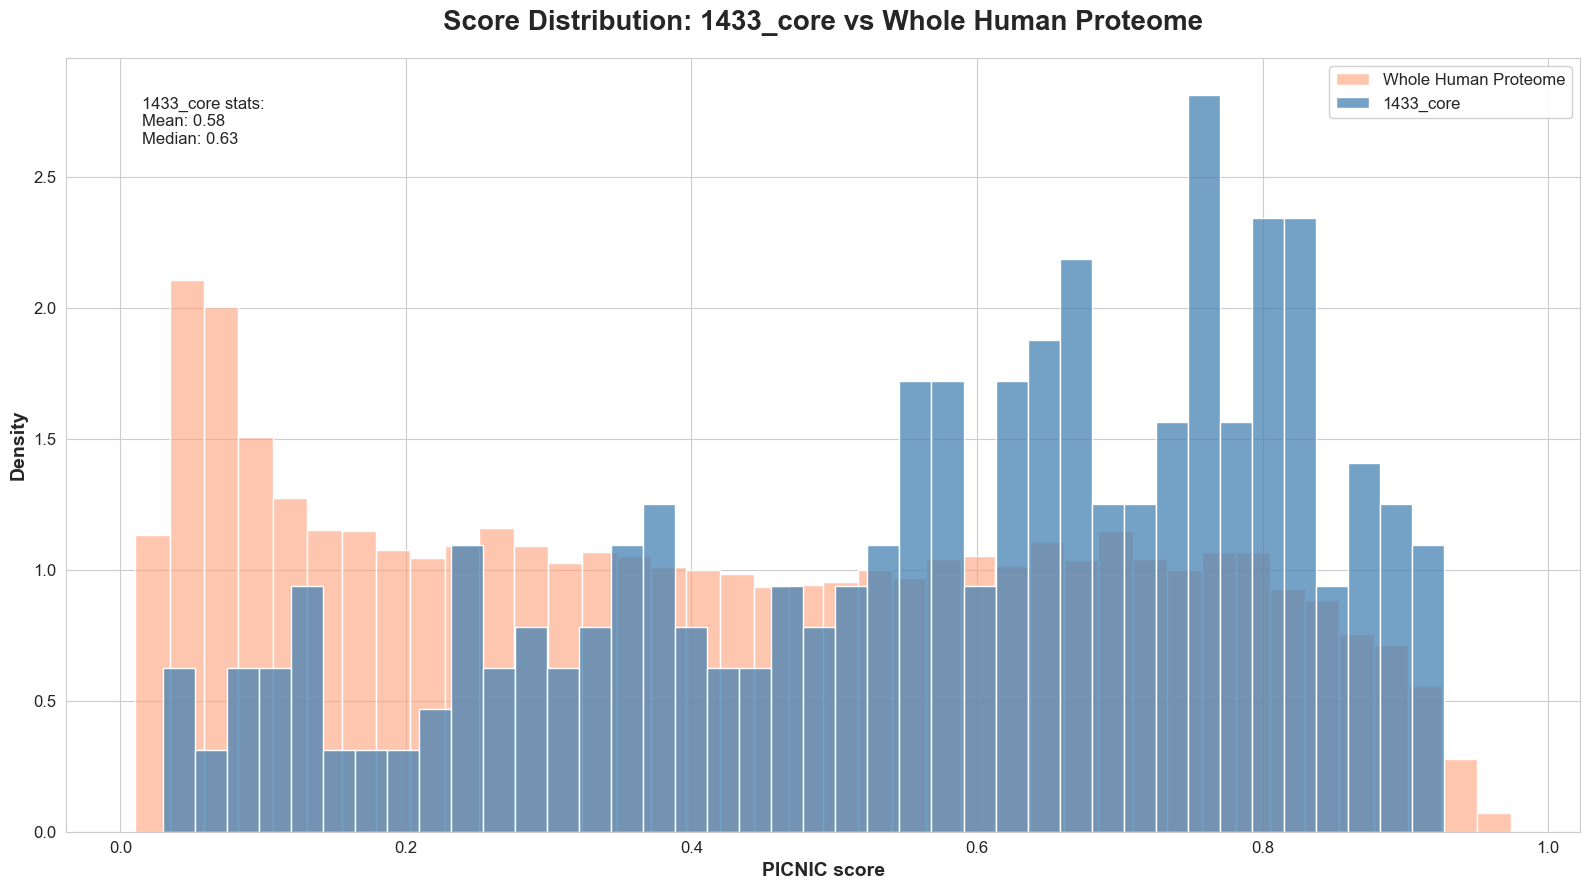

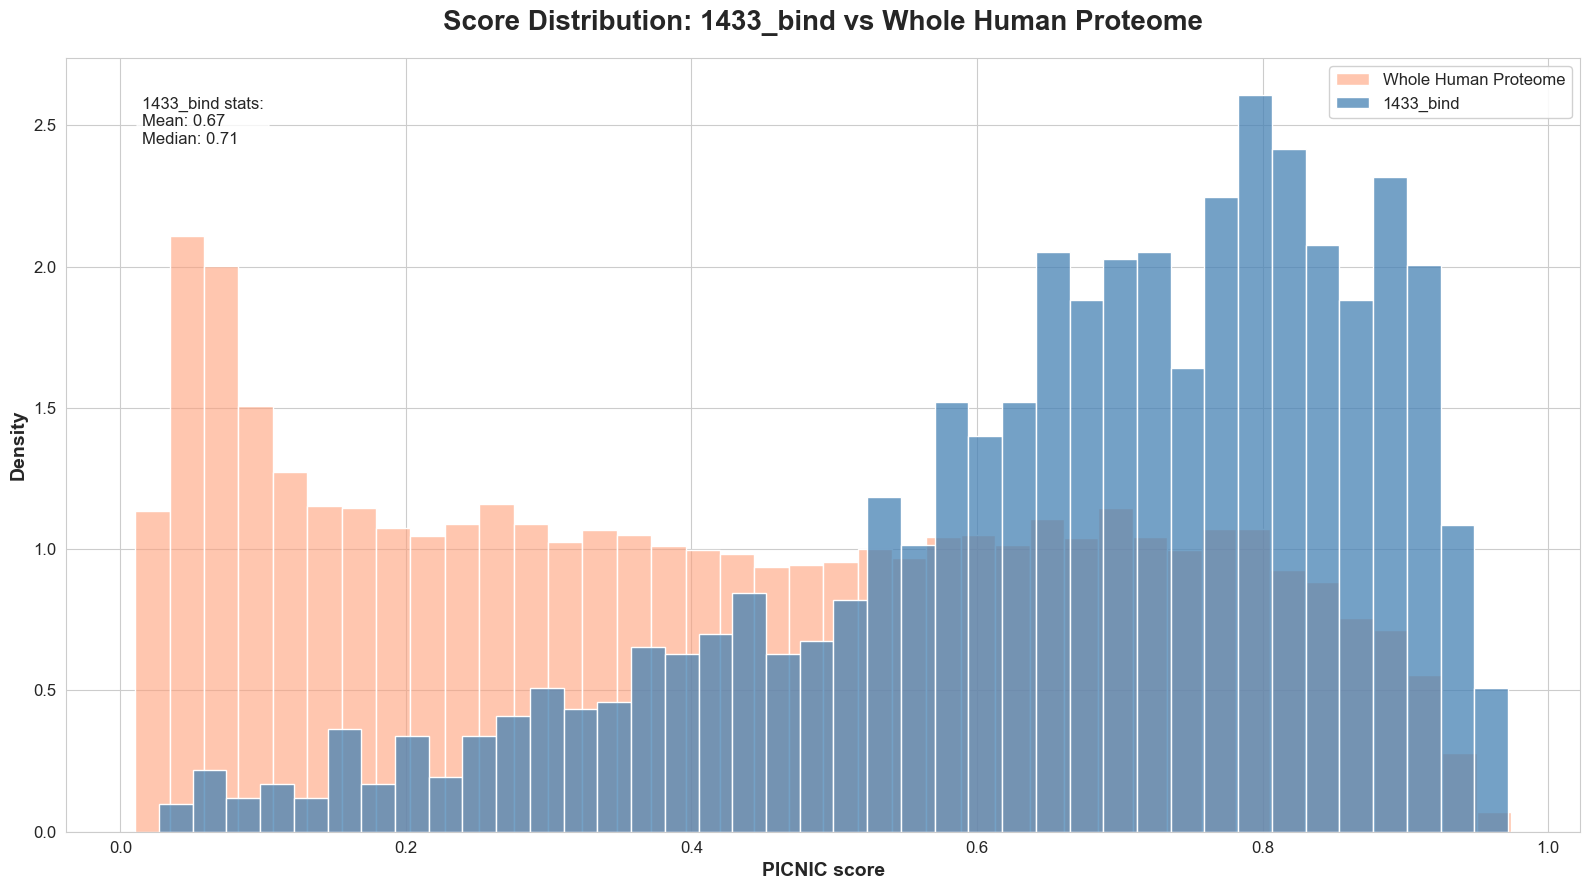

In [38]:
# picnic score
# two score using here: Picnic socre and picnic go score
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_picnic,"PICNIC score", 'Uniprot ID')
distribution_go(Protein_1433_interactome,"1433_bind",df_picnic, "PICNIC score", 'Uniprot ID')

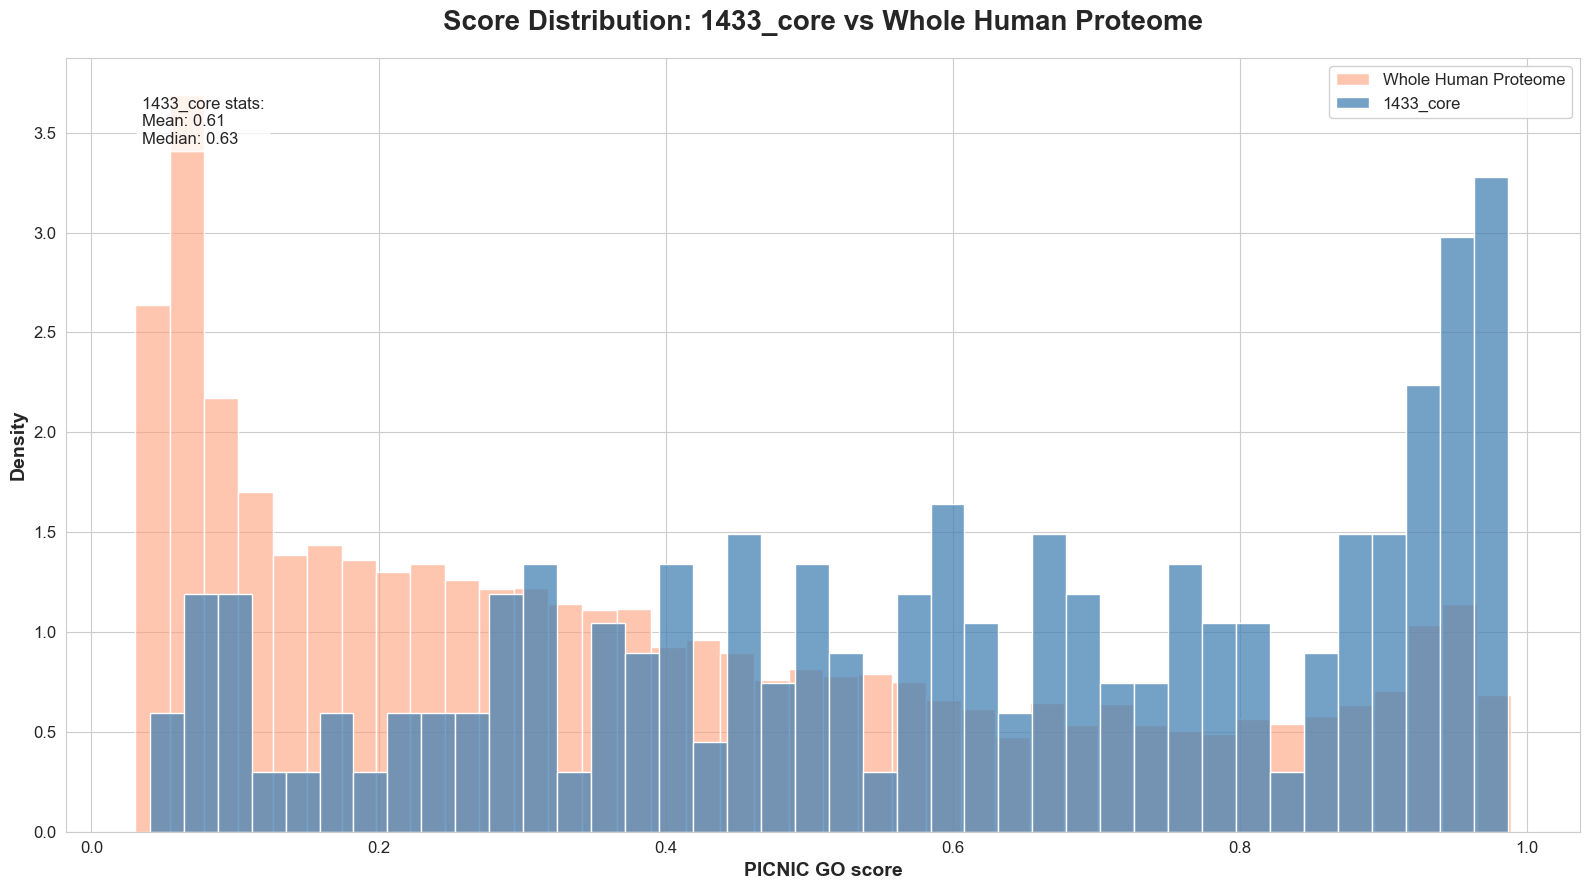

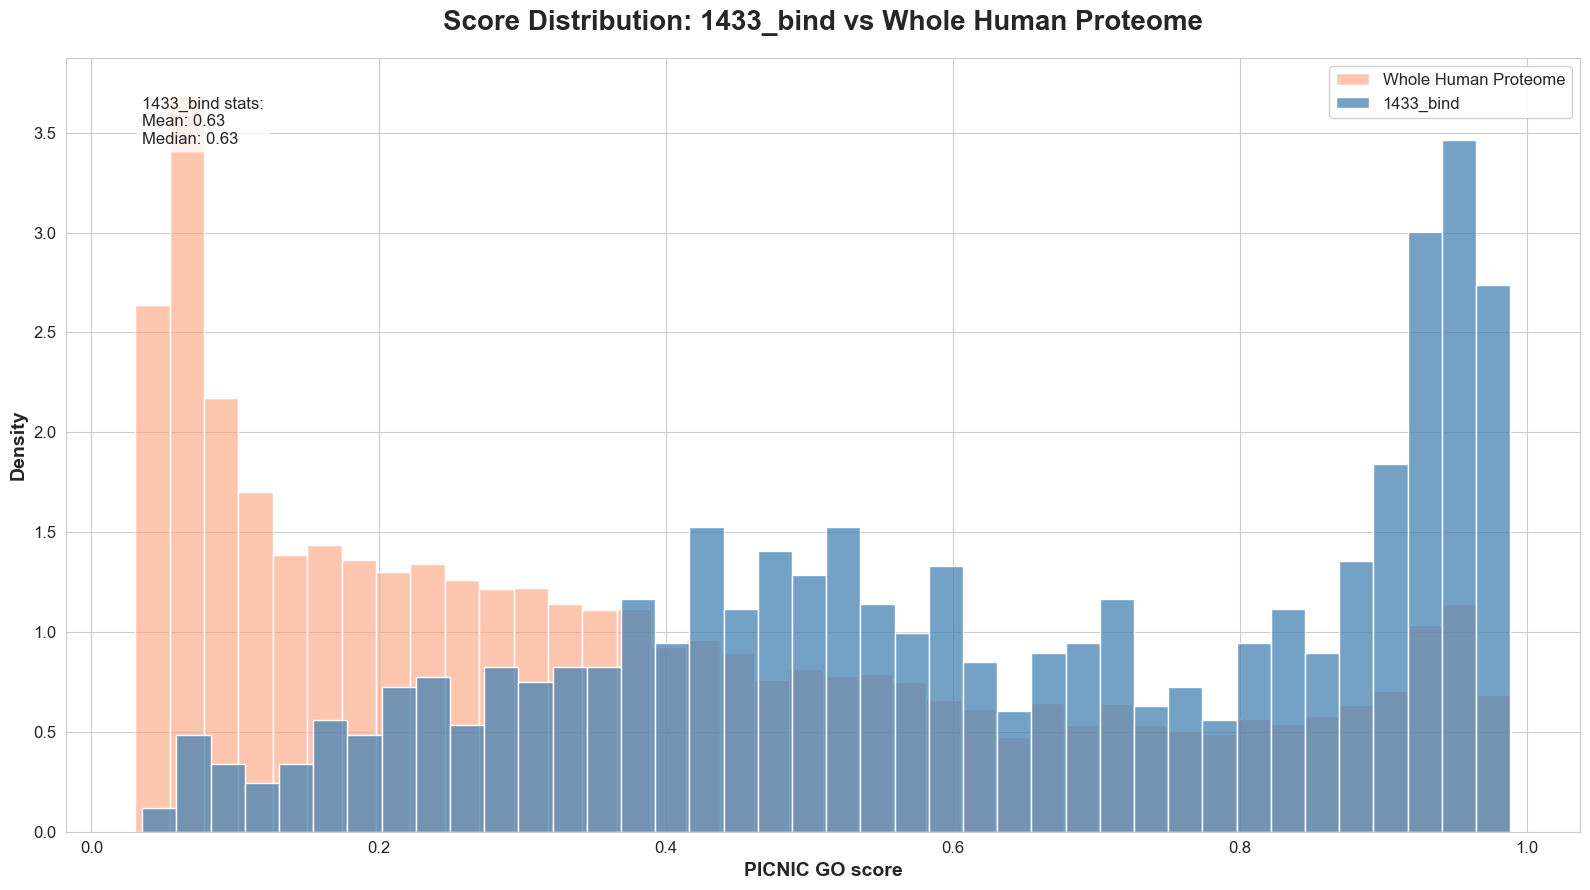

In [39]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_picnic,"PICNIC GO score", 'Uniprot ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_picnic, "PICNIC GO score", 'Uniprot ID')

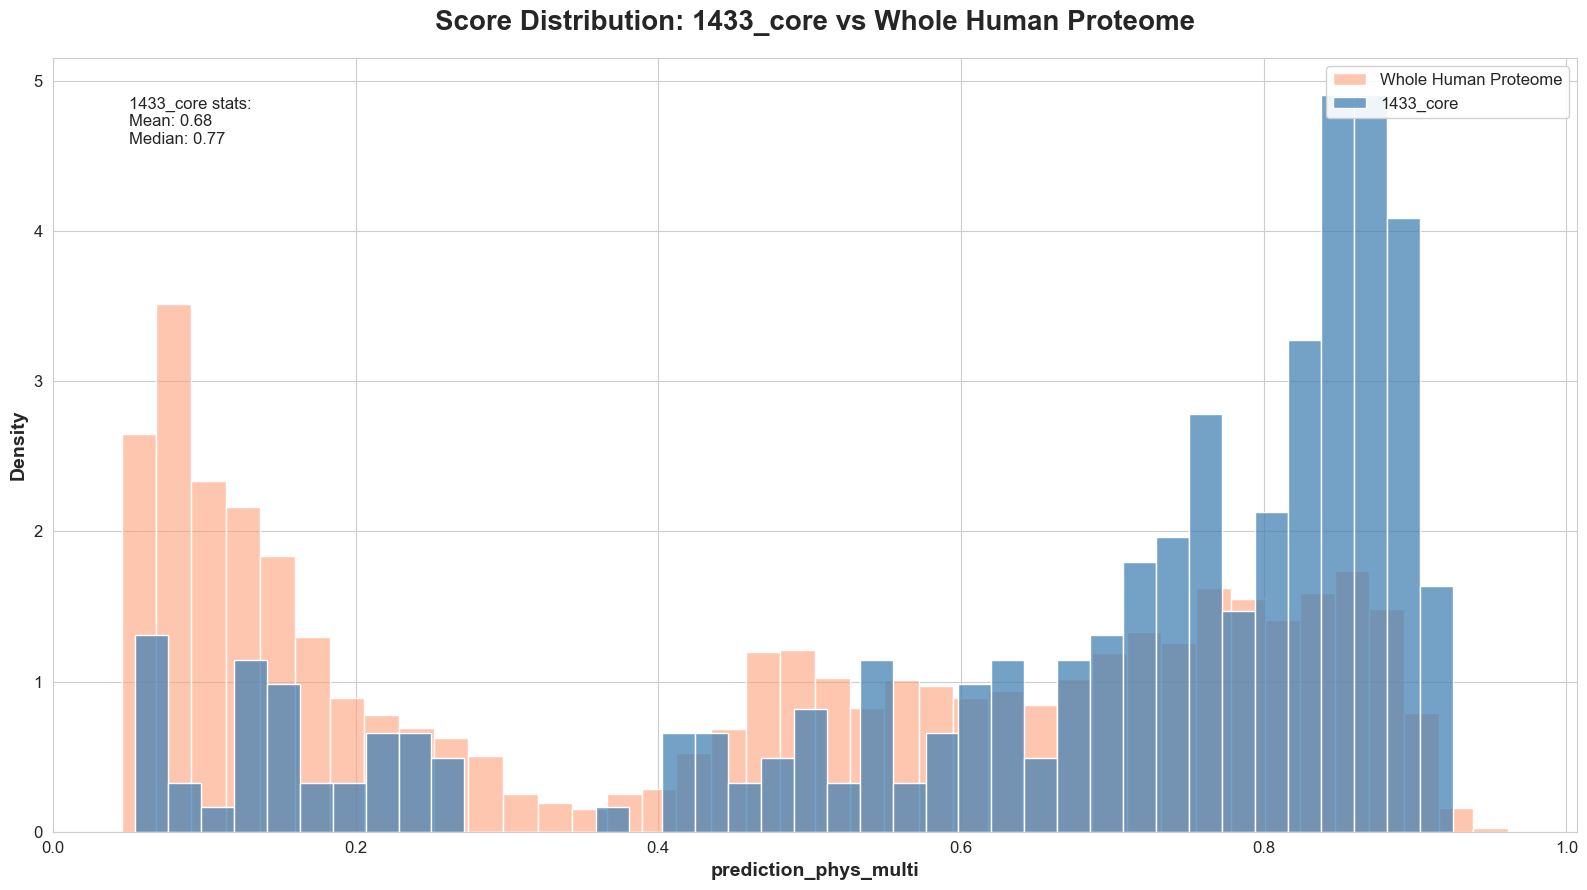

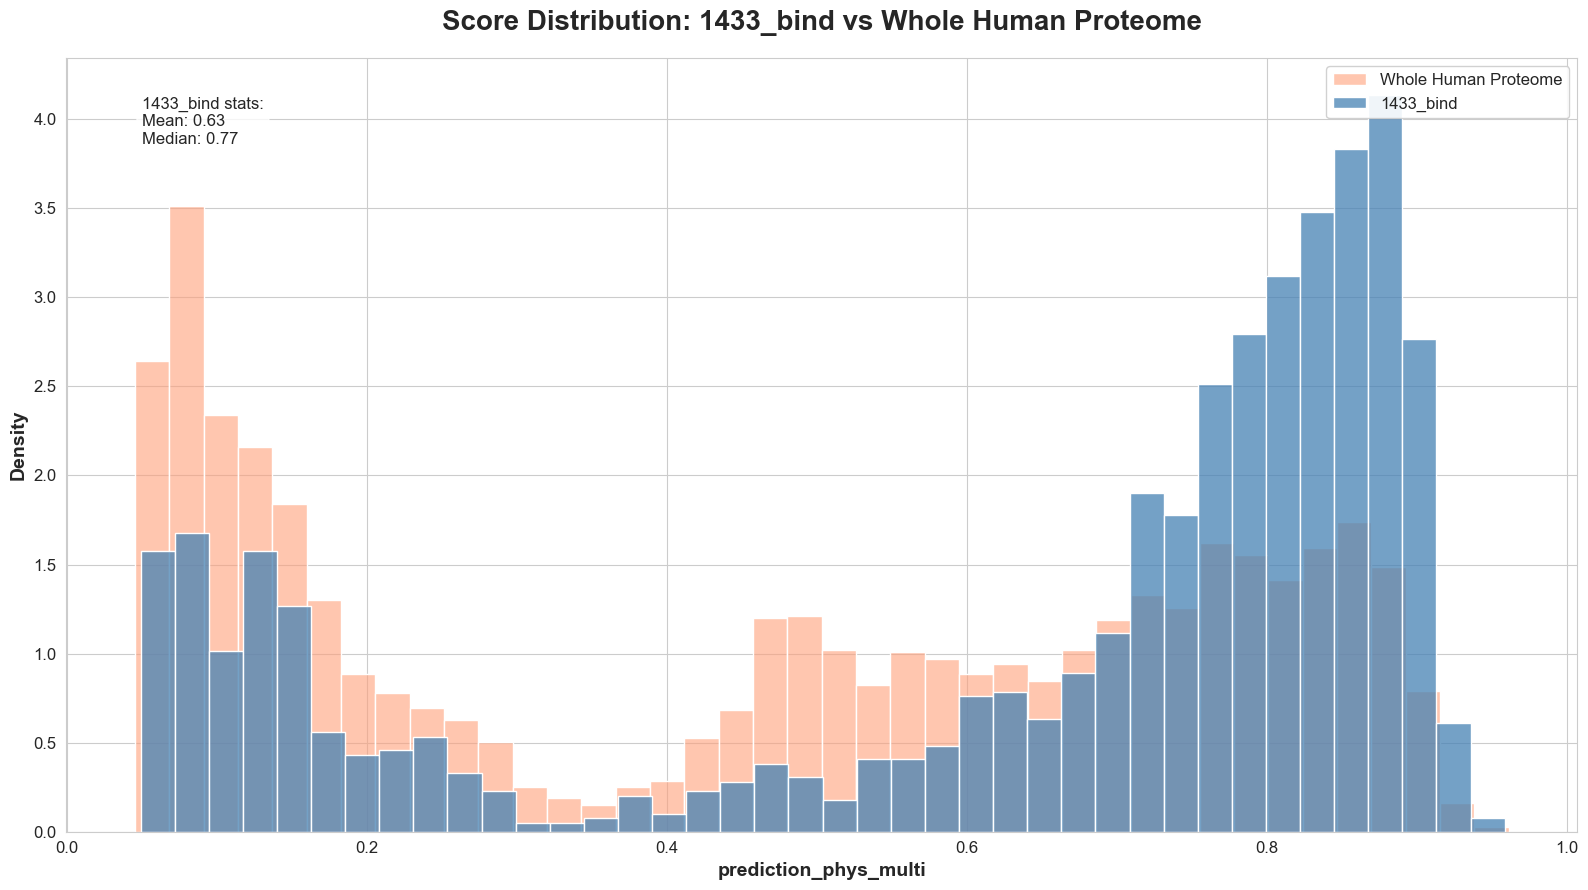

In [40]:
# deephase score
# two score using here: prediction_phys_multi socre and prediction_w2v_multi score
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"prediction_phys_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"prediction_phys_multi", 'Uniprot_ID')

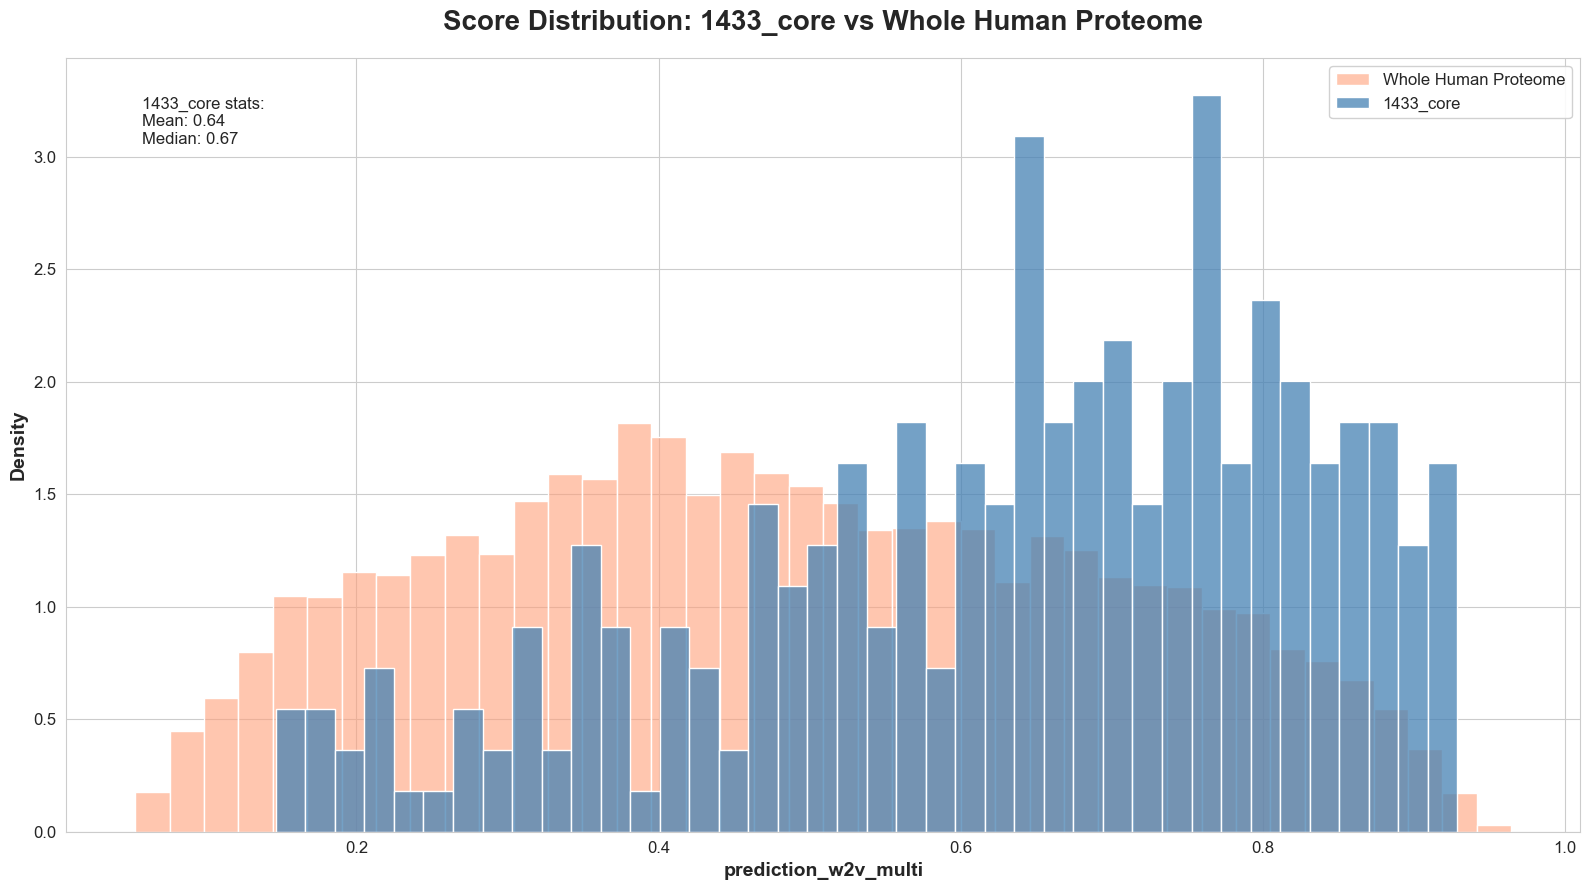

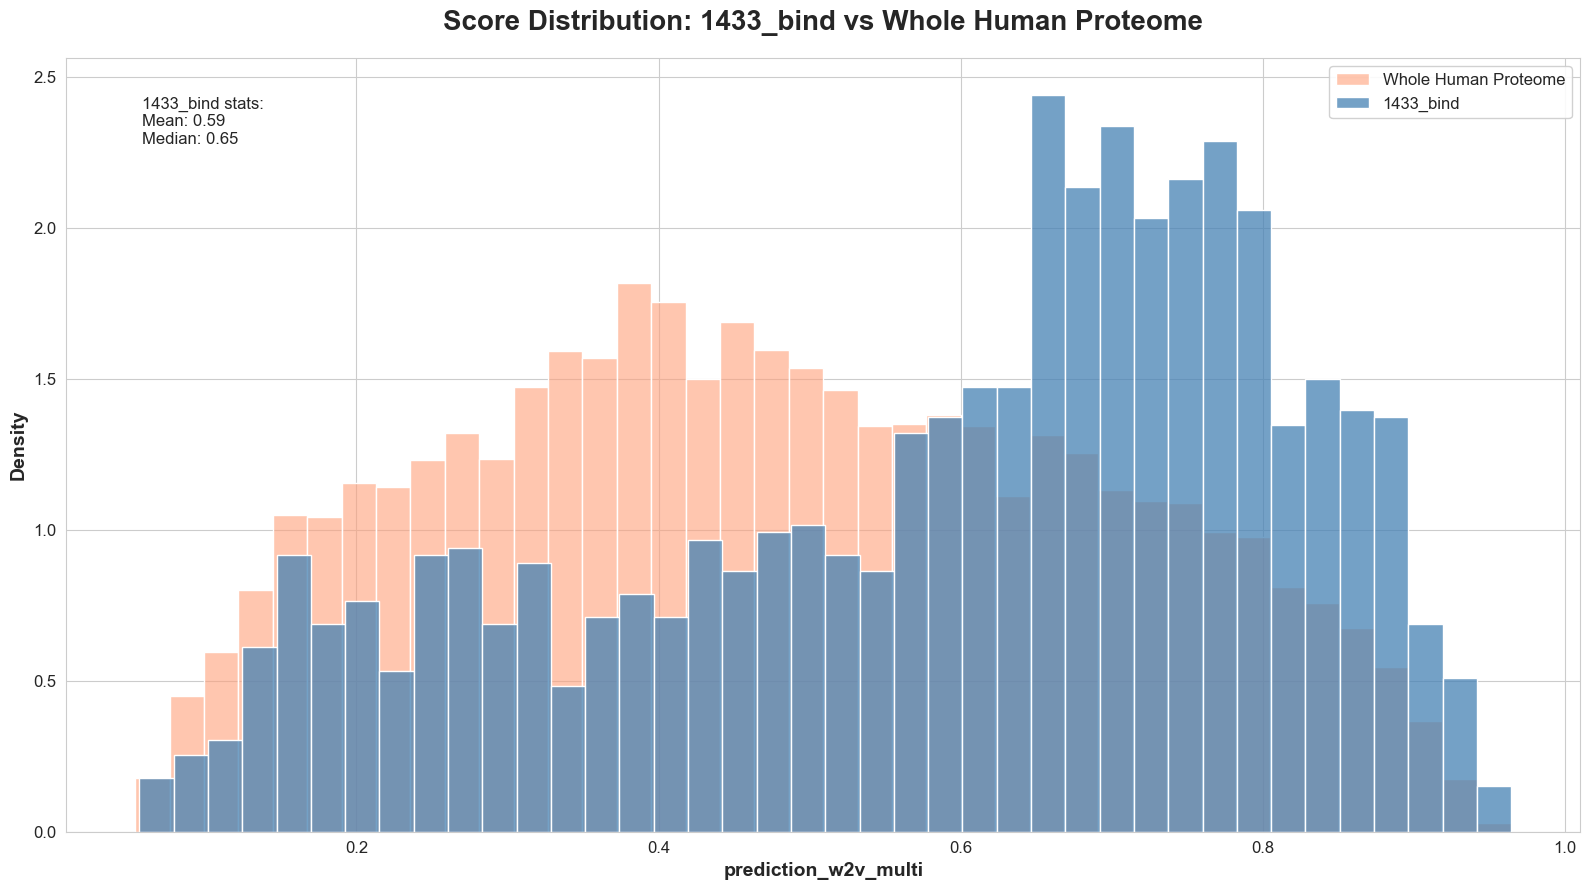

In [41]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"prediction_w2v_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"prediction_w2v_multi", 'Uniprot_ID')

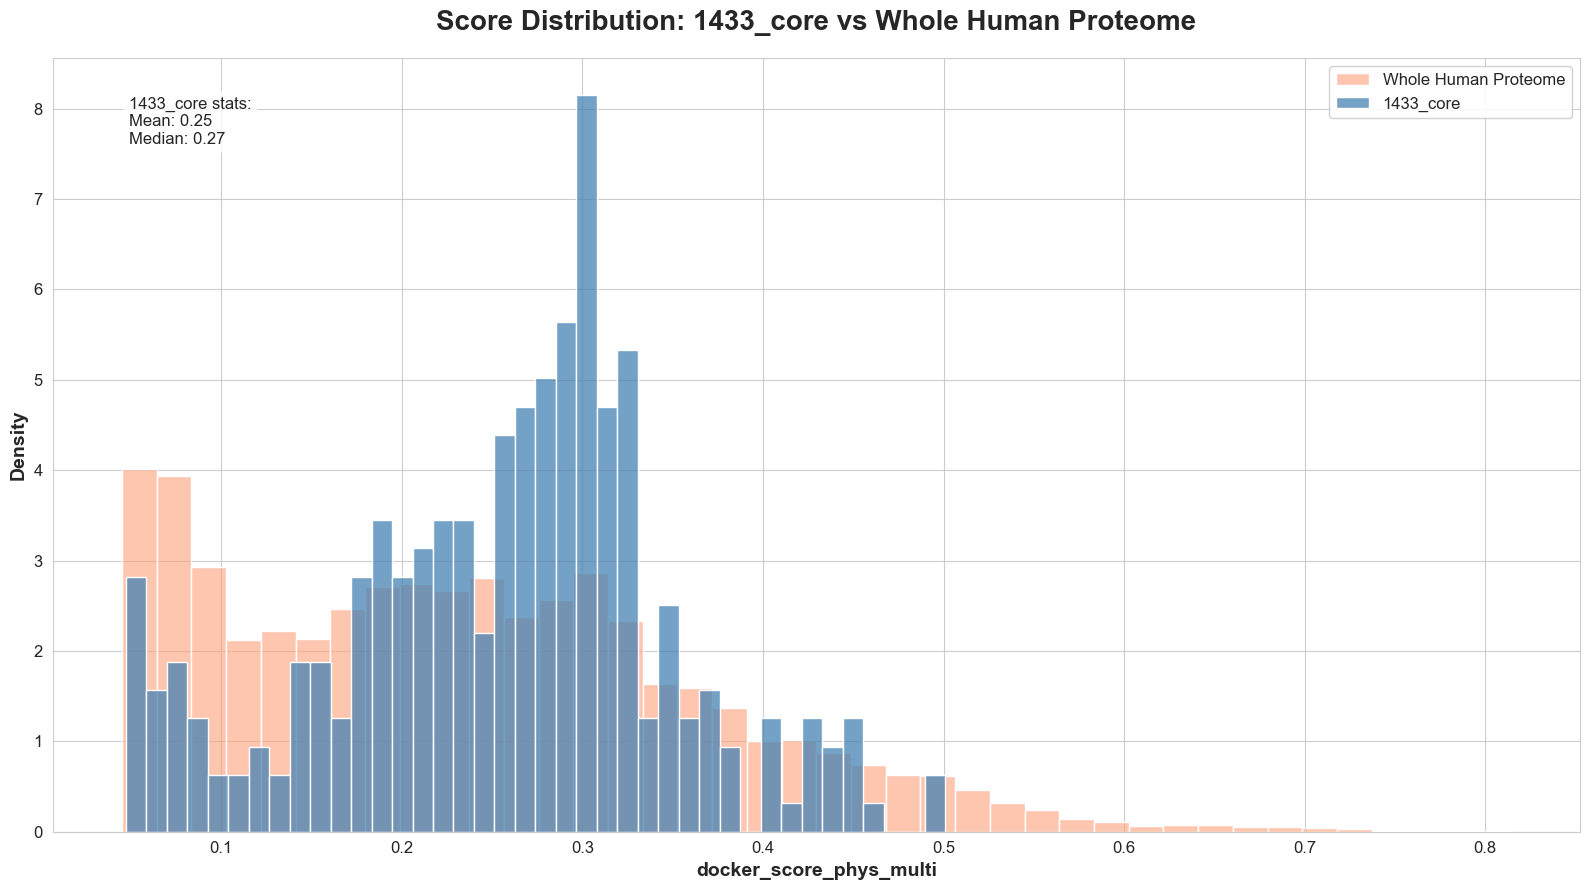

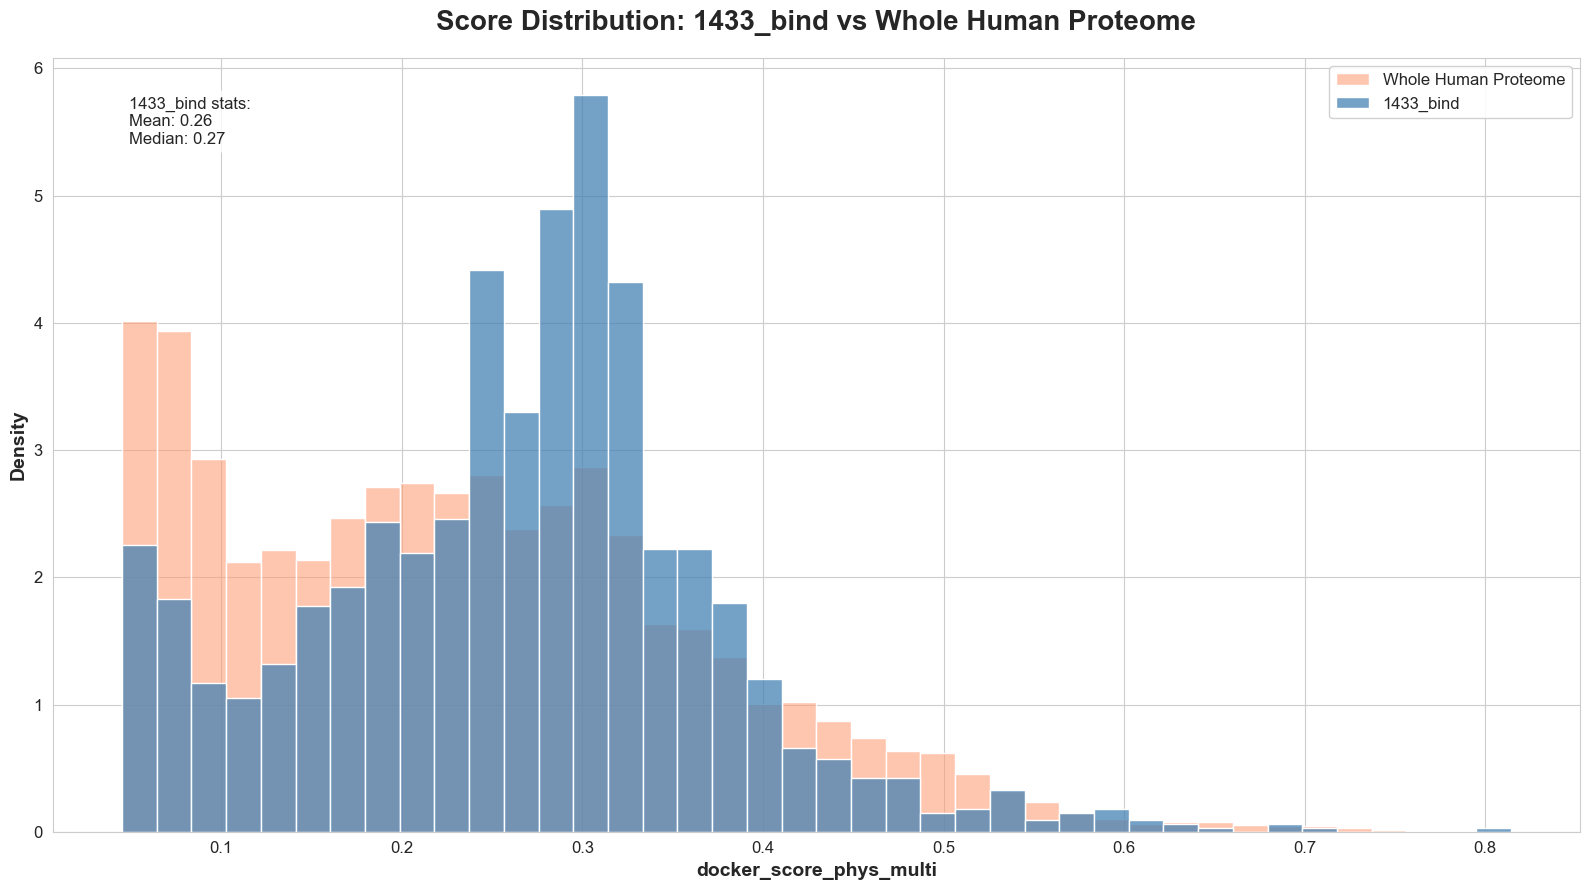

In [42]:
# two score using here: prediction_phys_multi socre and prediction_w2v_multi score
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"docker_score_phys_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"docker_score_phys_multi", 'Uniprot_ID')

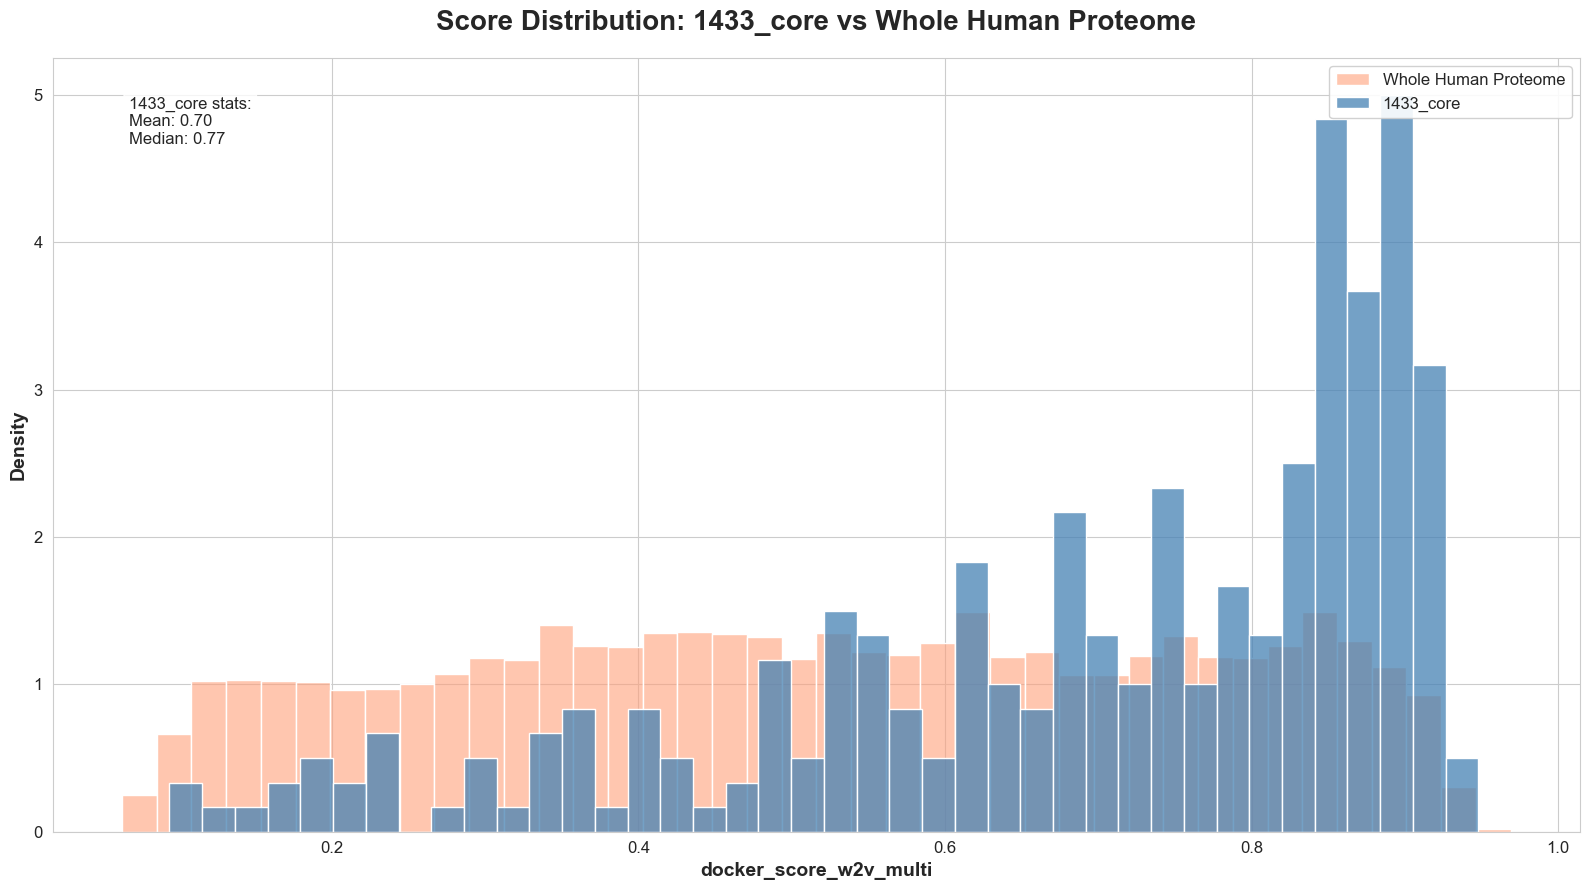

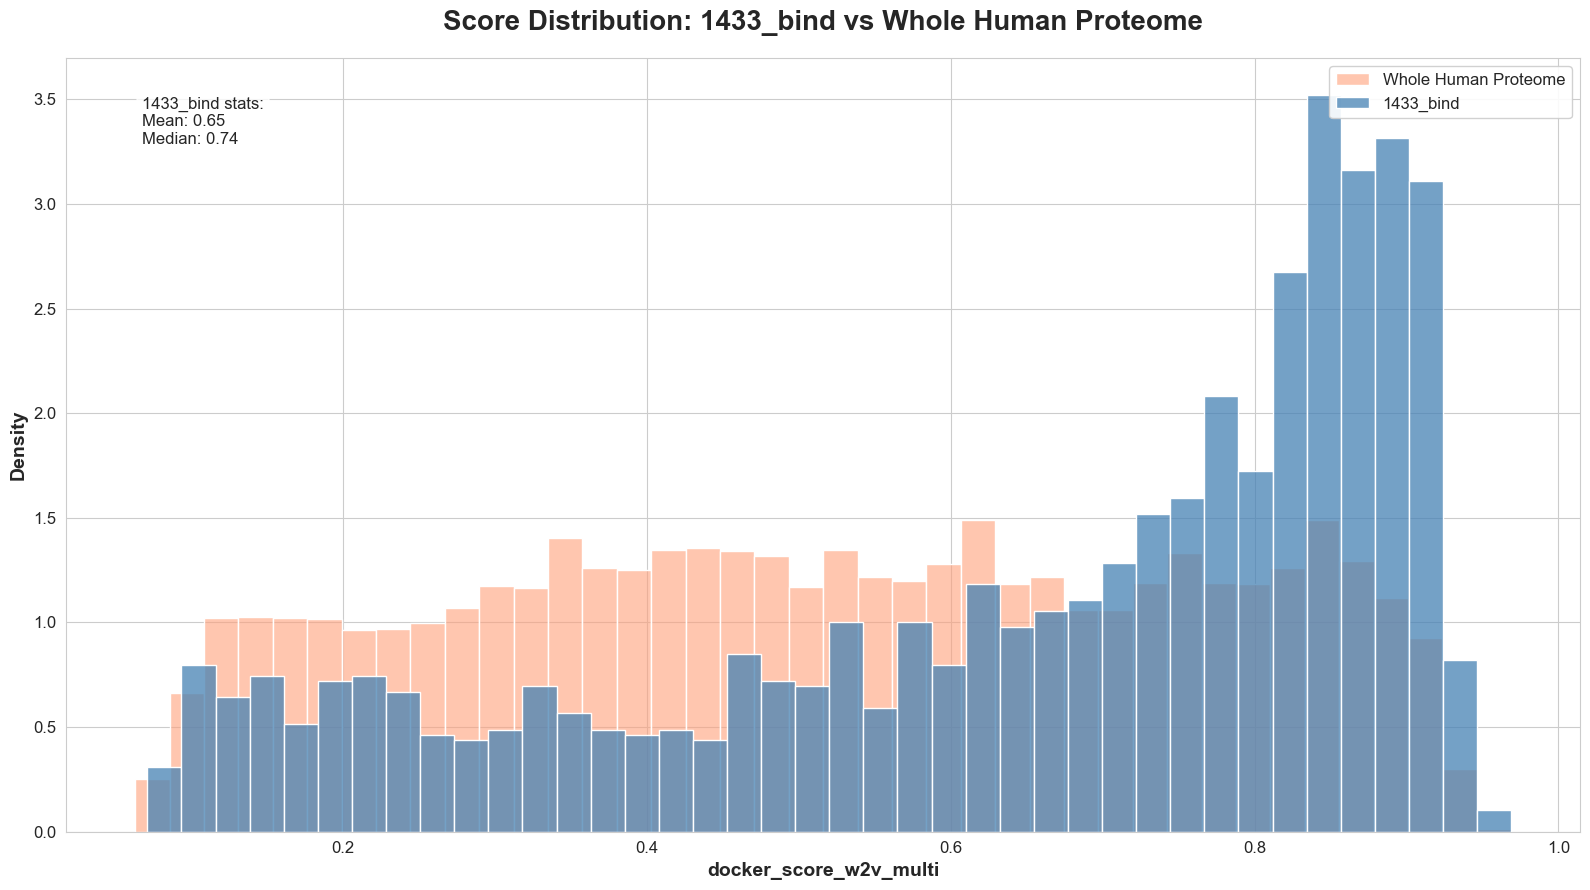

In [43]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"docker_score_w2v_multi", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"docker_score_w2v_multi", 'Uniprot_ID')

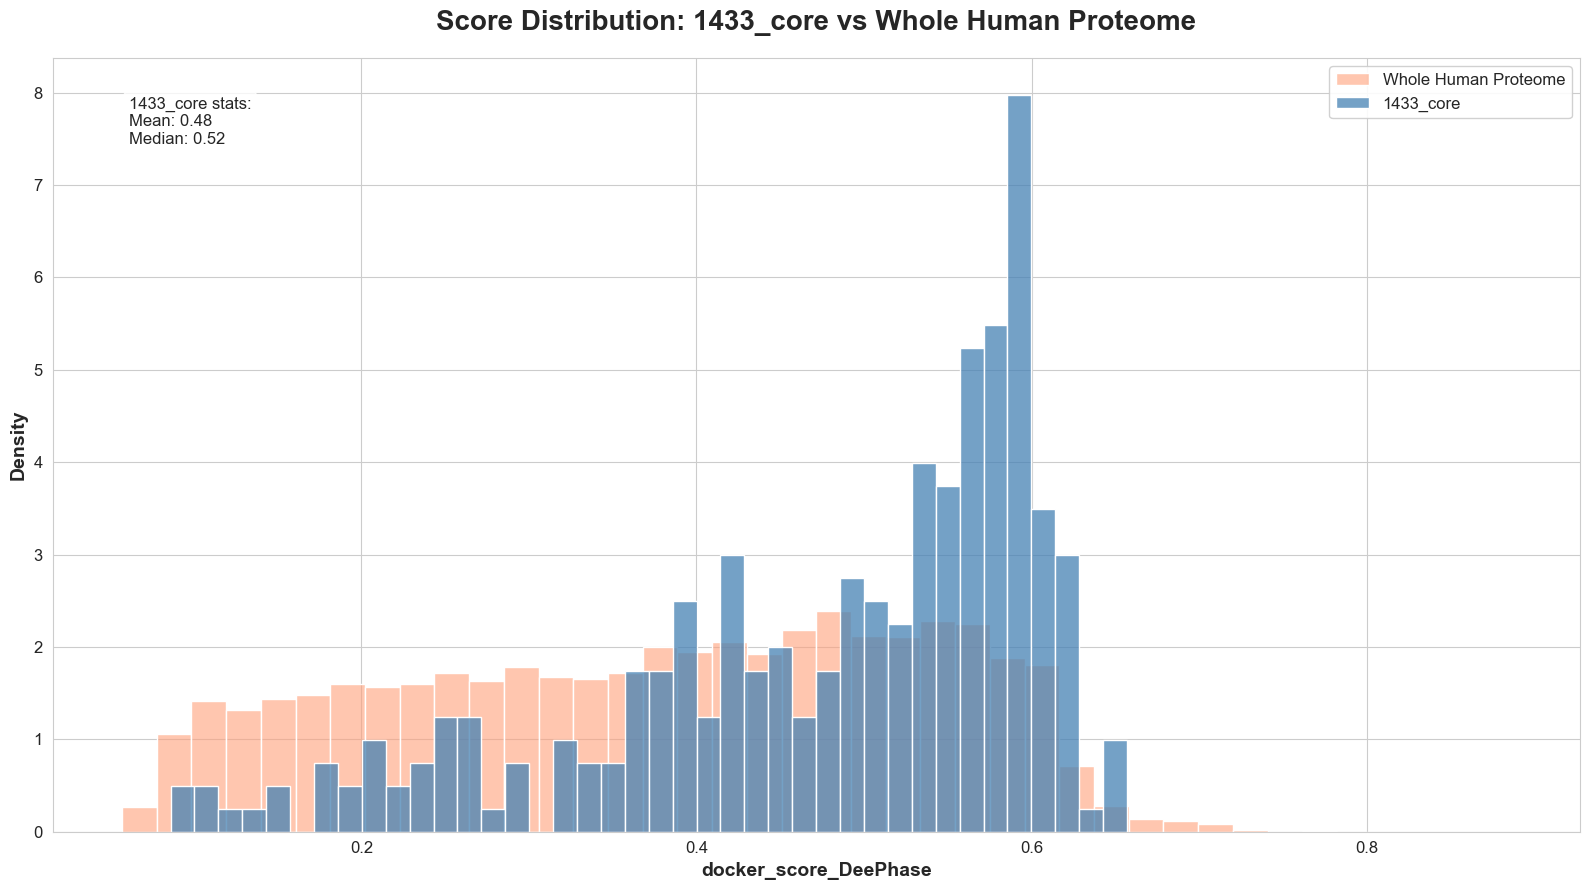

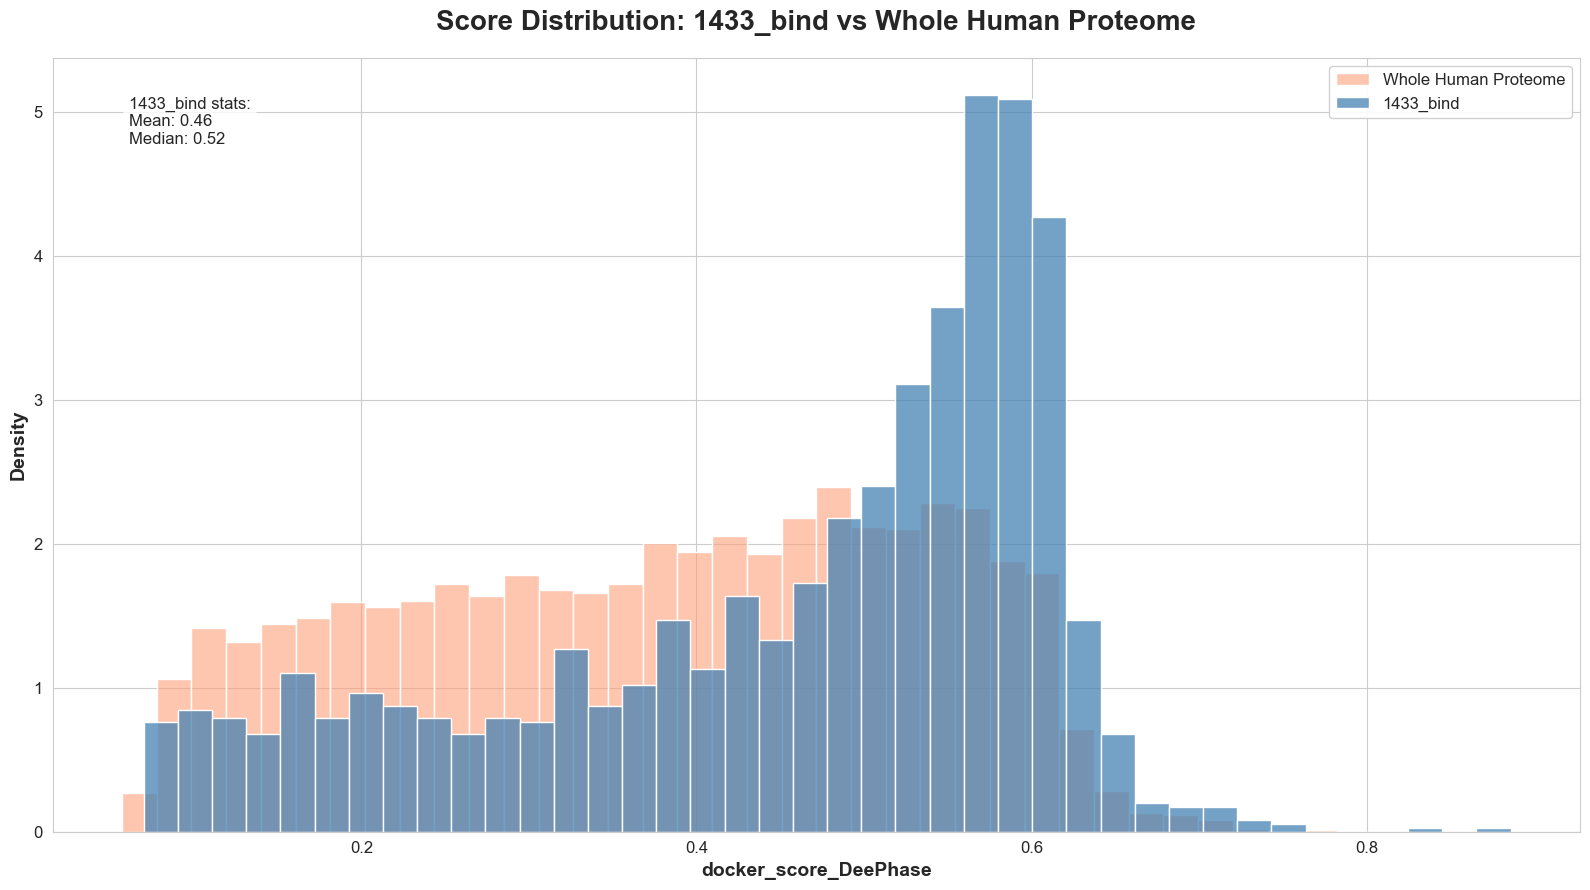

In [44]:
distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_DeePhase,"docker_score_DeePhase", 'Uniprot_ID')
distribution_go(Protein_1433_interactome,"1433_bind", df_DeePhase,"docker_score_DeePhase", 'Uniprot_ID')

In [45]:
# PhaSePred score
# a list score using here
phasepred_score_columns = ['PhaSePred_SaPS-8fea', 'PhaSePred_PdPS-8fea','PhaSePred_SaPS-10fea', 'PhaSePred_PdPS-10fea',
       'PhaSePred_SaPS-8fea_rnk', 'PhaSePred_PdPS-8fea_rnk',
       'PhaSePred_SaPS-10fea_rnk', 'PhaSePred_PdPS-10fea_rnk']

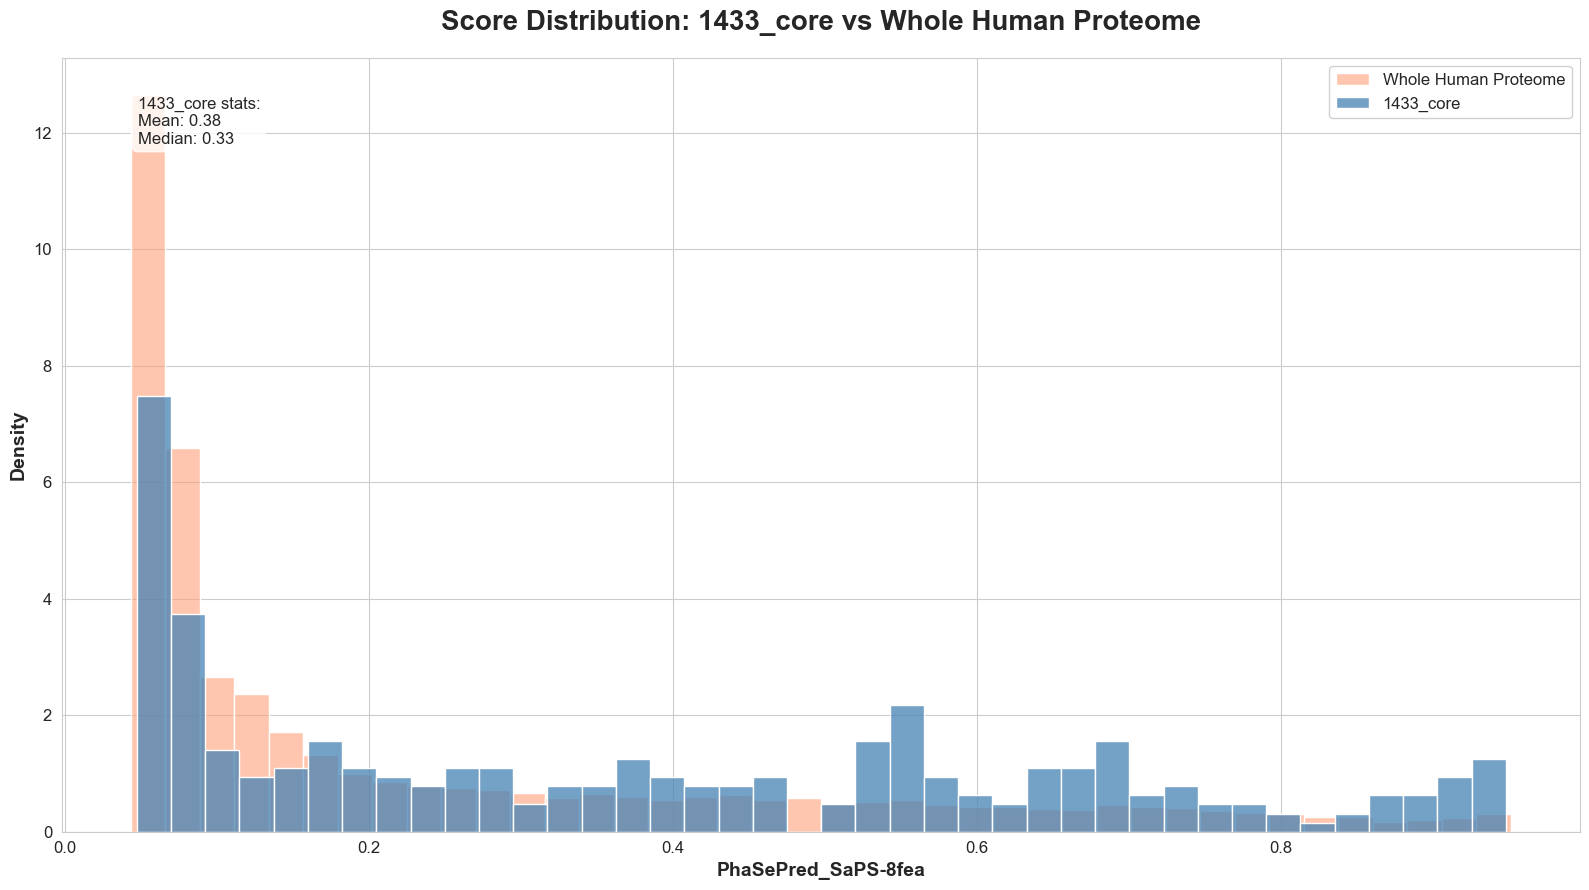

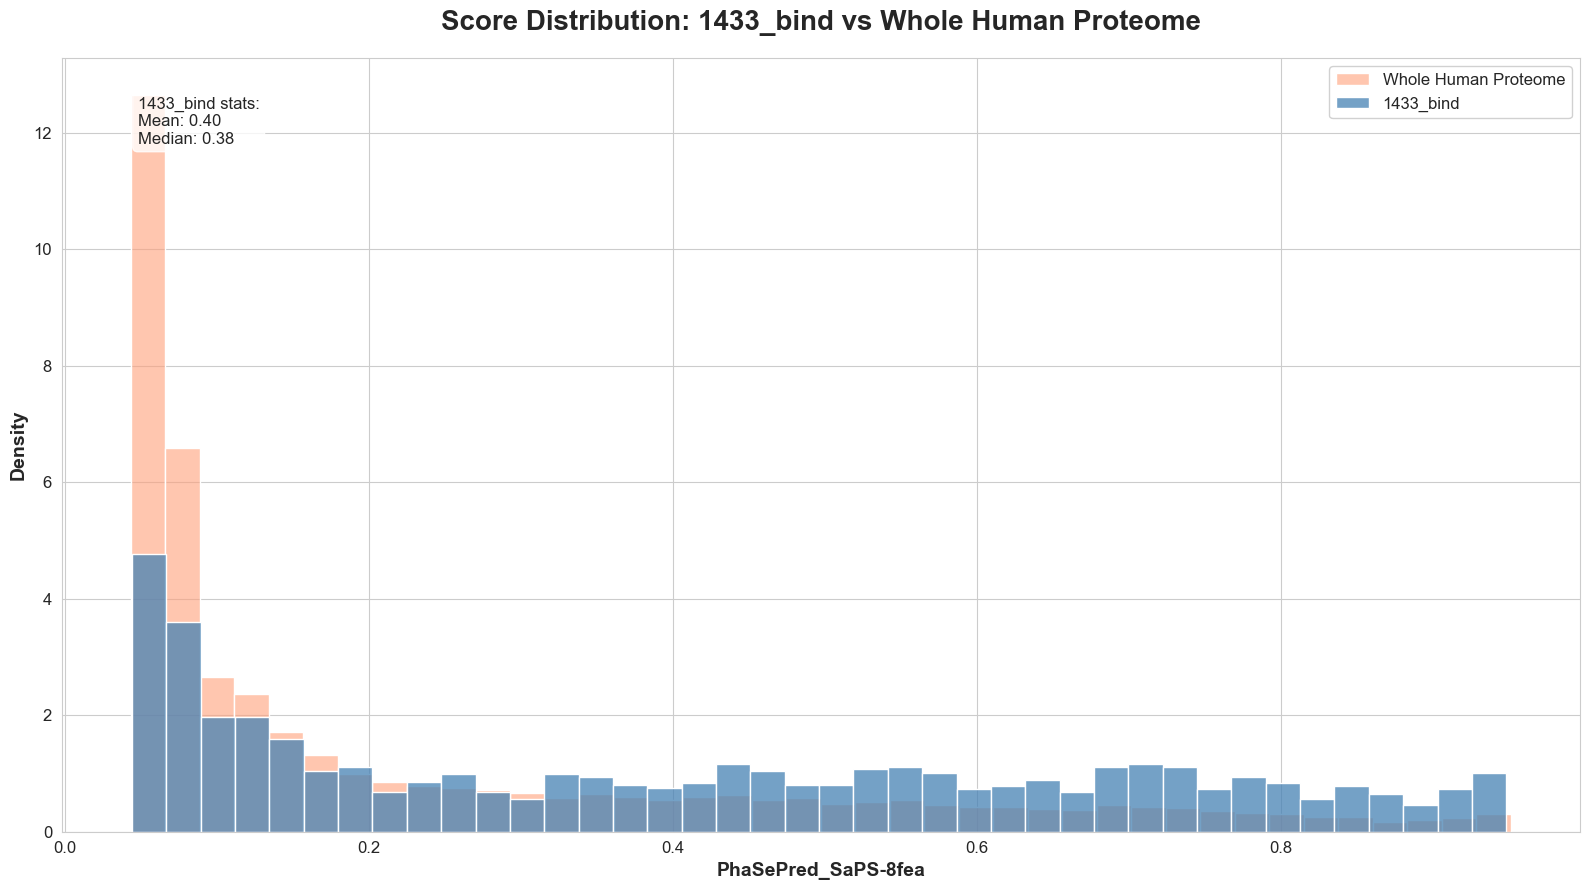

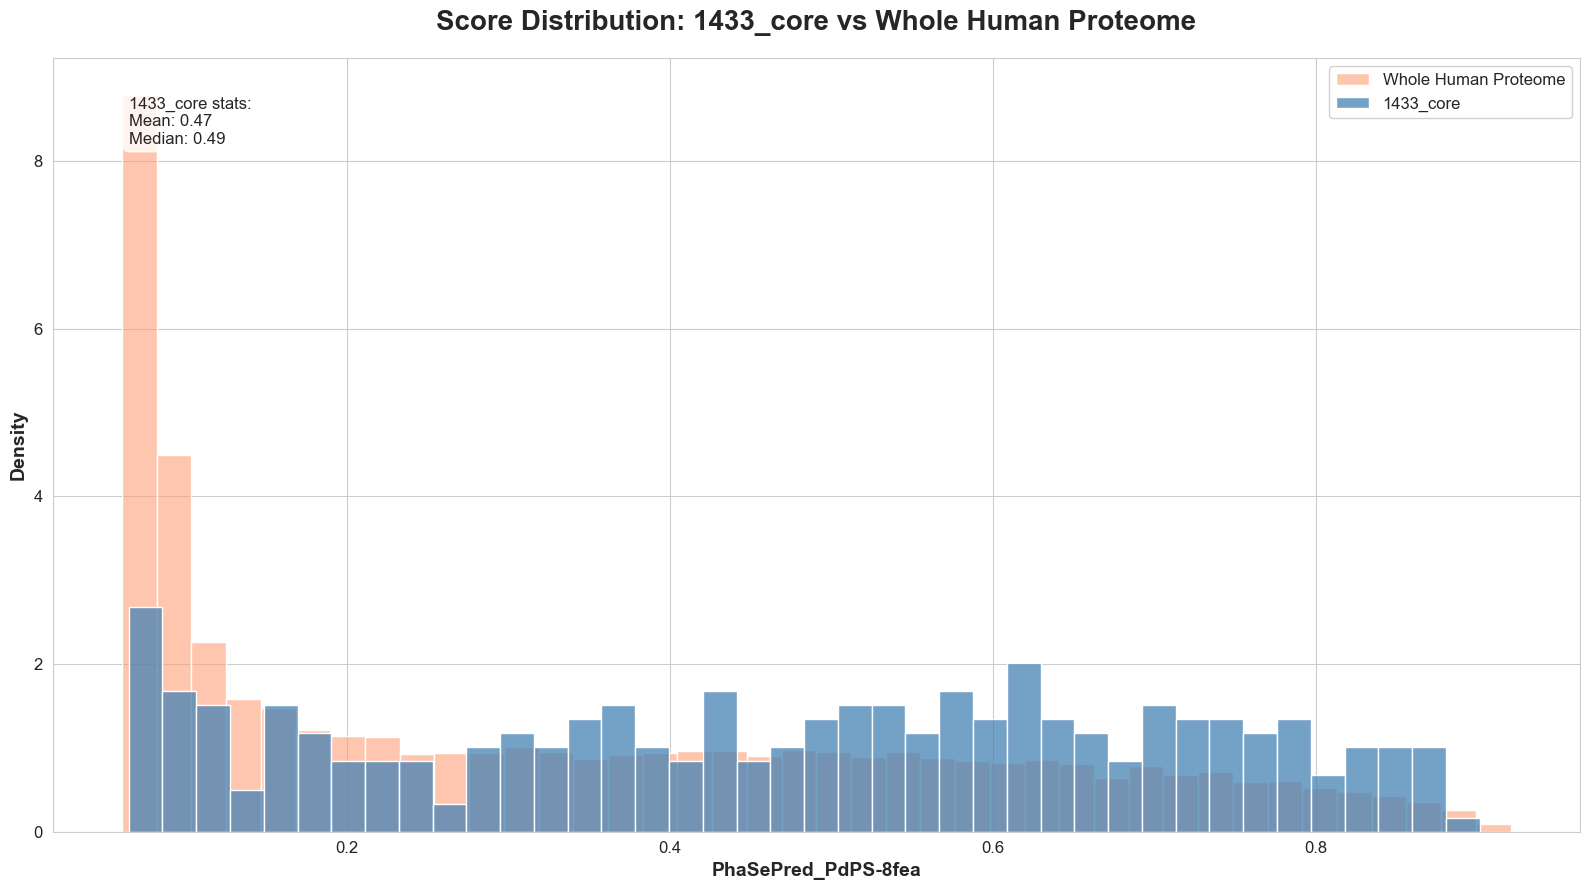

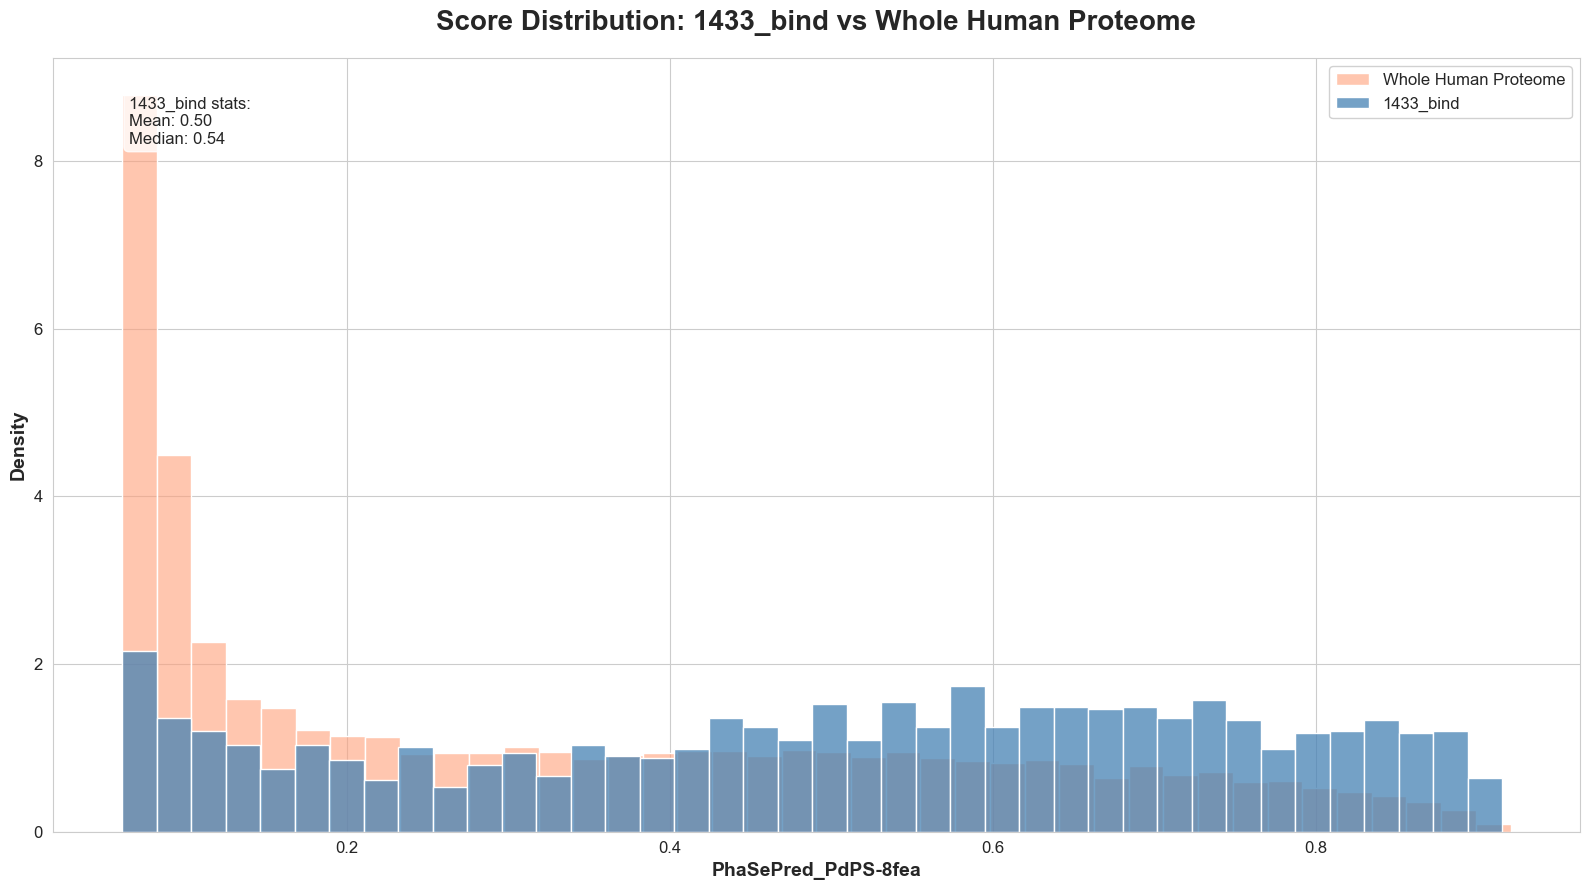

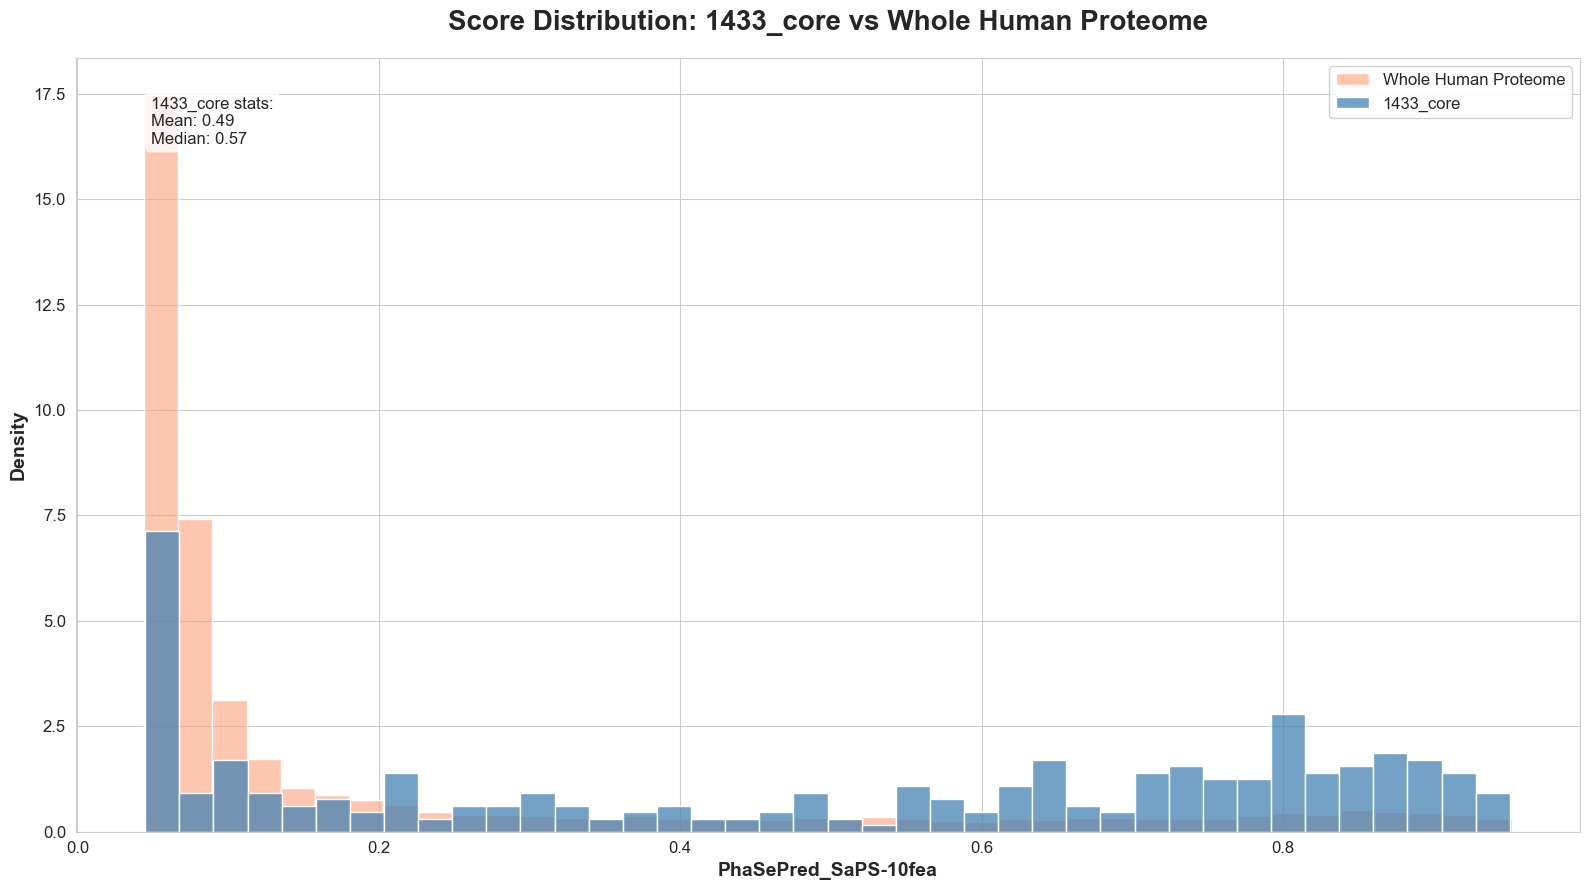

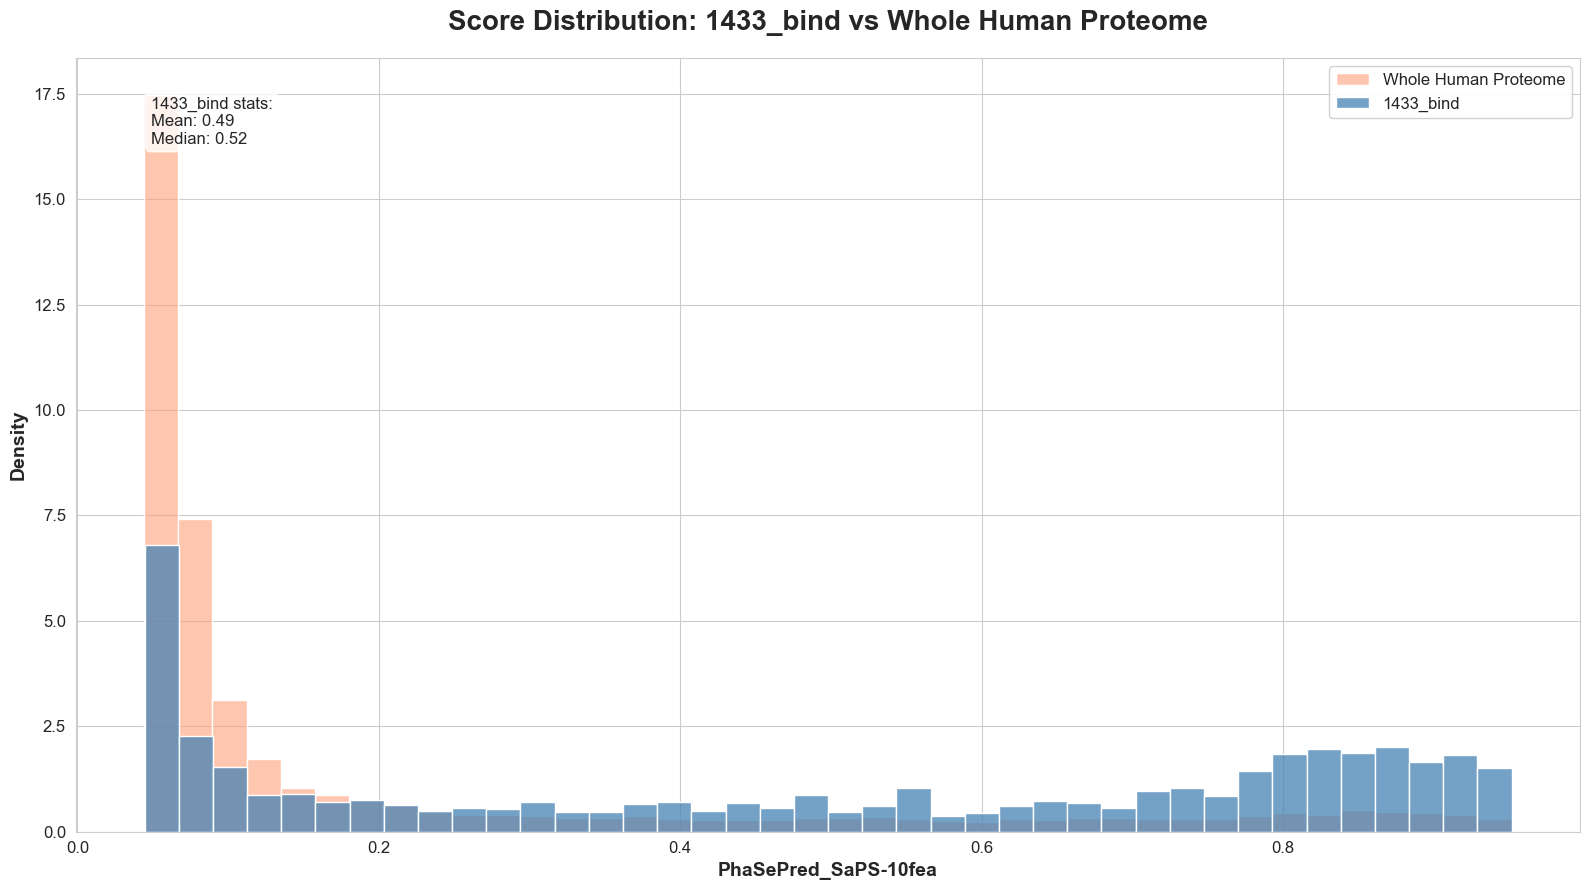

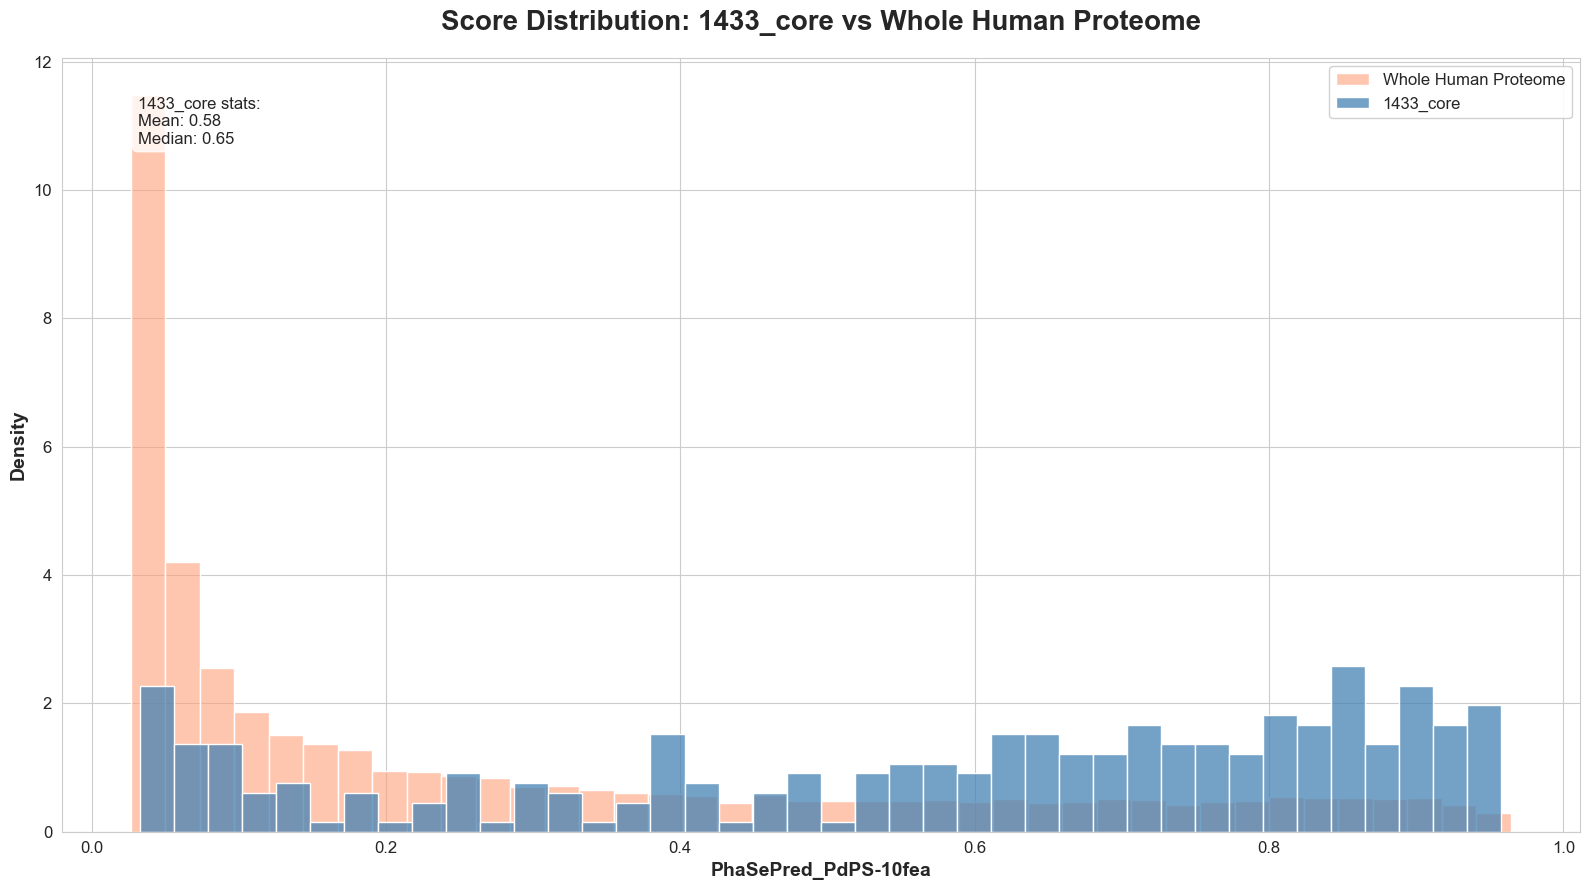

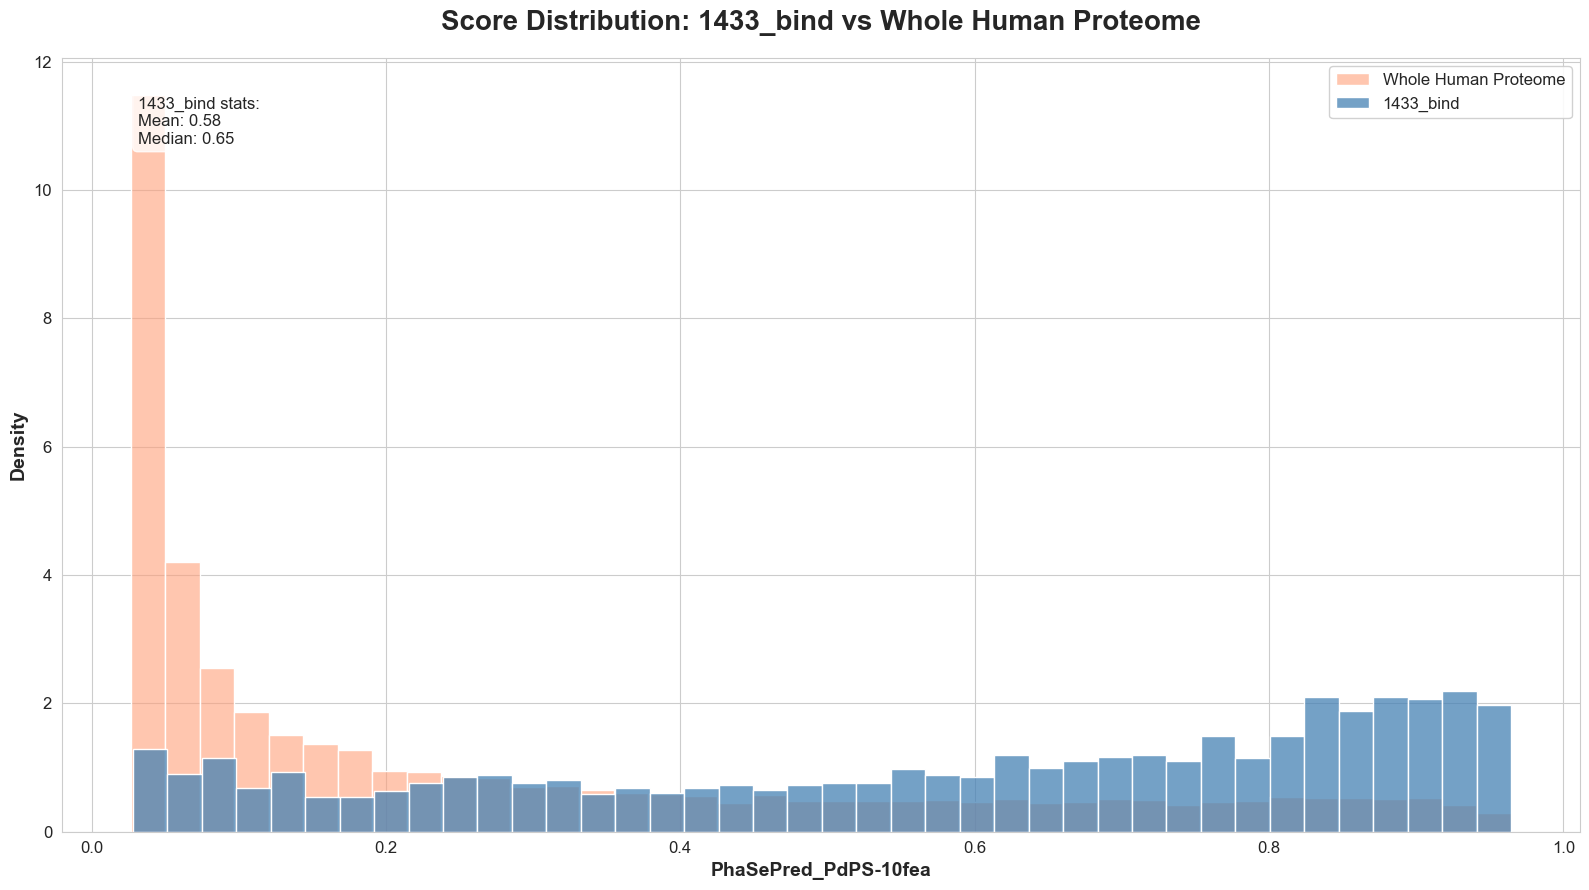

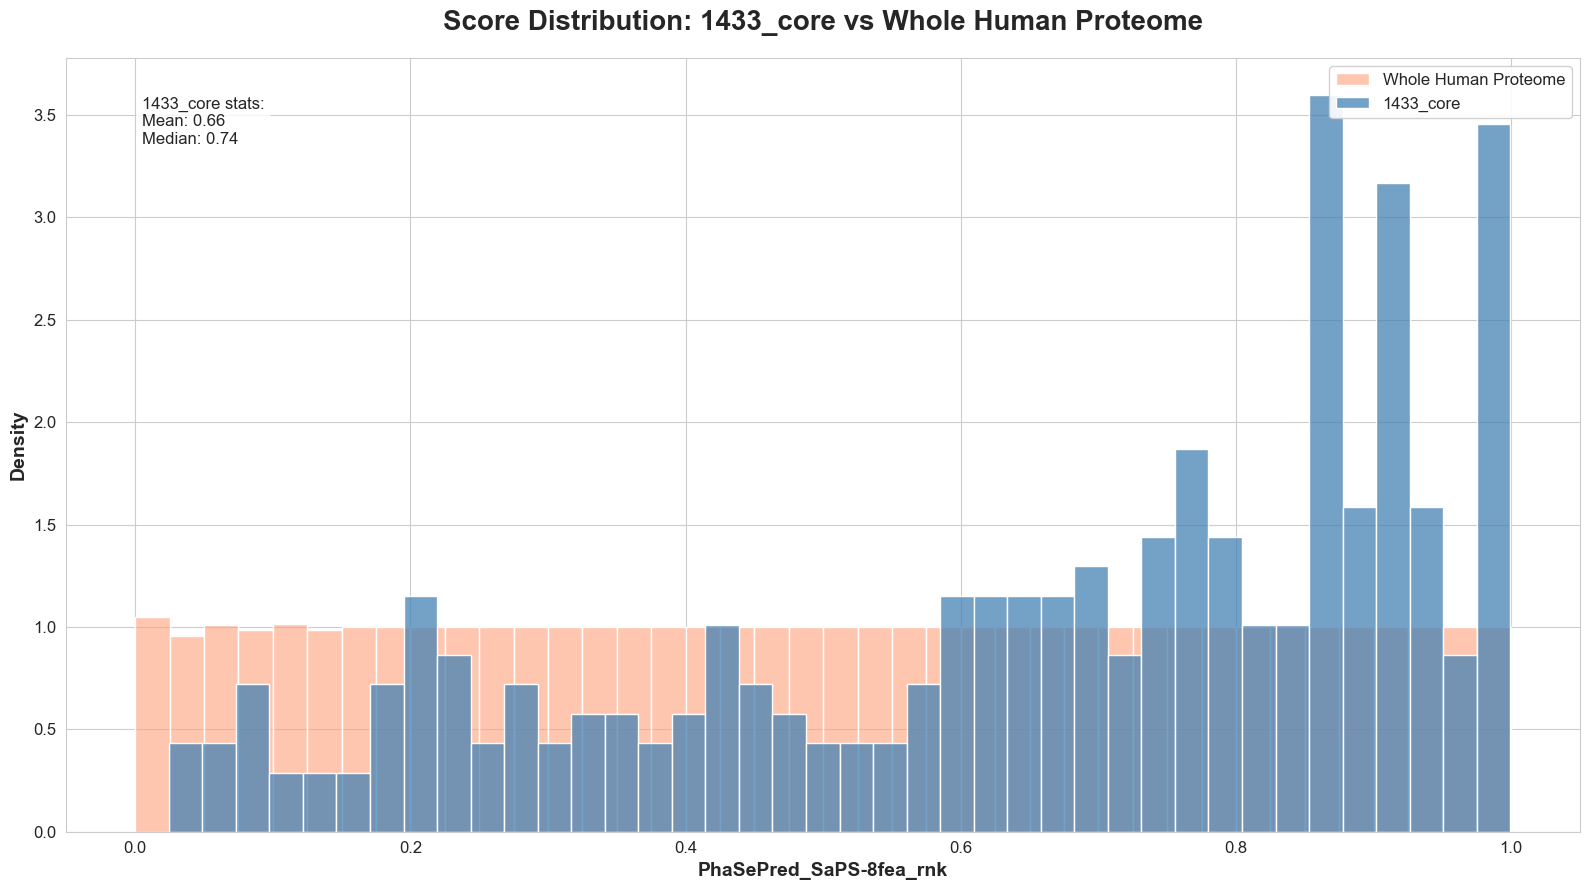

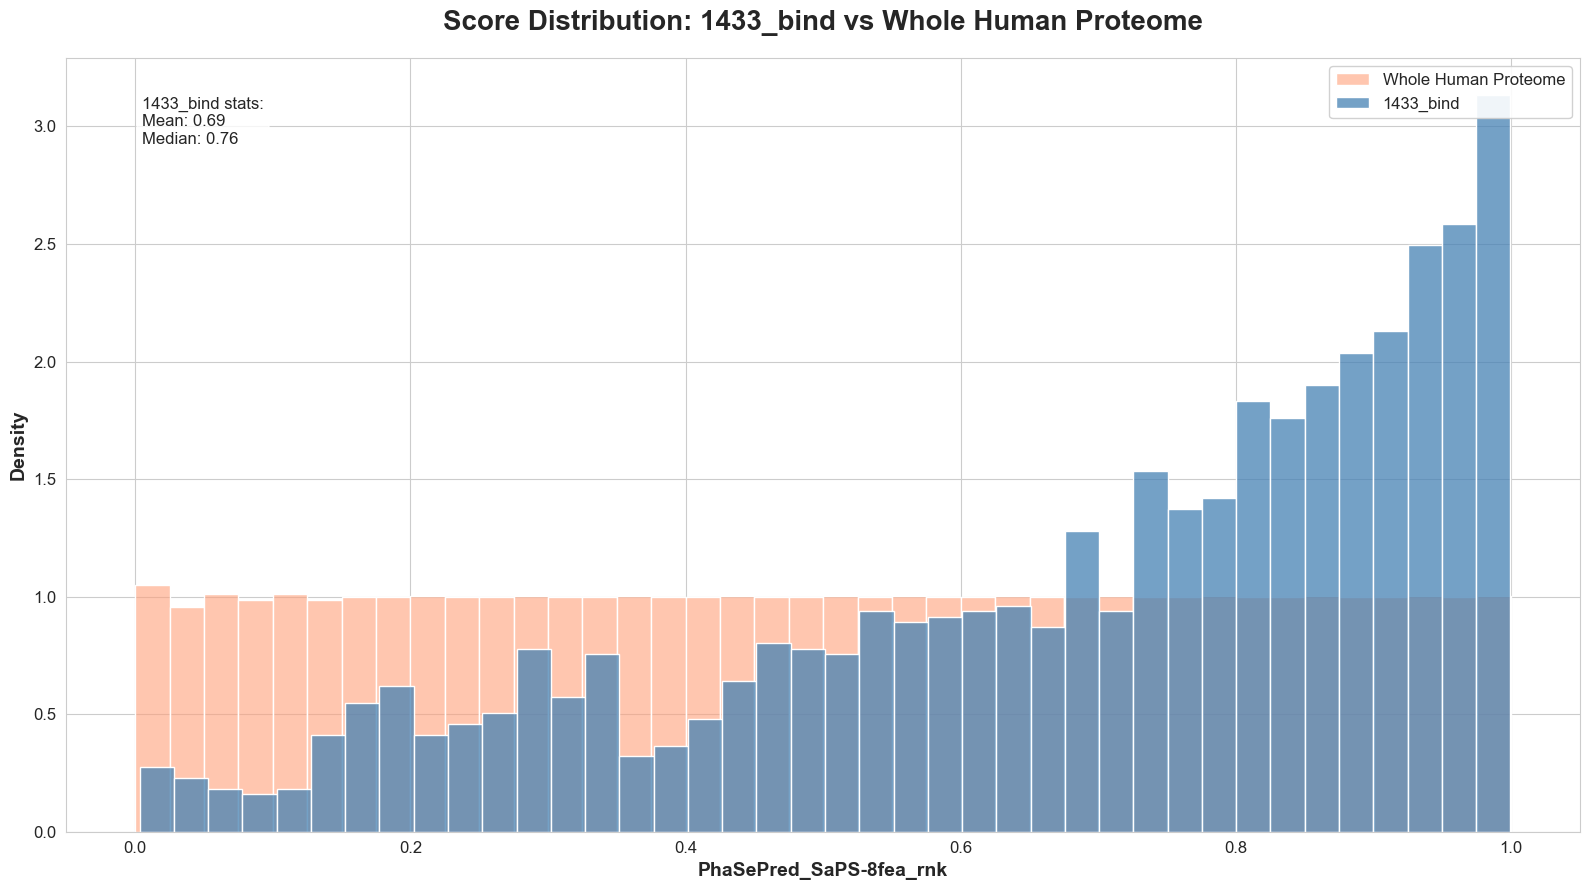

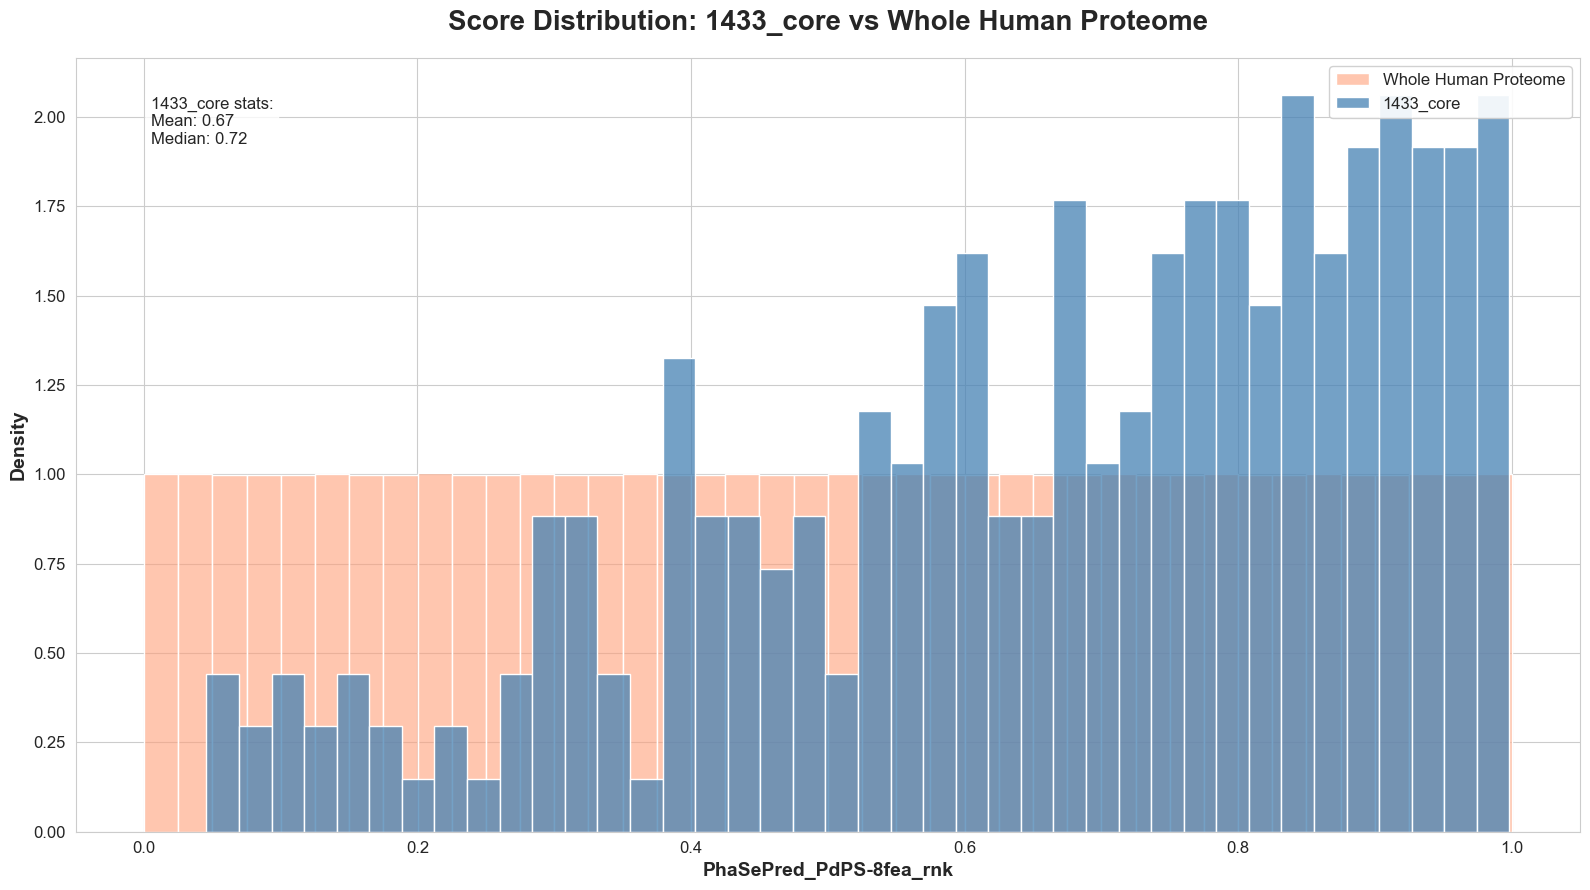

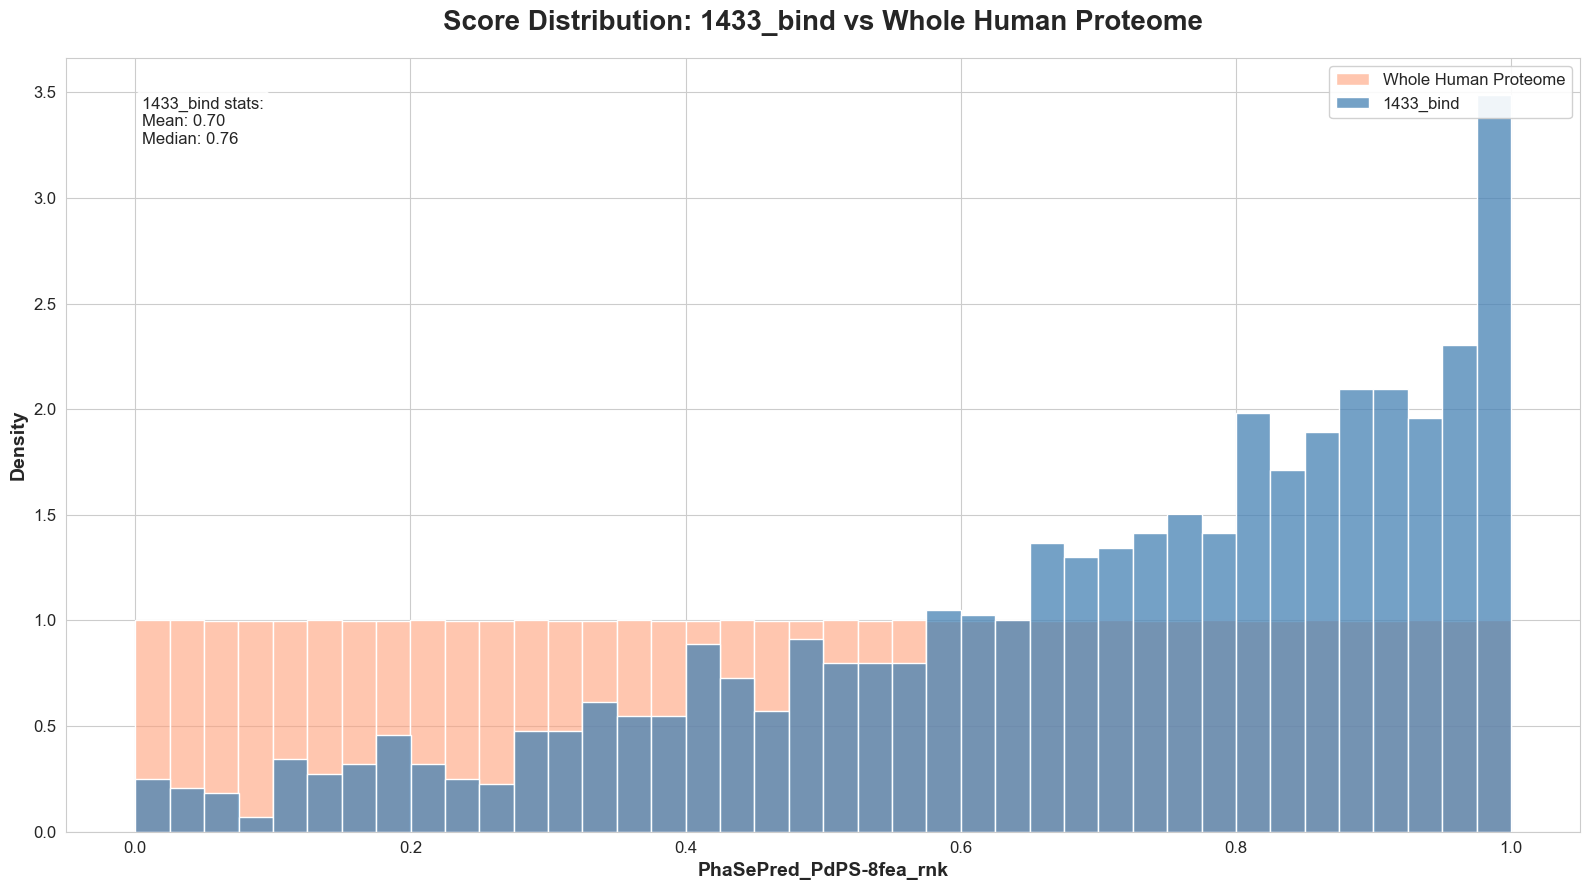

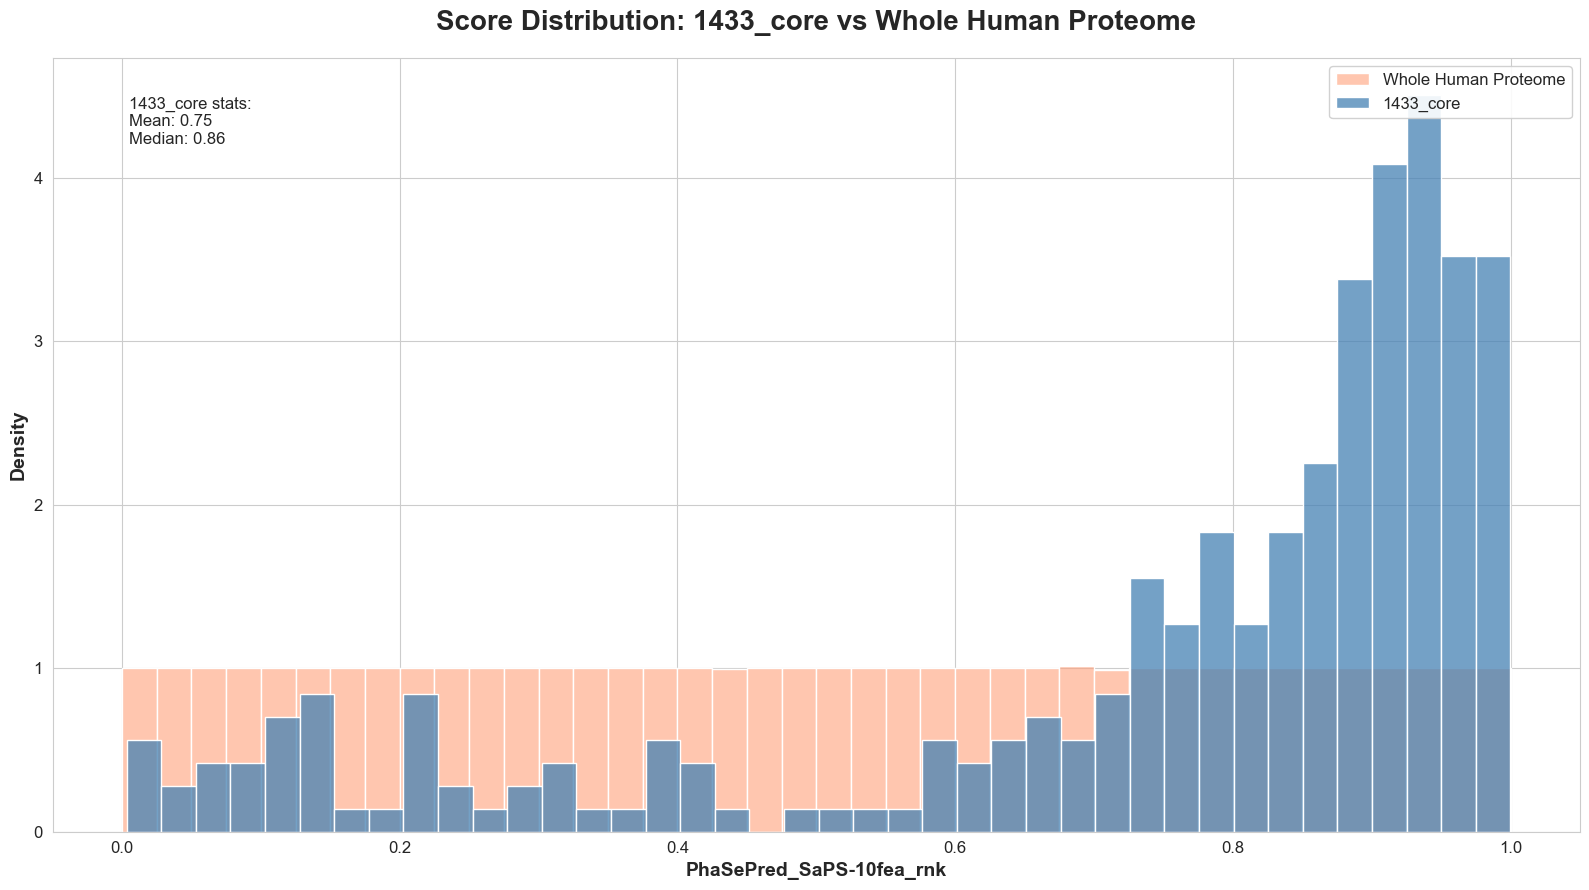

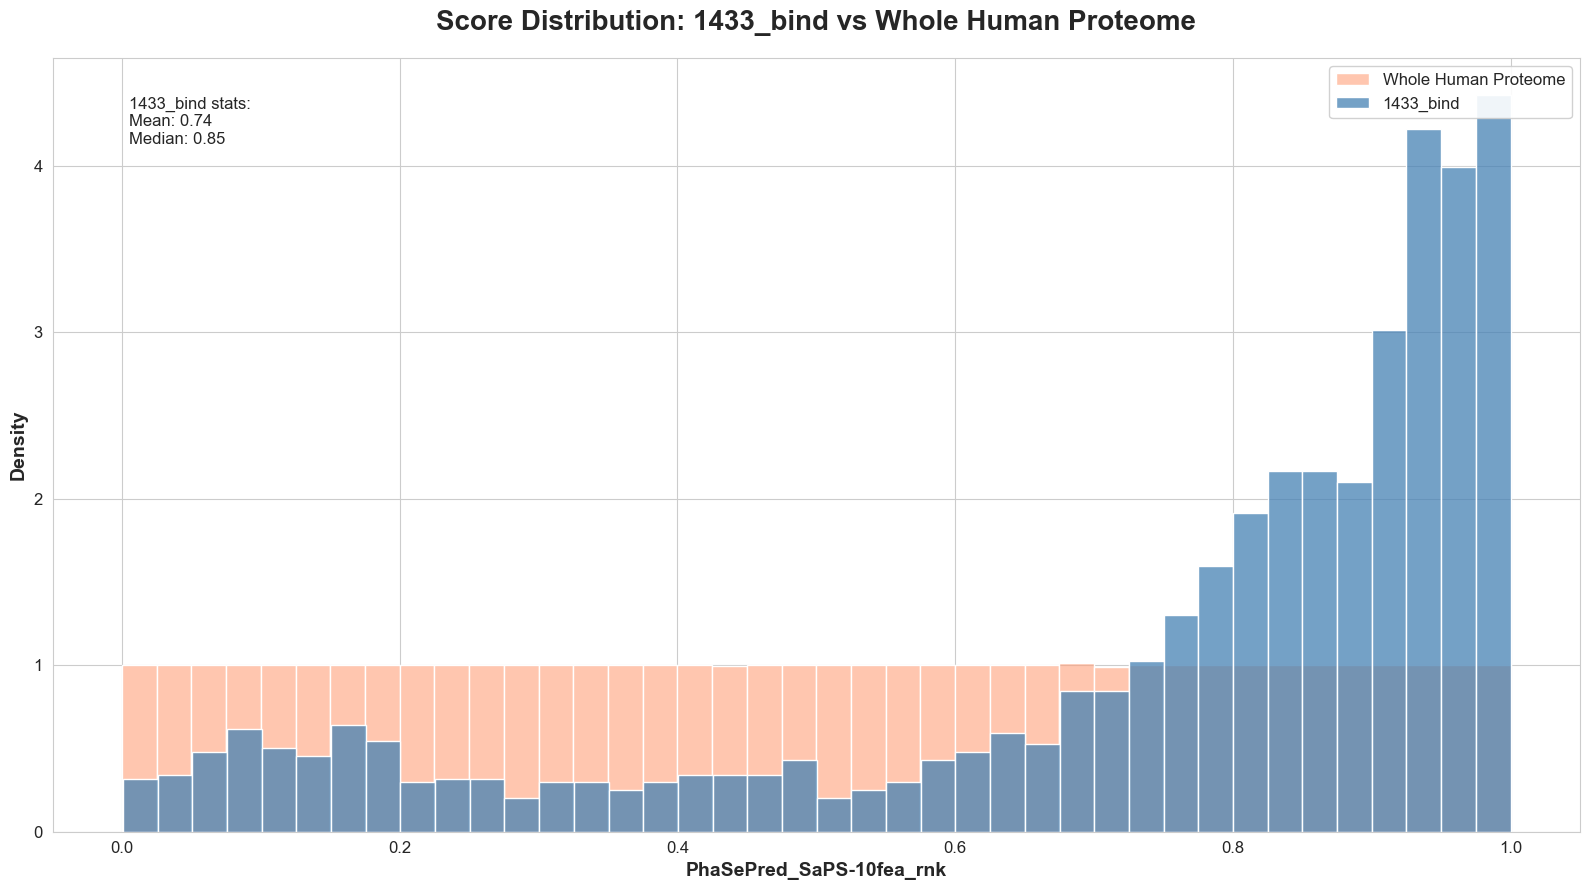

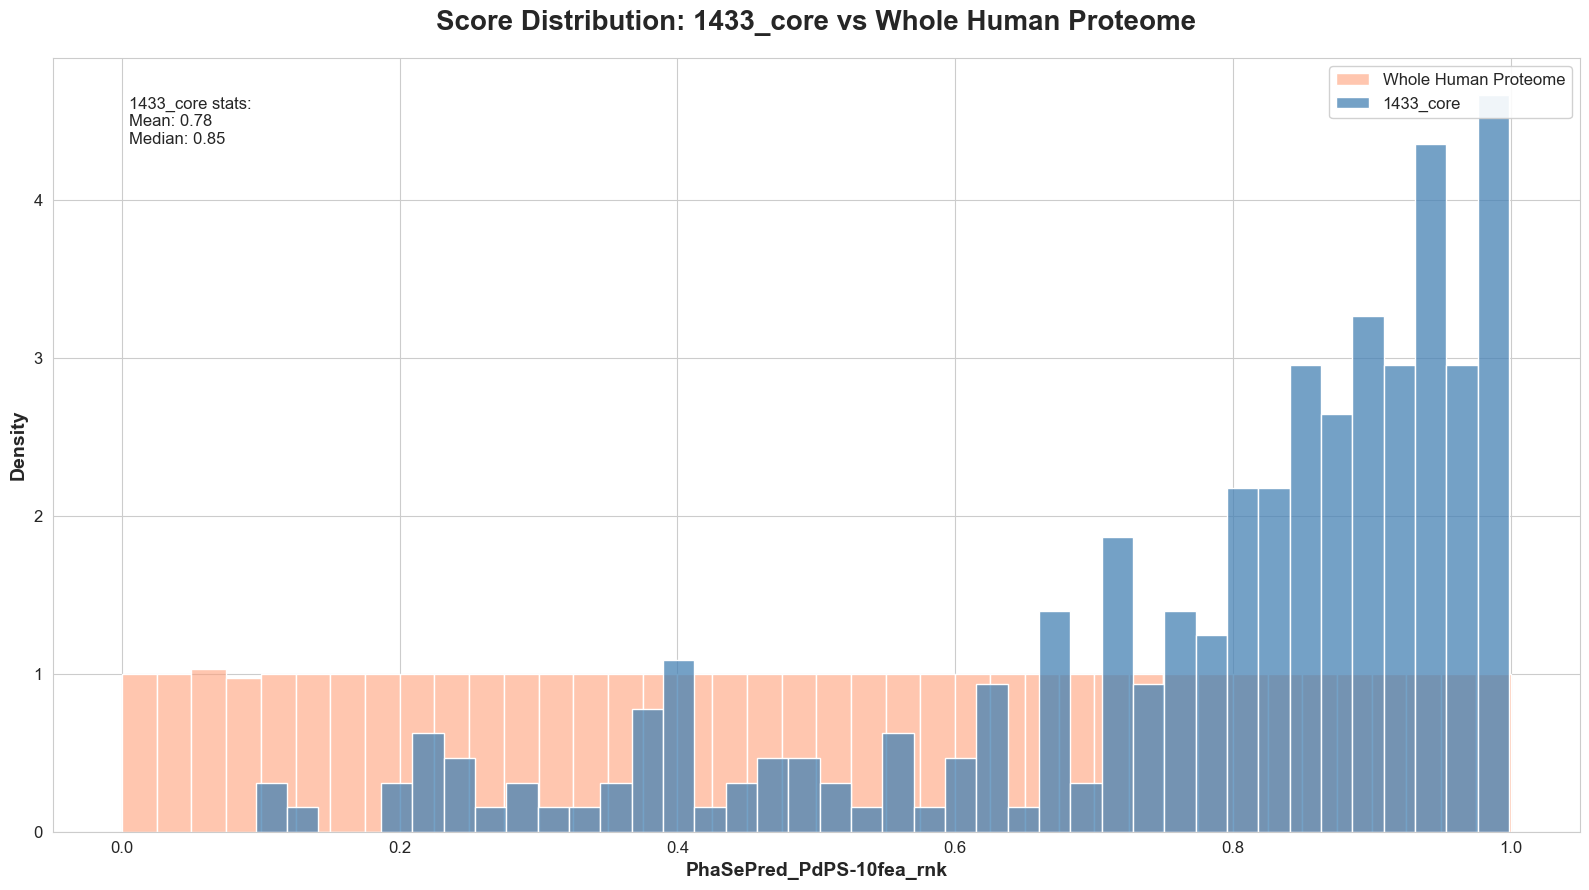

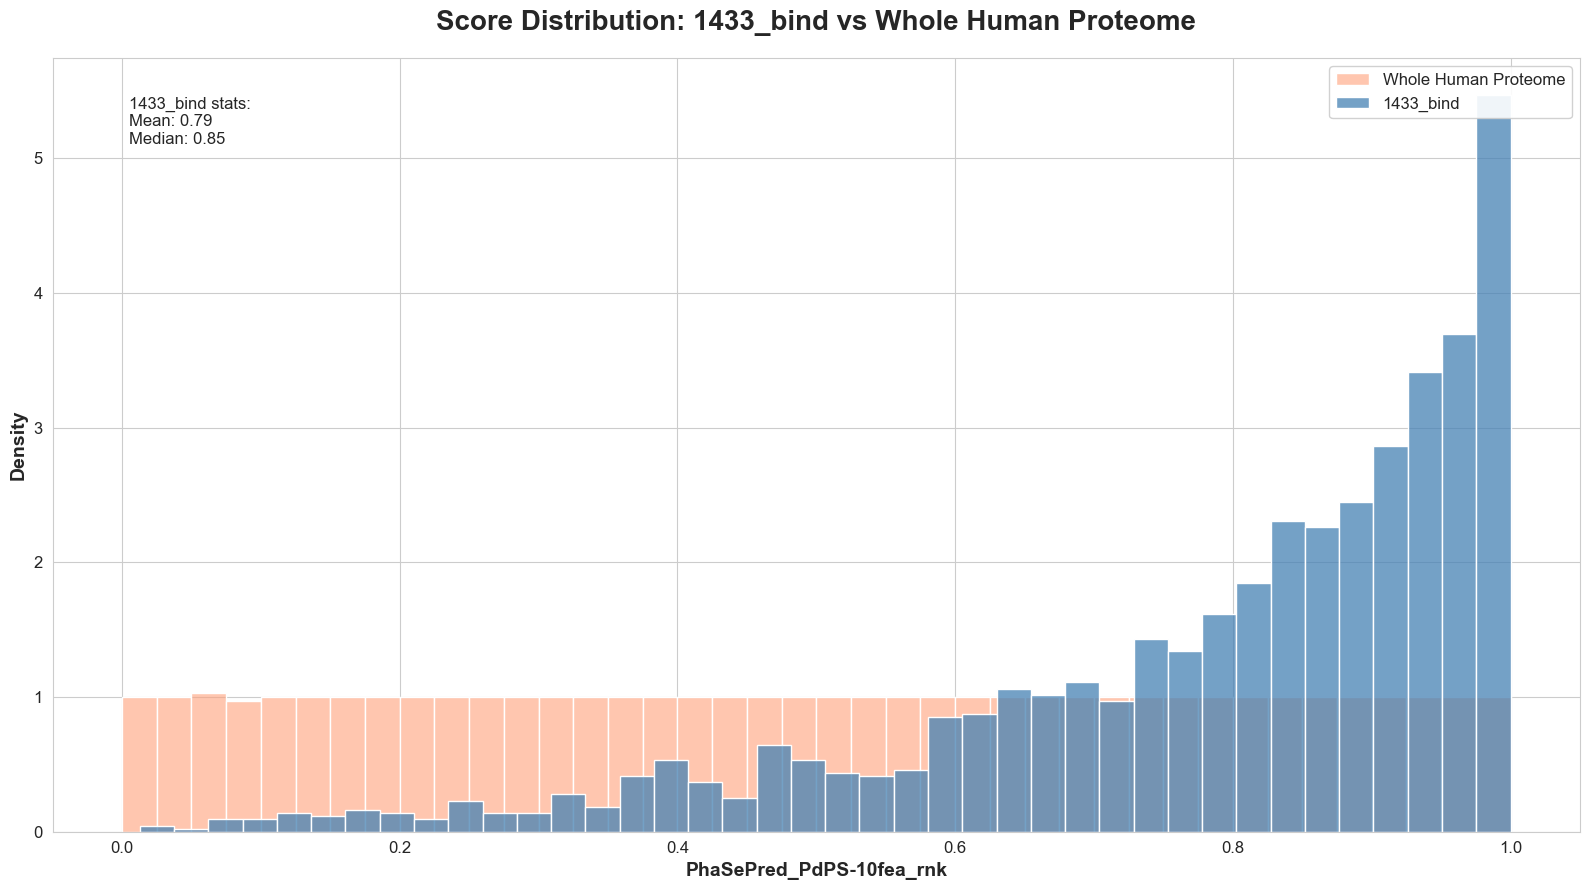

In [46]:
for column in score_columns:
    if column not in ['uniprot_id','Sequence']:
        if column in phasepred_score_columns:
            distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_PhaSePred,column, 'uniprot_id')
            distribution_go(Protein_1433_interactome,"1433_bind", df_PhaSePred,column, 'uniprot_id')

Task 9: We compared phase separation-related physicochemical properties, such as FCR, IDR, LCR, catGRANULE, PLAAC, Pscore, hydropathy, DeepCoil, SEG, charged residues, phosphorylation, and protein length, between the entire human proteome and 14-3-3 binding proteins.

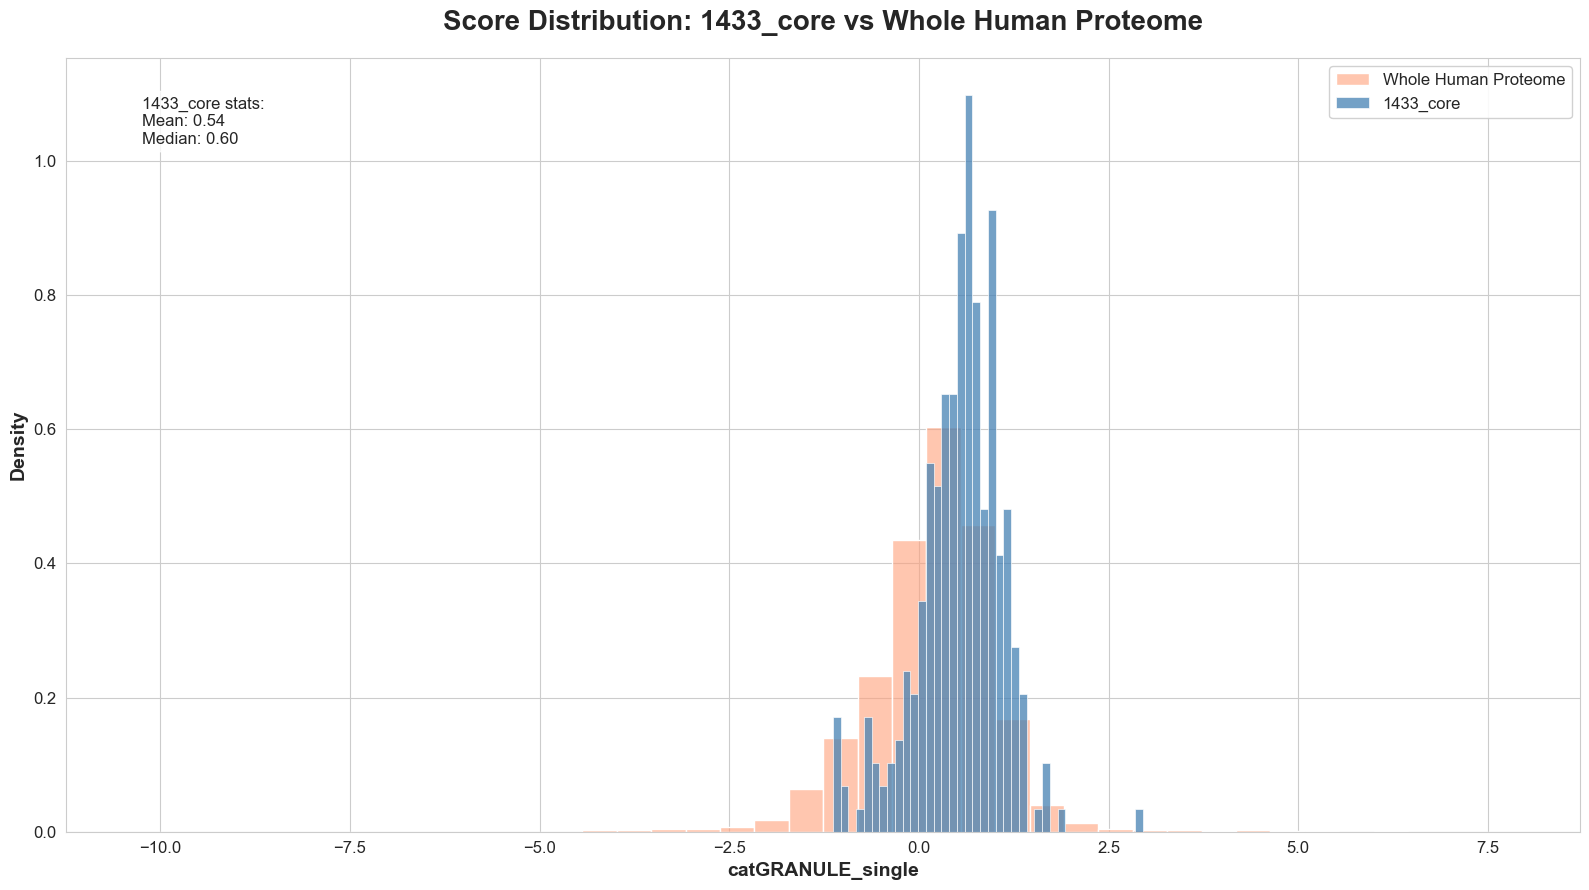

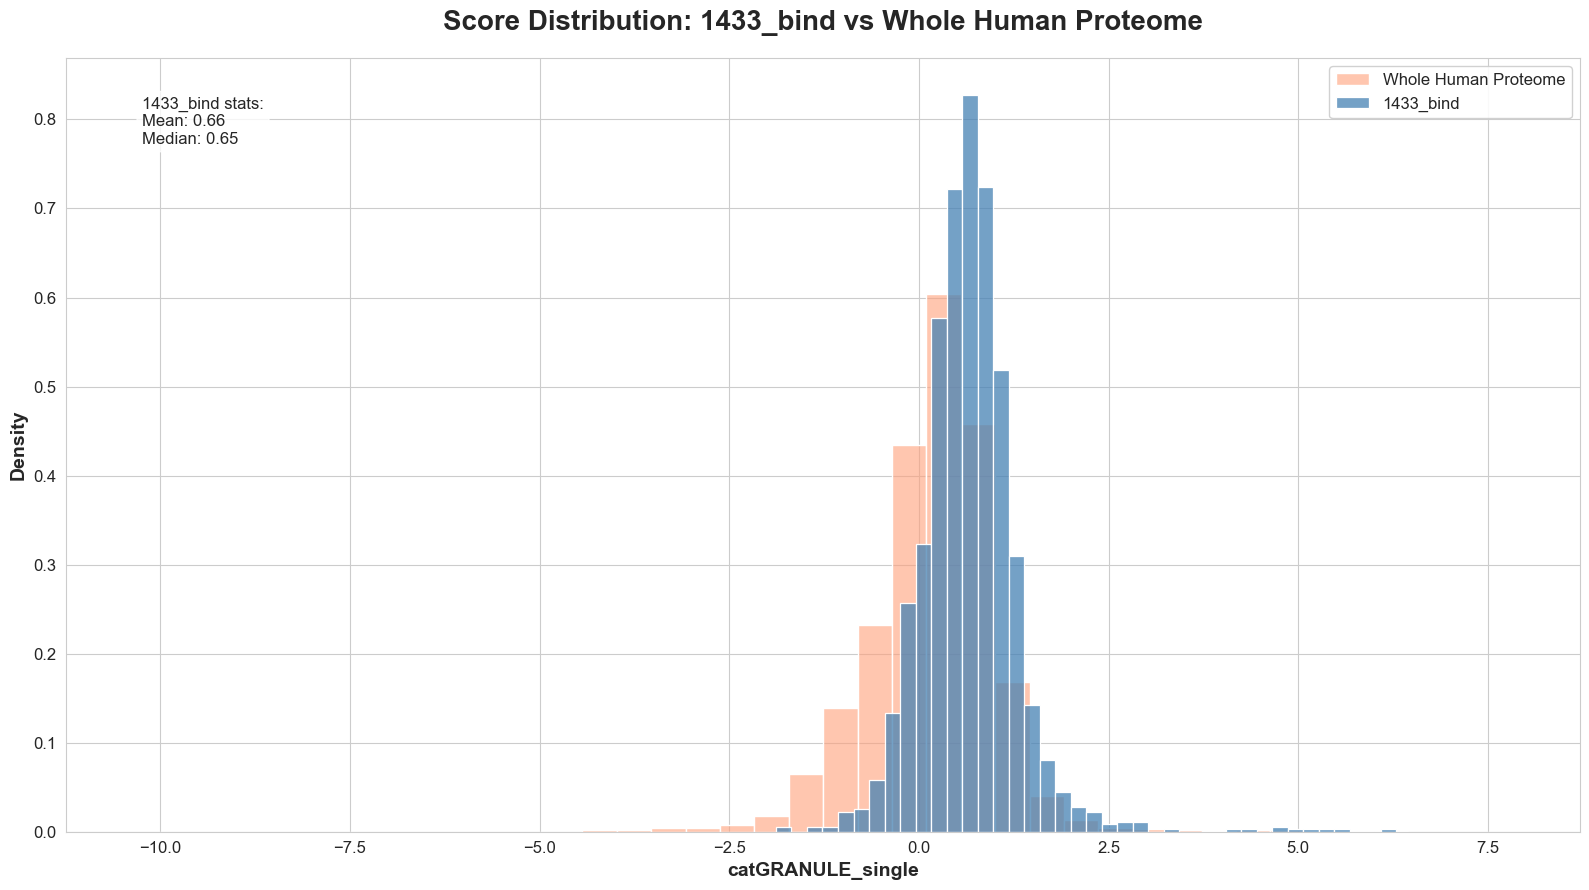

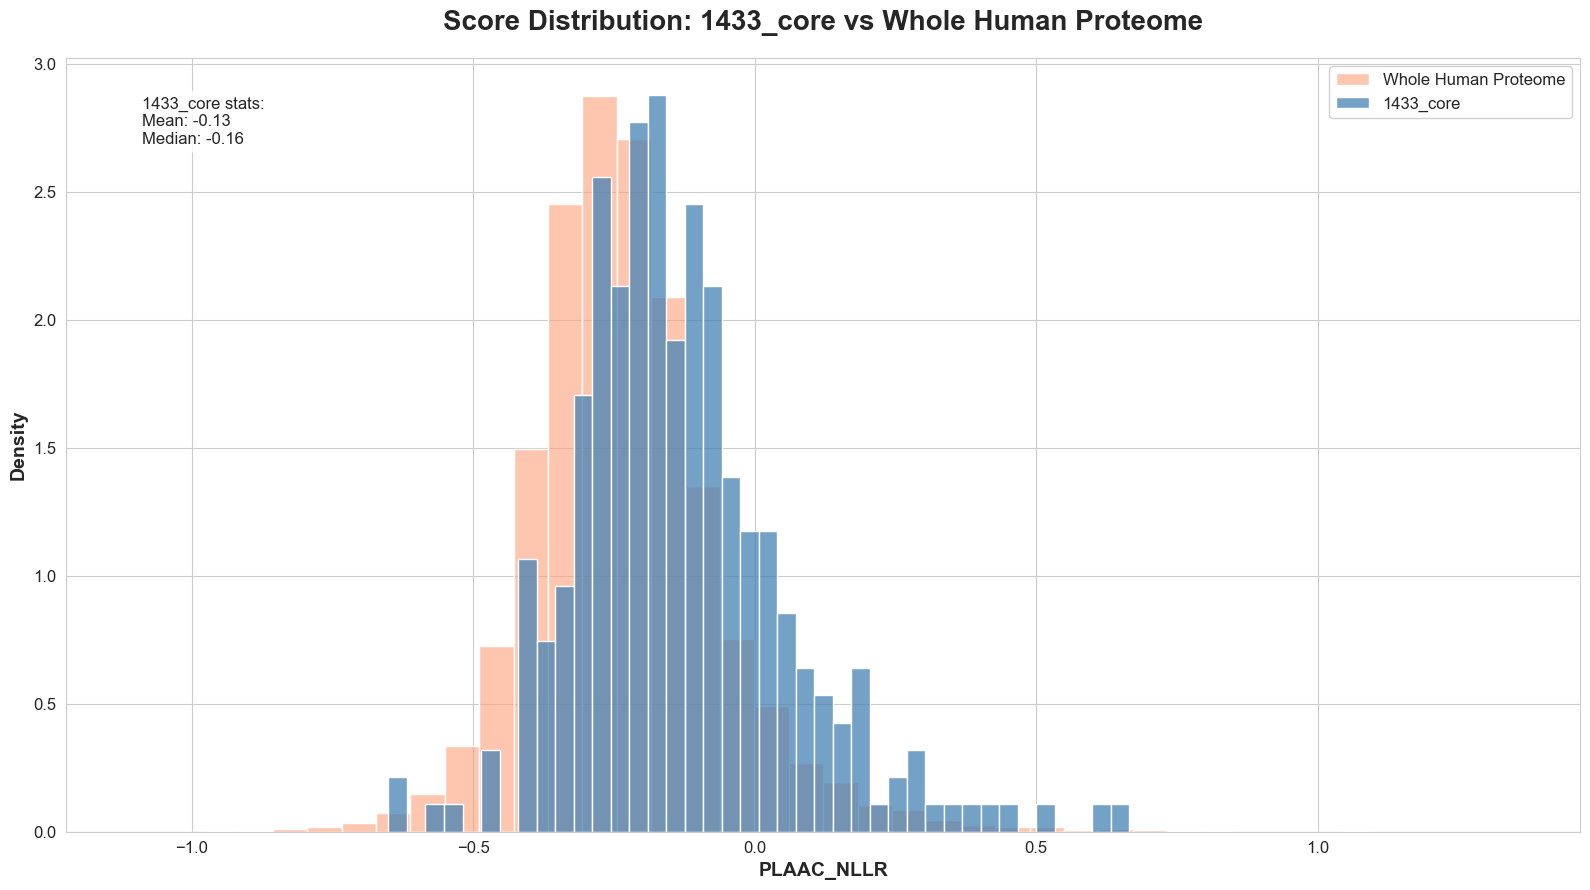

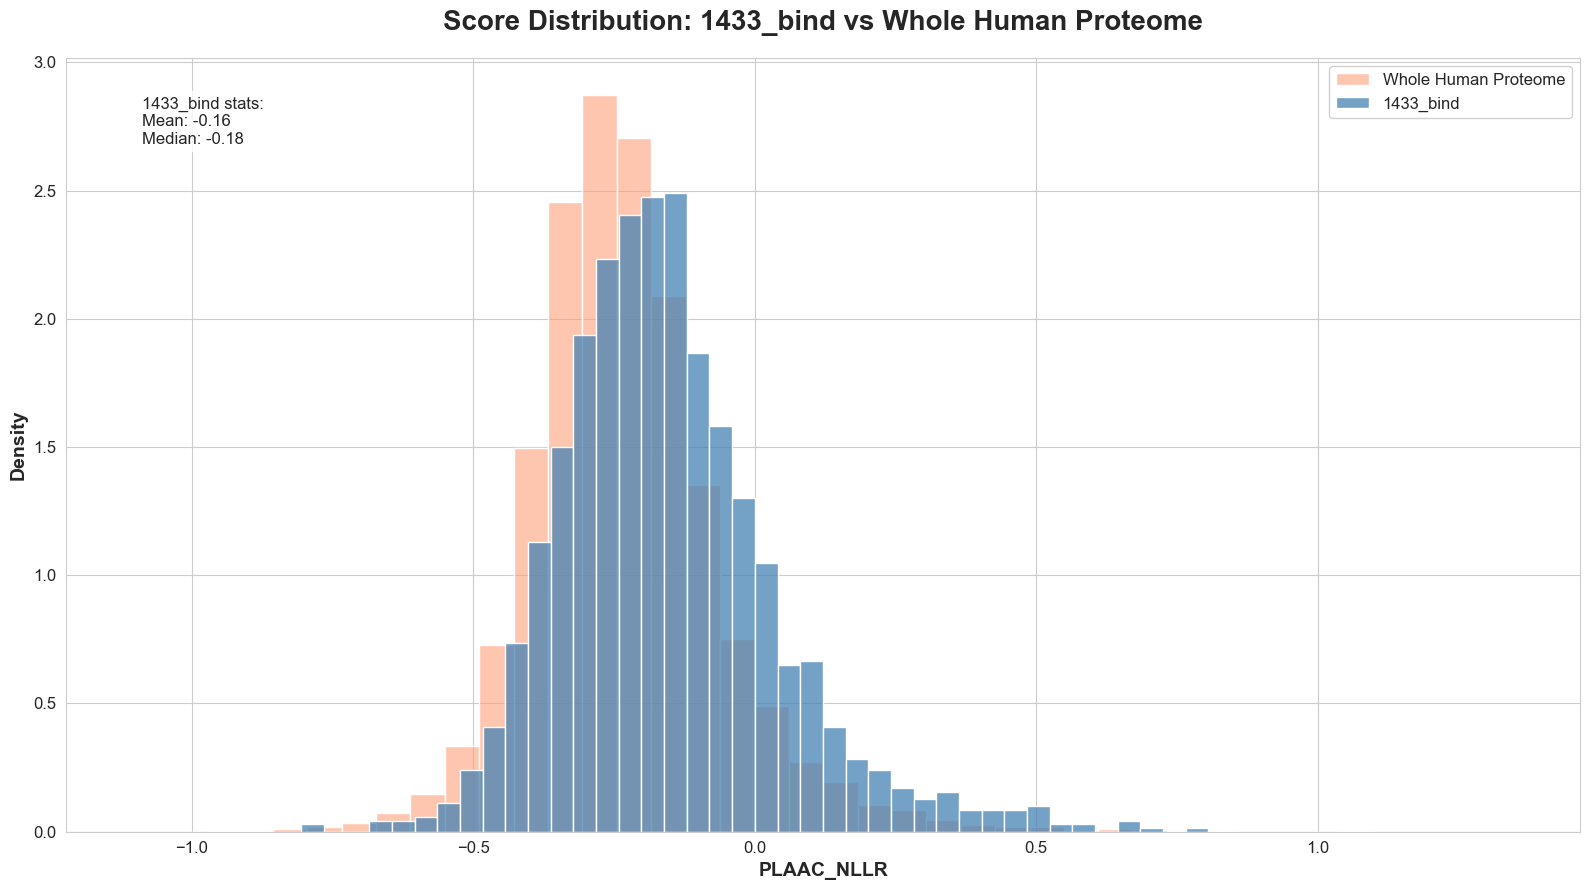

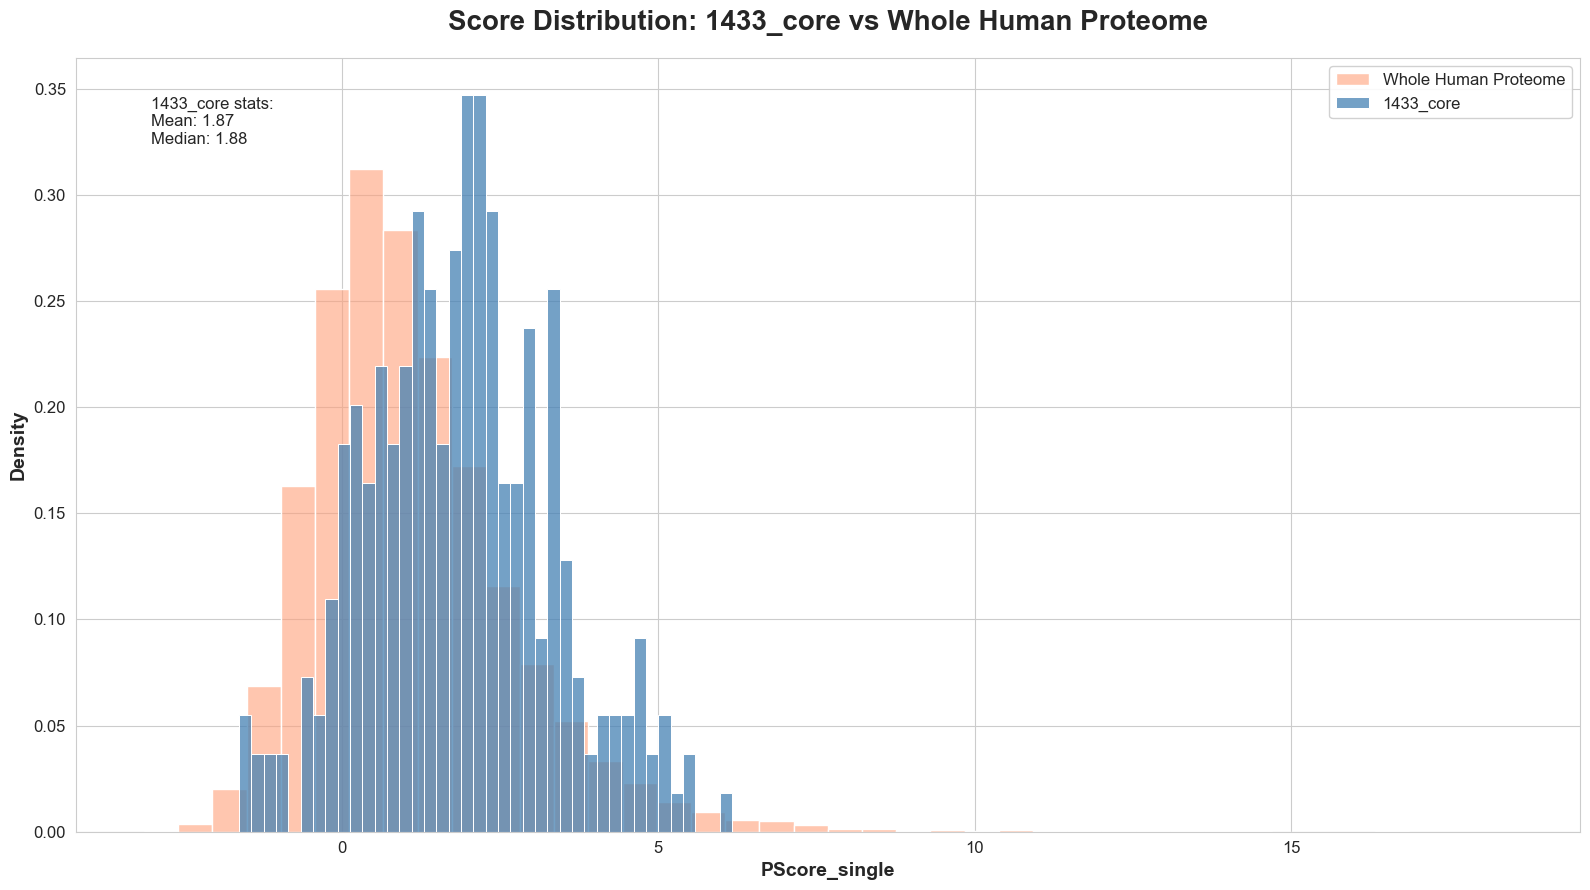

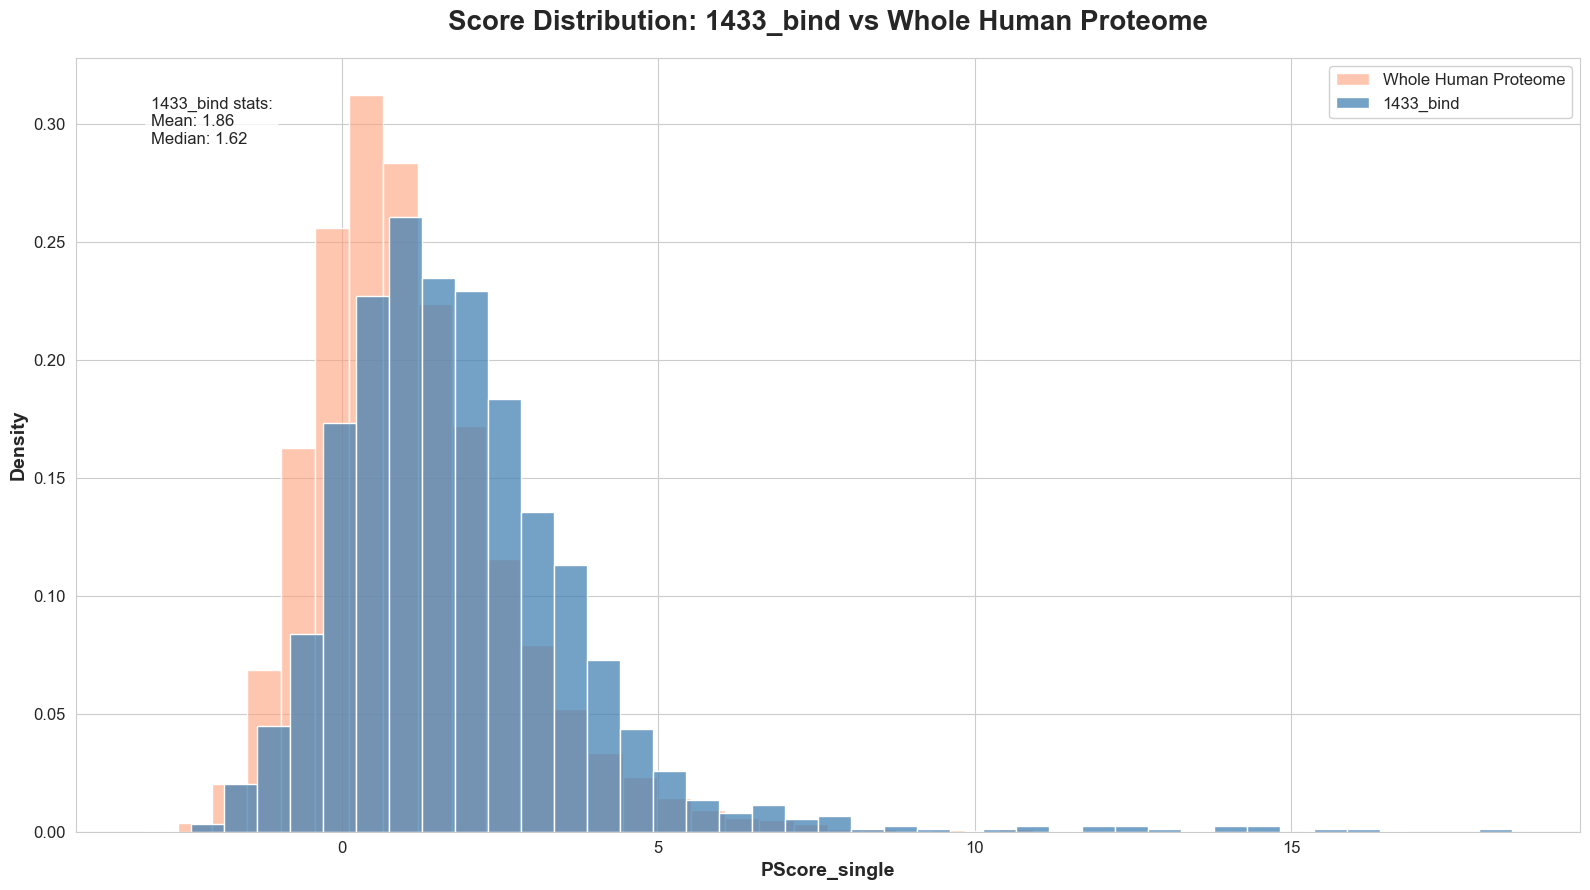

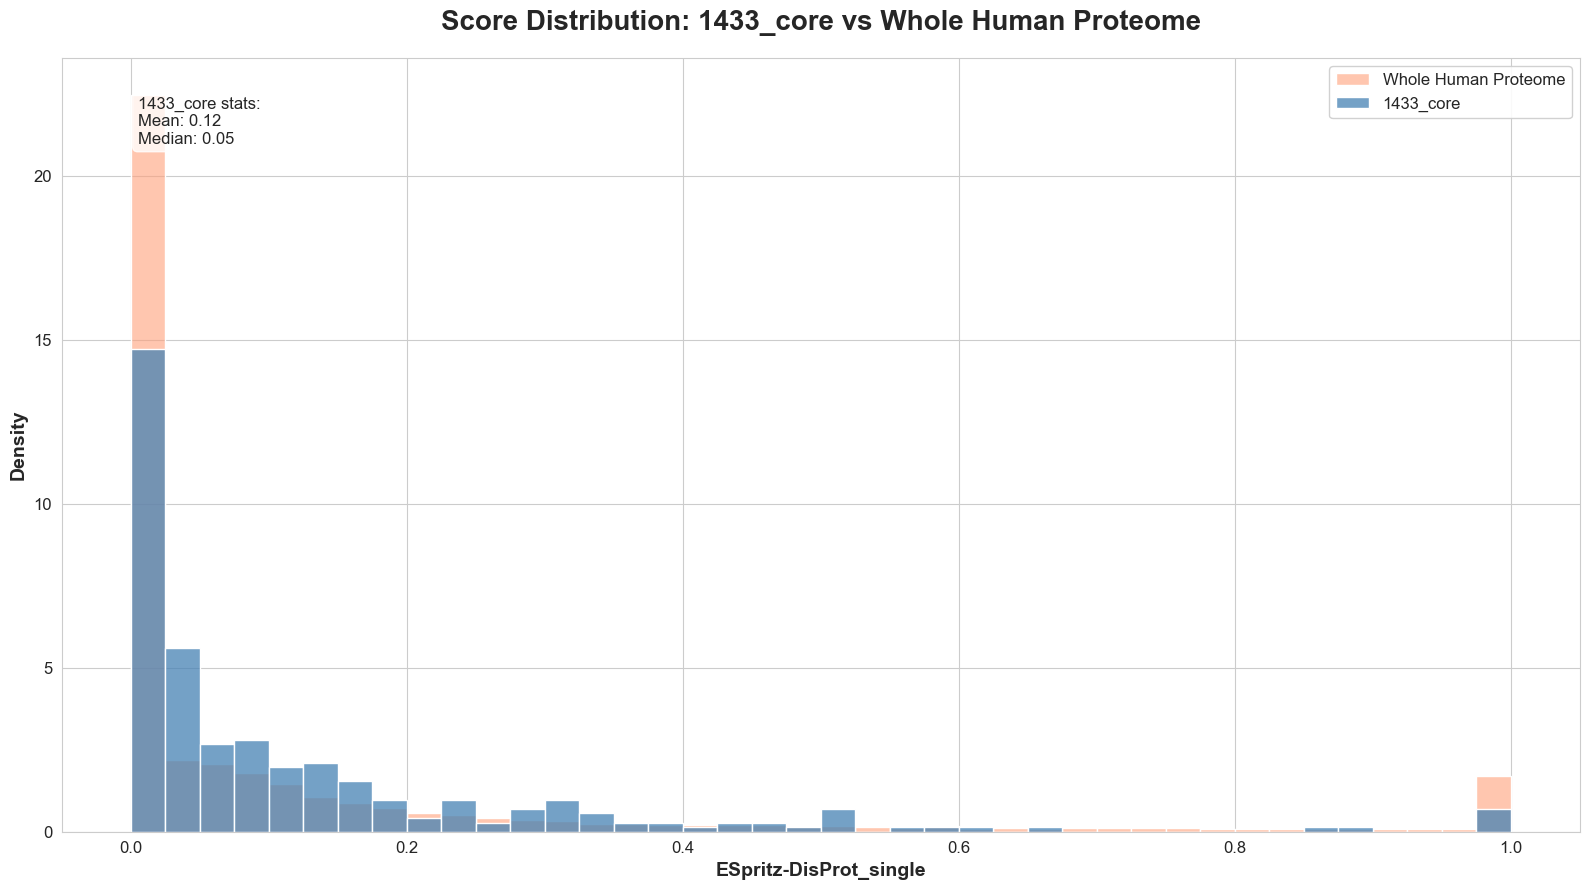

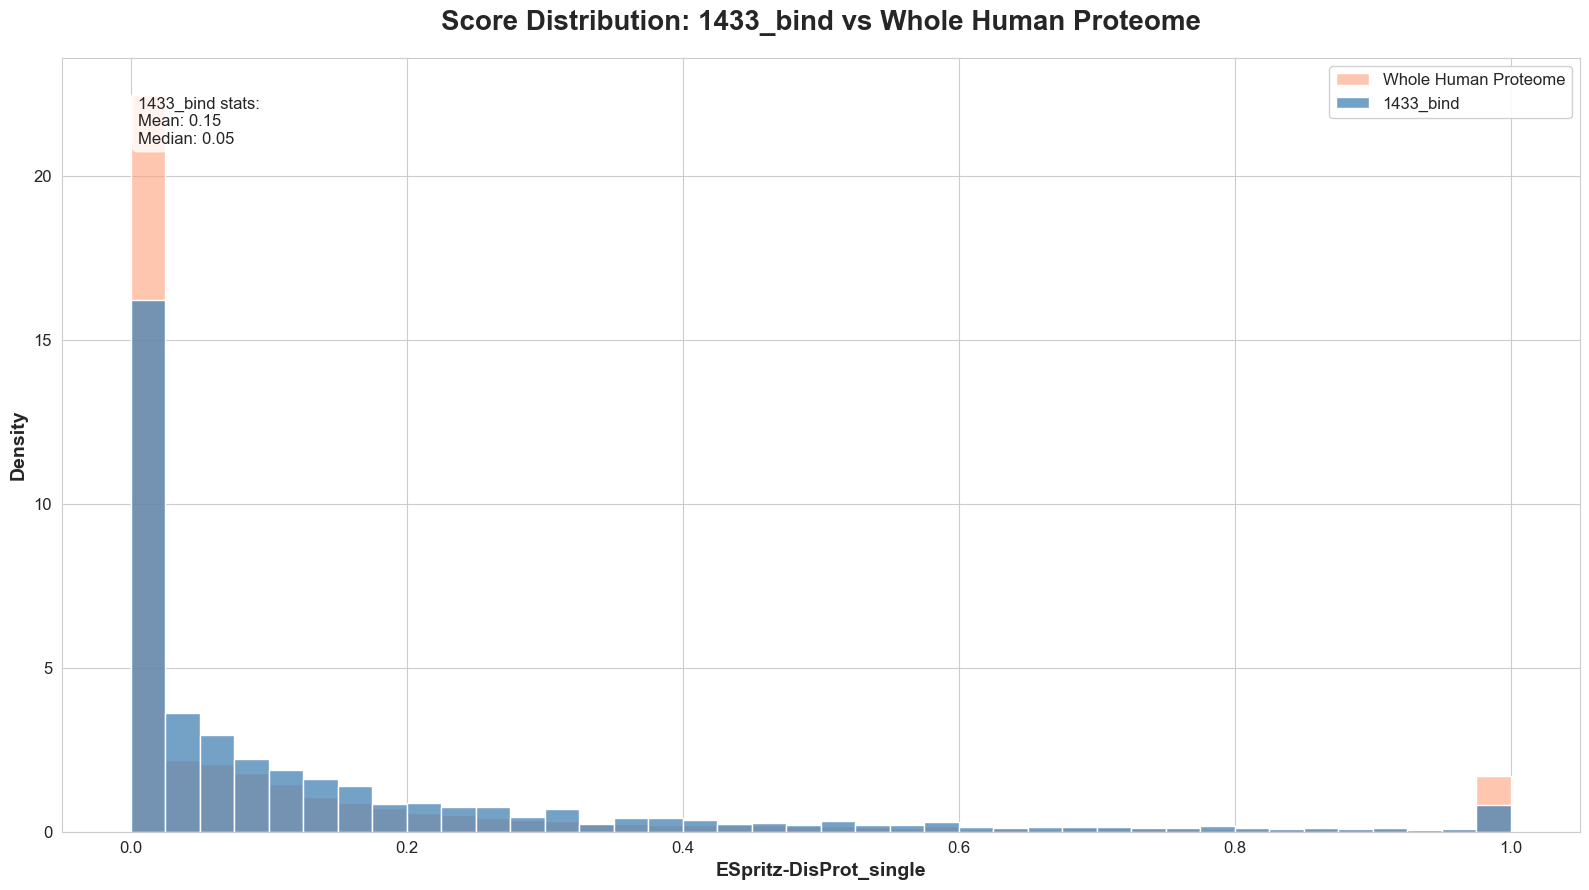

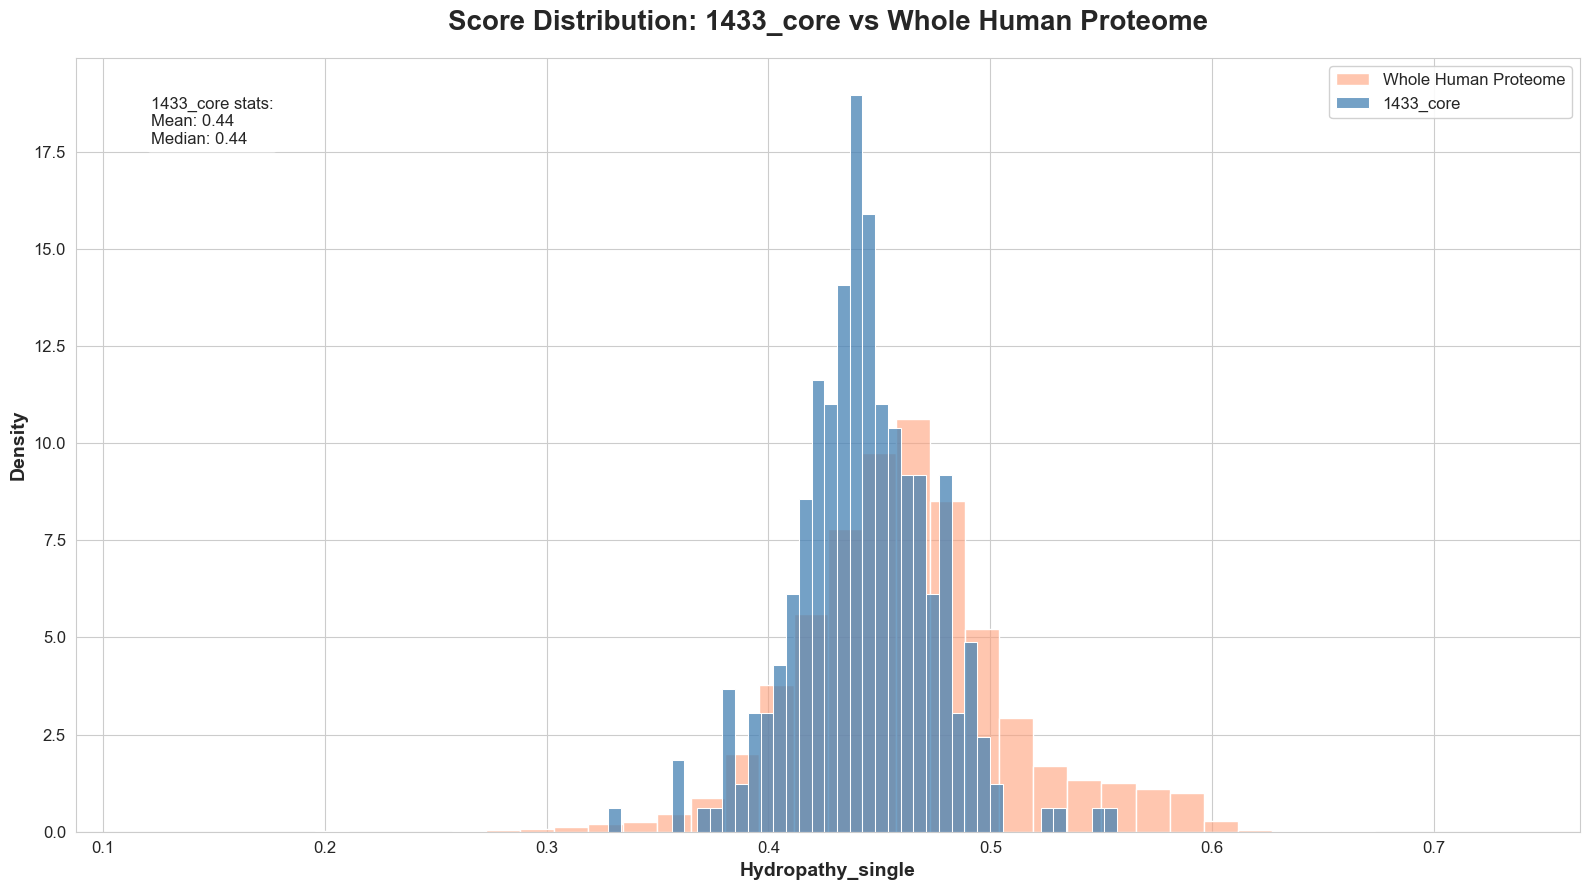

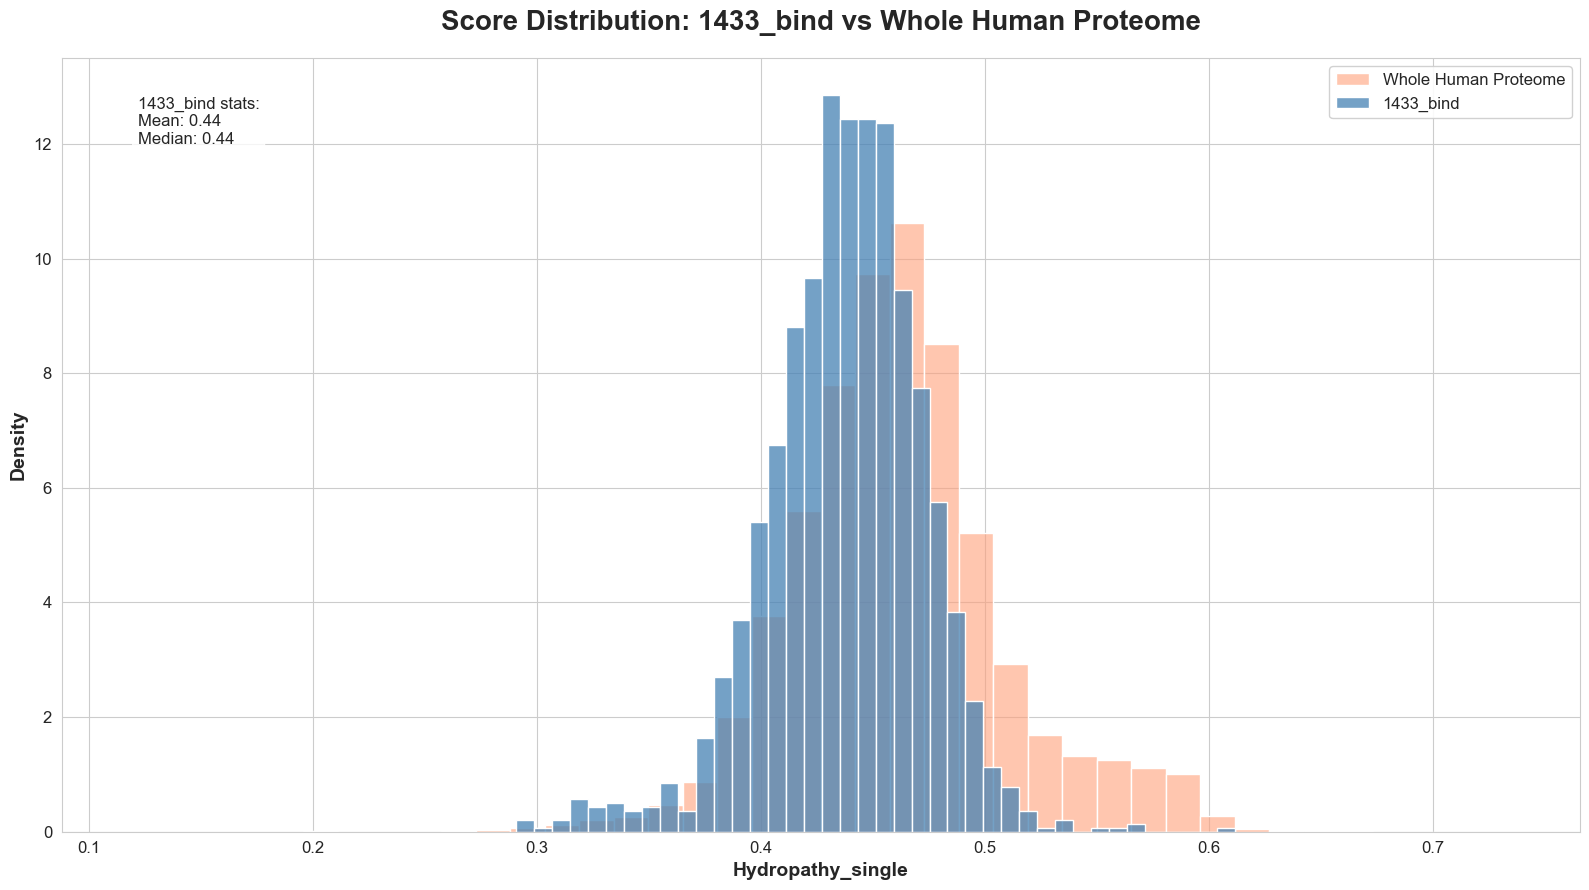

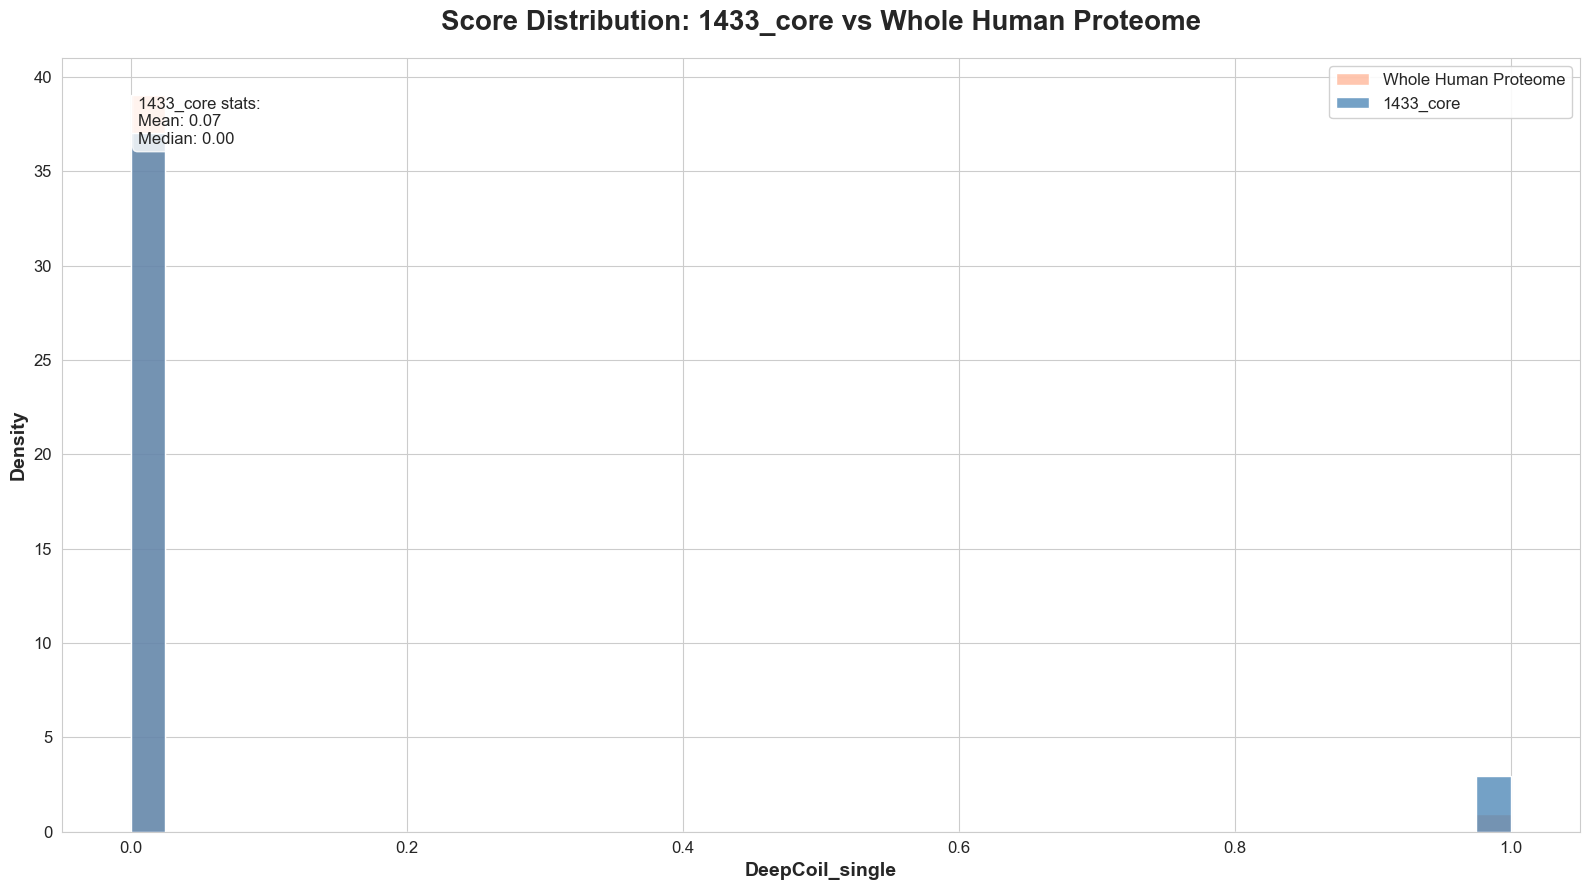

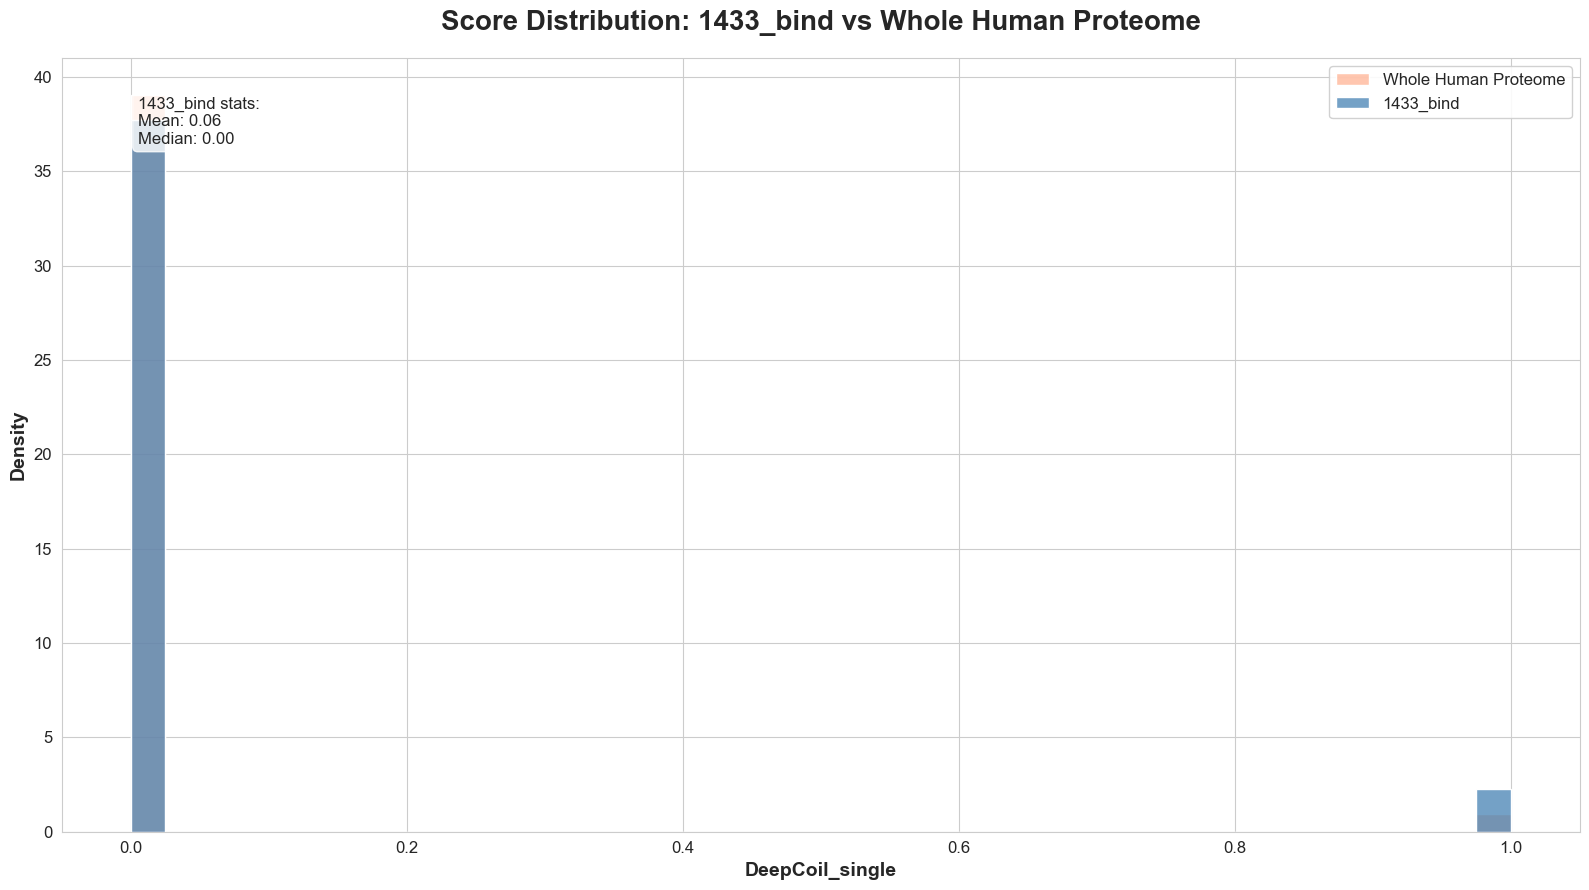

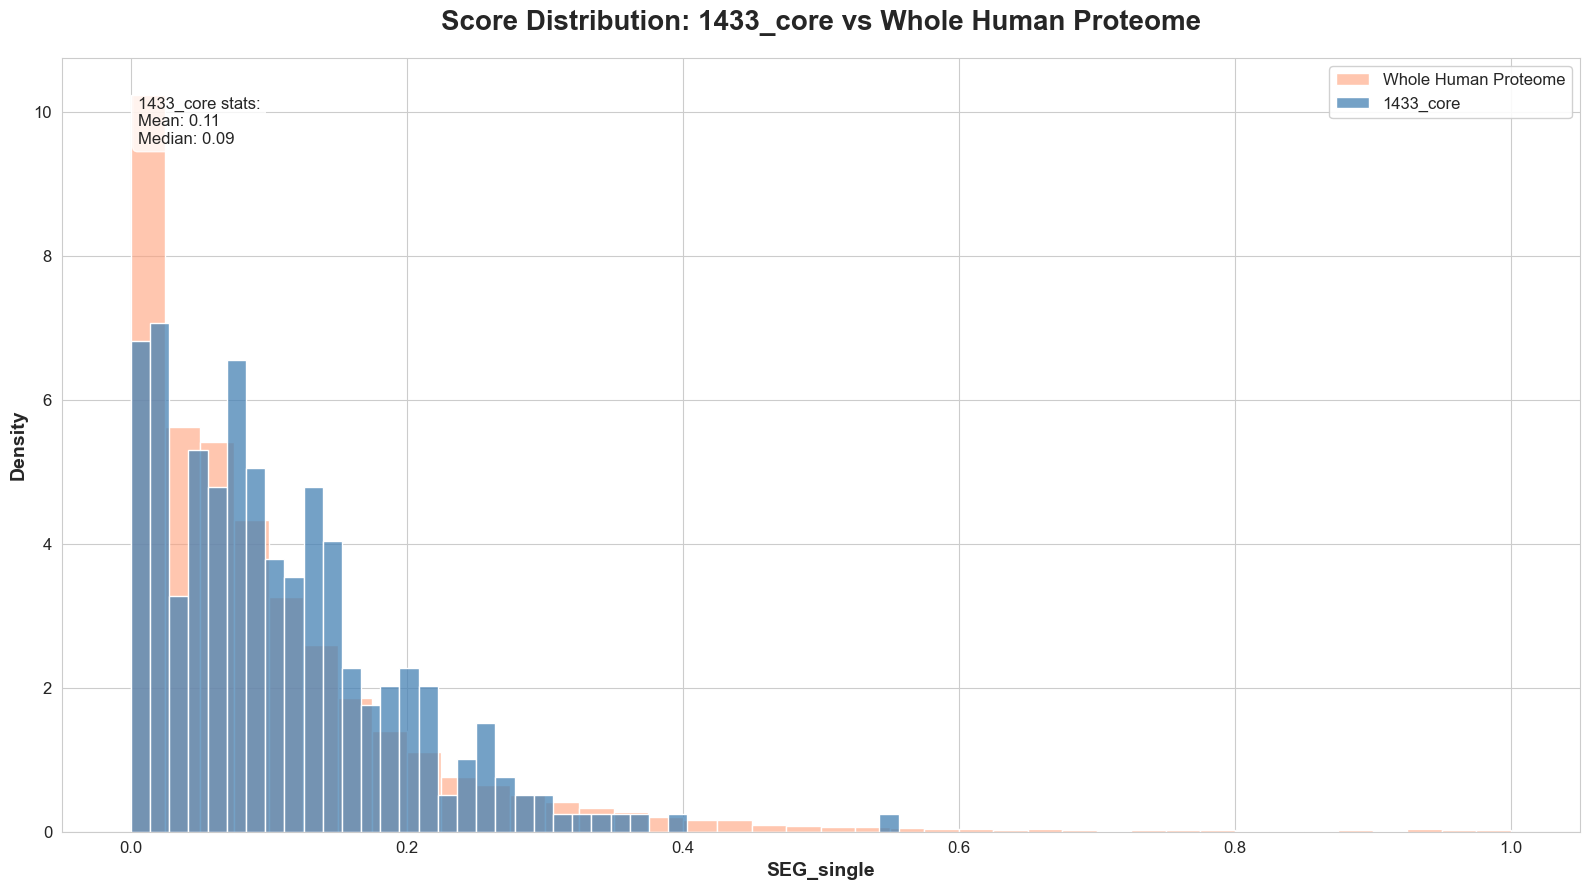

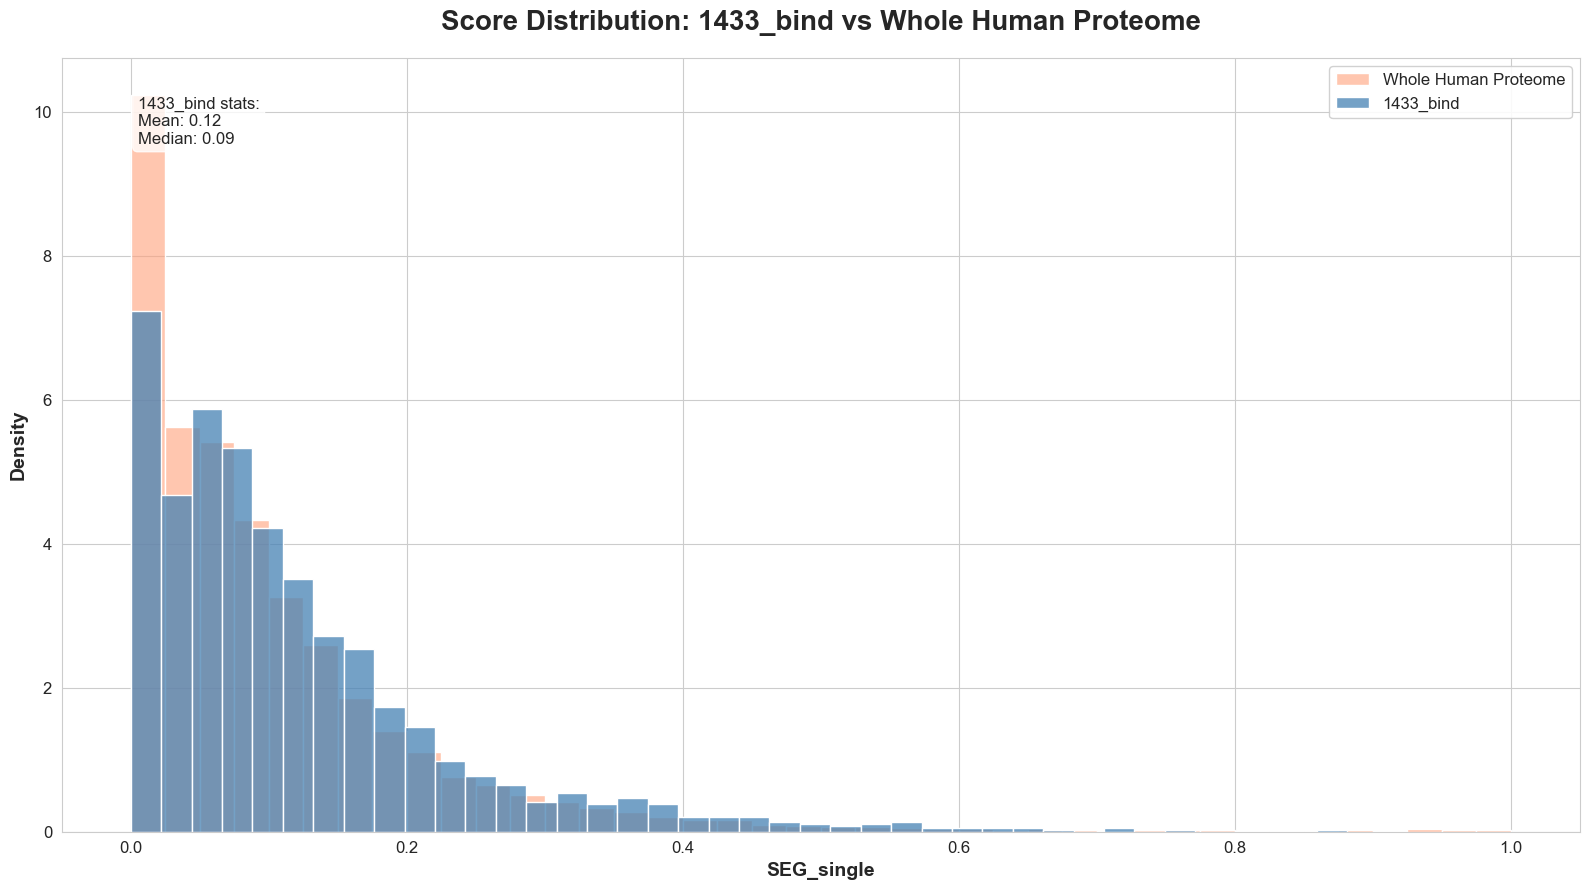

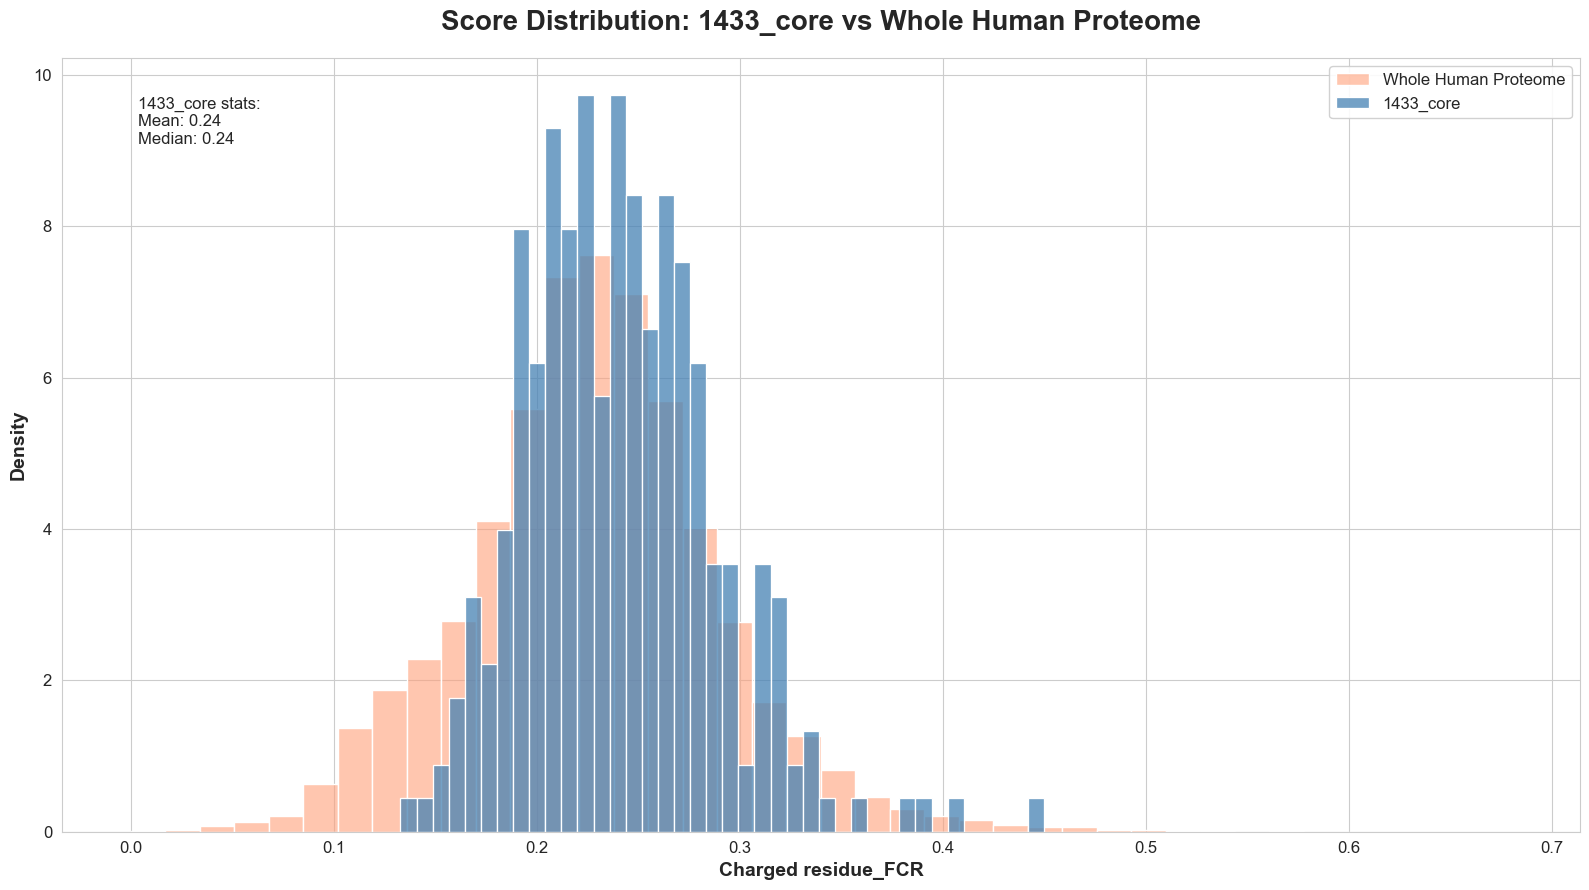

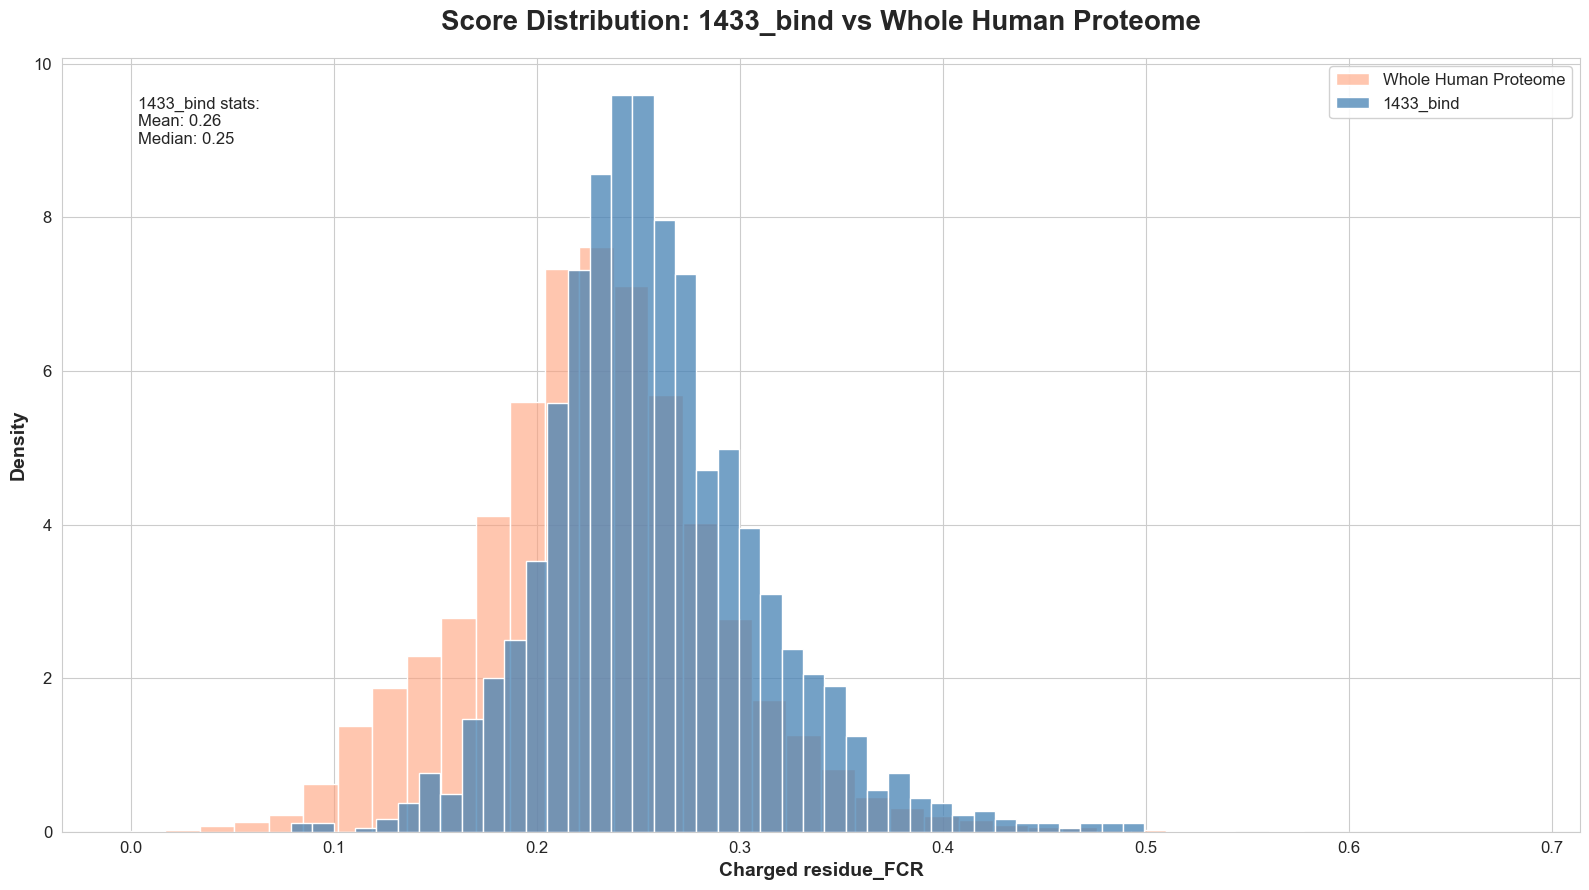

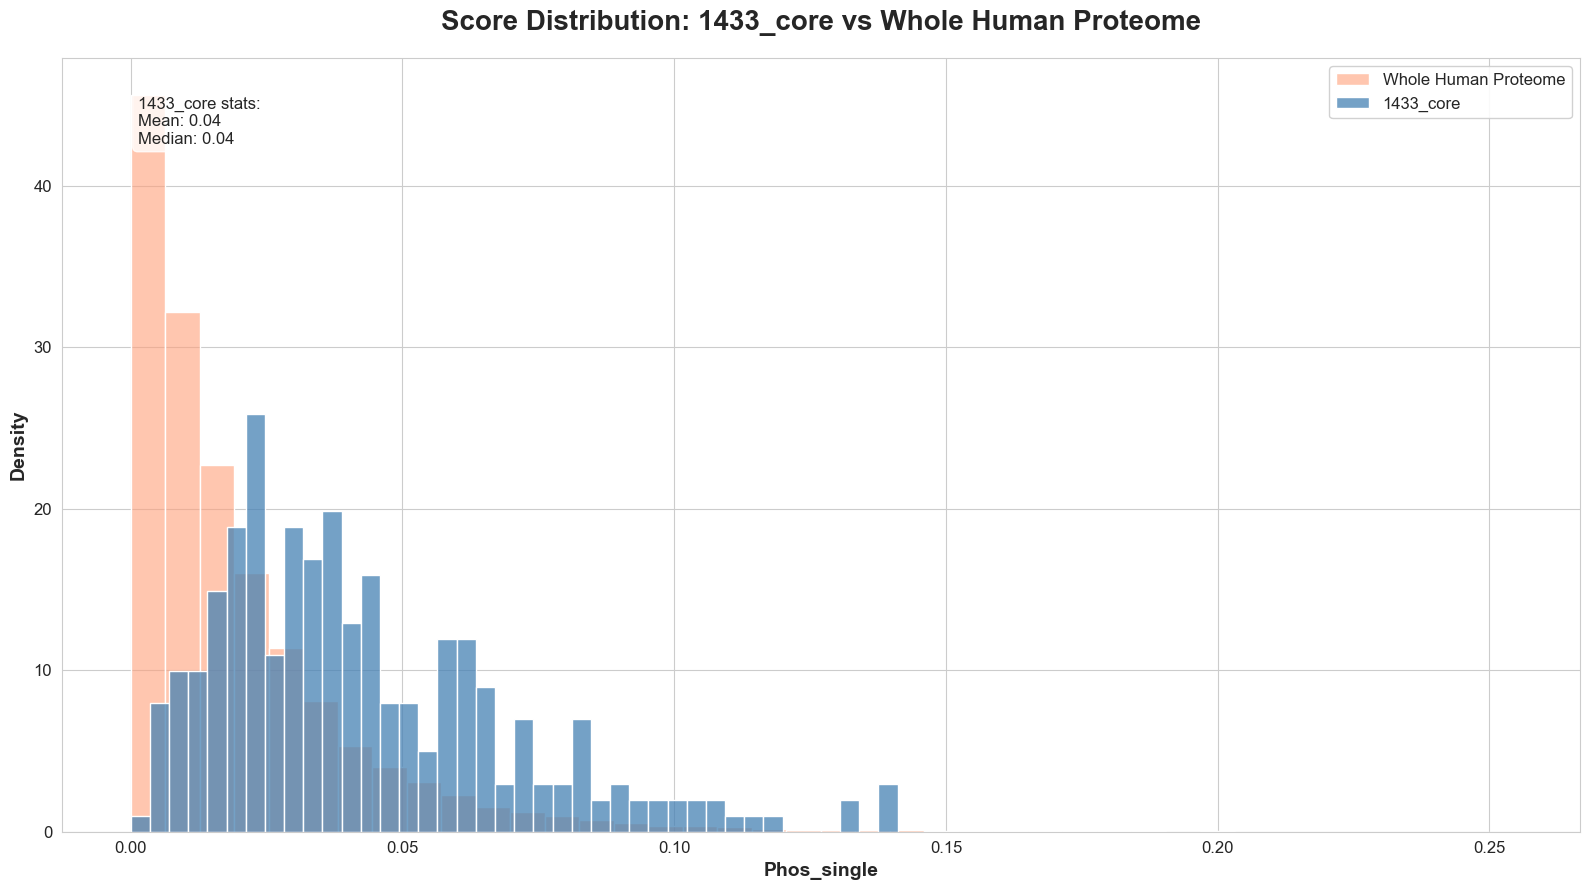

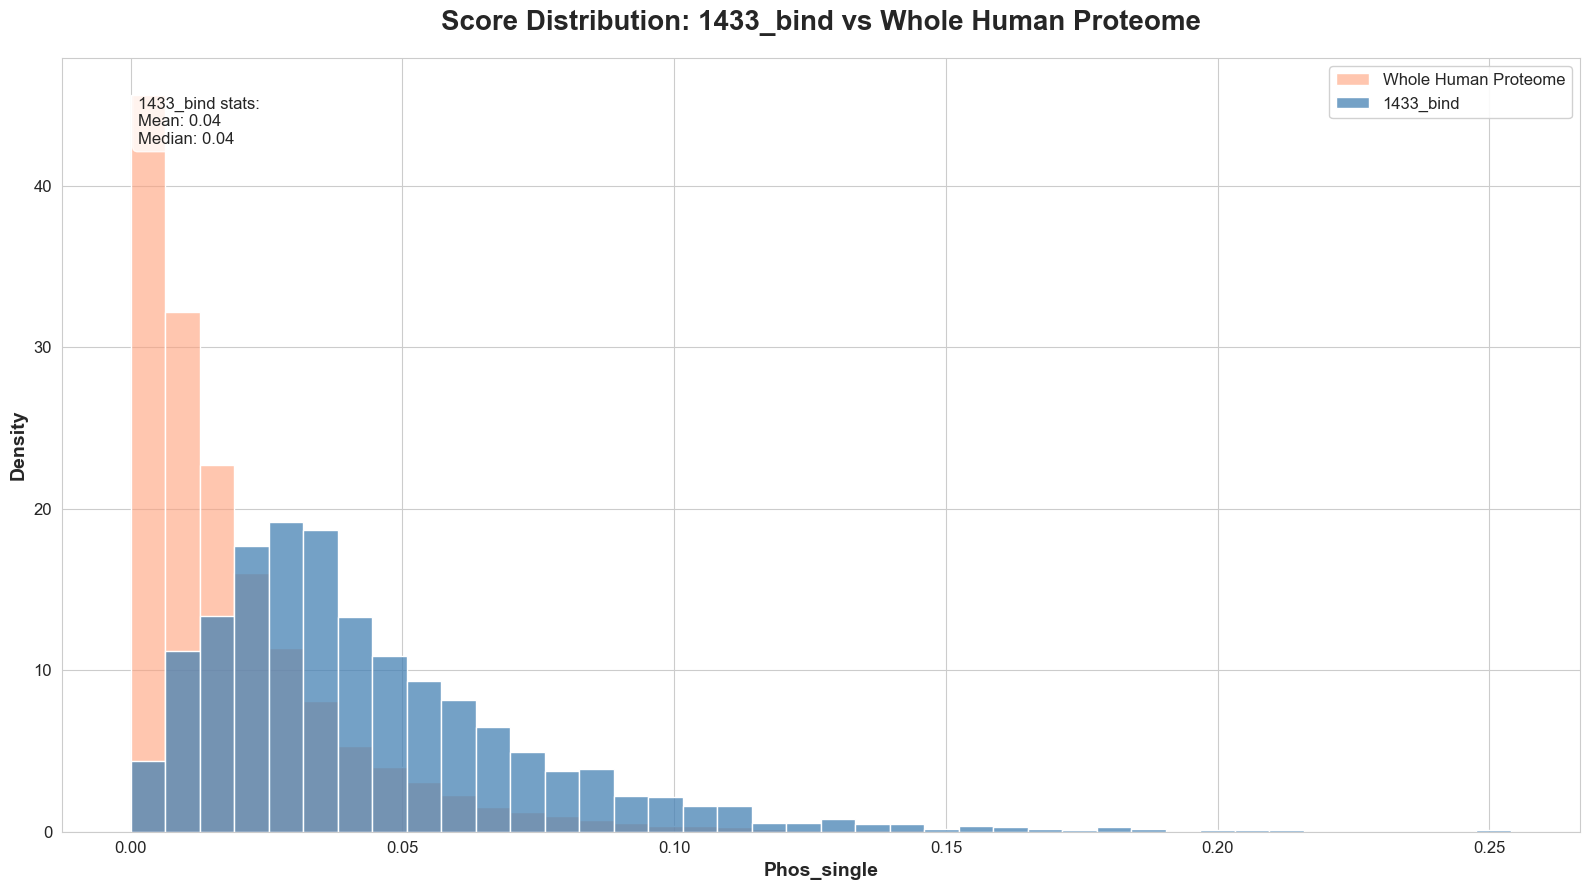

In [47]:
for column in score_columns:
    if column not in ['uniprot_id','Sequence']:
        if column not in phasepred_score_columns:
            distribution_go(Protein_1433_interactome_known_motif,"1433_core", df_PhaSePred,column, 'uniprot_id')
            distribution_go(Protein_1433_interactome,"1433_bind", df_PhaSePred,column, 'uniprot_id')

Task 10: We compared protein length, between the entire human proteome and 14-3-3 binding proteins.

In [48]:
# download the human proteome from uniprot as uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# uniprot download all the human reviewed protein sequence uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# https://www.uniprot.org/uniprotkb?query=reviewed%3Atrue&facets=model_organism%3A9606
# add 5 14-3-3 related sequence into it
import requests

# List of sequence identifiers
identifiers = ['Q05086-2', 'Q96RK0-2', 'Q9NS23-2', 'Q12802-2', 'Q9UQB8-5']

# Fetch sequence from UniProt
def fetch_sequence(identifier):
    url = f"https://www.uniprot.org/uniprot/{identifier}.fasta"
    response = requests.get(url)
    response.raise_for_status()
    return response.text

# Reformat the sequence header
def reformat_header(header):
    fields = header.split('|')
    if len(fields) == 3:
        entry = fields[1]
        description_parts = fields[2].split(' ', 1)
        if len(description_parts) == 2:
            protein_name = description_parts[0]
            details = description_parts[1]
            new_header = f">sp|{entry}|{protein_name} {details}"
            return new_header
    return header

# Fetch and reformat all sequences
sequences = []
for identifier in identifiers:
    fasta_sequence = fetch_sequence(identifier)
    sequence_lines = fasta_sequence.strip().split('\n')
    header = sequence_lines[0]
    sequence = '\n'.join(sequence_lines[1:])
    reformatted_header = reformat_header(header)
    reformatted_sequence = f"{reformatted_header}\n{sequence}"
    sequences.append(reformatted_sequence)

# Write sequences to the new FASTA file
output_filename = "data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta"
with open(output_filename, "a") as output_handle:
    for sequence in sequences:
        output_handle.write(sequence + "\n")

print(f"Sequences have been written to {output_filename}")

Sequences have been written to data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta


In [49]:
# calculate the distribution of protein length of 14-3-3 binding protein

# write a code to iterate through the protein in uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# save into a csv file, for each uniprot id, save the length of the protein
import pandas as pd
from Bio import SeqIO

def calculate_protein_lengths(fasta_file, output_csv):
    data = []
    
    # Parsing the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        if '|' in record.id:
            uniprot_id = record.id.split('|')[1]
        else:
            uniprot_id = record.id
        protein_length = len(record.seq)
        
        # Append the data to the list
        data.append([uniprot_id, protein_length])
    
    # Create a DataFrame from the list
    df = pd.DataFrame(data, columns=['UniProt ID', 'Protein Length'])
    
    # Save the DataFrame to a CSV file
    df.to_csv(output_csv, index=False)

# Define the input FASTA file and output CSV file
fasta_file = 'data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta'
output_csv = 'data/protein_lengths.csv'

# Call the function
calculate_protein_lengths(fasta_file, output_csv)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_protein_length_distribution(uniprot_ids, protein_lengths_csv):
    # Load the protein lengths CSV into a DataFrame
    df = pd.read_csv(protein_lengths_csv)
    
    # Filter out proteins with length 10 or less
    df = df[(df['Protein Length'] > 100)&(df['Protein Length'] < 5000)]
    
    # Filter the DataFrame to get the lengths of the proteins specified in the list of UniProt IDs
    filtered_df = df[df['UniProt ID'].isin(uniprot_ids)]

    # Print the shortest and longest protein length in the whole dataset
    shortest_protein_length_whole = df['Protein Length'].min()
    longest_protein_length_whole = df['Protein Length'].max()
    print(f"Shortest protein length in the whole dataset: {shortest_protein_length_whole}")
    print(f"Longest protein length in the whole dataset: {longest_protein_length_whole}")

    # Print the shortest and longest protein length in the filtered dataset
    if not filtered_df.empty:
        shortest_protein_length_filtered = filtered_df['Protein Length'].min()
        longest_protein_length_filtered = filtered_df['Protein Length'].max()
        print(f"Shortest protein length in the filtered dataset: {shortest_protein_length_filtered}")
        print(f"Longest protein length in the filtered dataset: {longest_protein_length_filtered}")
        print(f"There are {len(filtered_df)} proteins in the dataset")
    else:
        print("No proteins found in the filtered dataset with length > 100.")
    
    # Set up the plots
    plt.figure(figsize=(12, 6))
    
    # Plot the distribution of the whole proteome
    sns.kdeplot(df['Protein Length'], label='Whole Proteome', shade=True)
    
    # Plot the distribution of the specified proteins' lengths
    sns.kdeplot(filtered_df['Protein Length'], label='Selected Proteins', shade=True)
    
    # Add titles and labels
    plt.title('Protein Length Distribution Comparison')
    plt.xlabel('Protein Length')
    plt.ylabel('Density')
    plt.legend()
    
    # Show the plot
    plt.show()

# Define the path to the protein lengths CSV file
protein_lengths_csv = 'data/protein_lengths.csv'

Shortest protein length in the whole dataset: 101
Longest protein length in the whole dataset: 4981
Shortest protein length in the filtered dataset: 126
Longest protein length in the filtered dataset: 3926
There are 305 proteins in the dataset


/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/329077515.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Protein Length'], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/329077515.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_df['Protein Length'], label='Selected Proteins', shade=True)


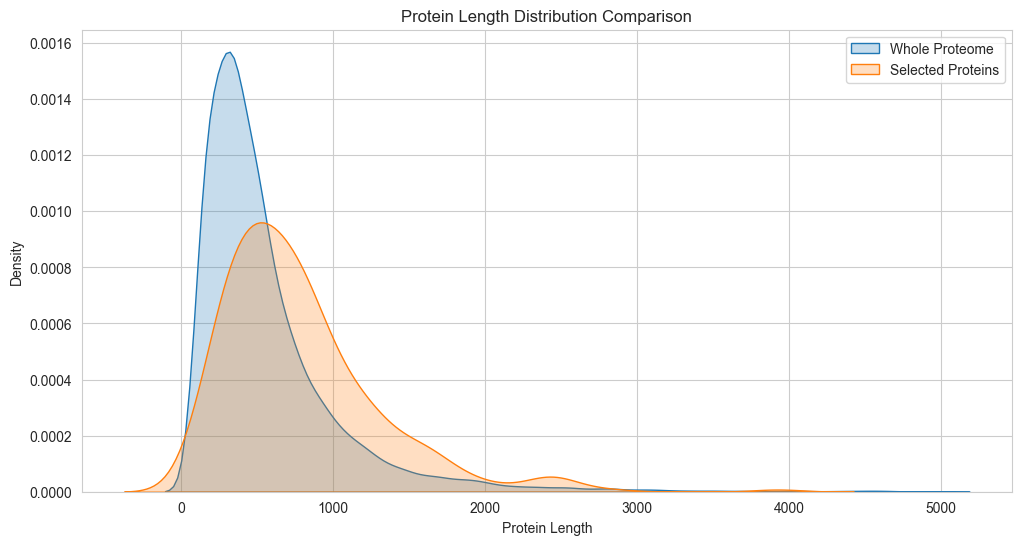

Shortest protein length in the whole dataset: 101
Longest protein length in the whole dataset: 4981
Shortest protein length in the filtered dataset: 103
Longest protein length in the filtered dataset: 4861
There are 1733 proteins in the dataset


/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/329077515.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Protein Length'], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/329077515.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_df['Protein Length'], label='Selected Proteins', shade=True)


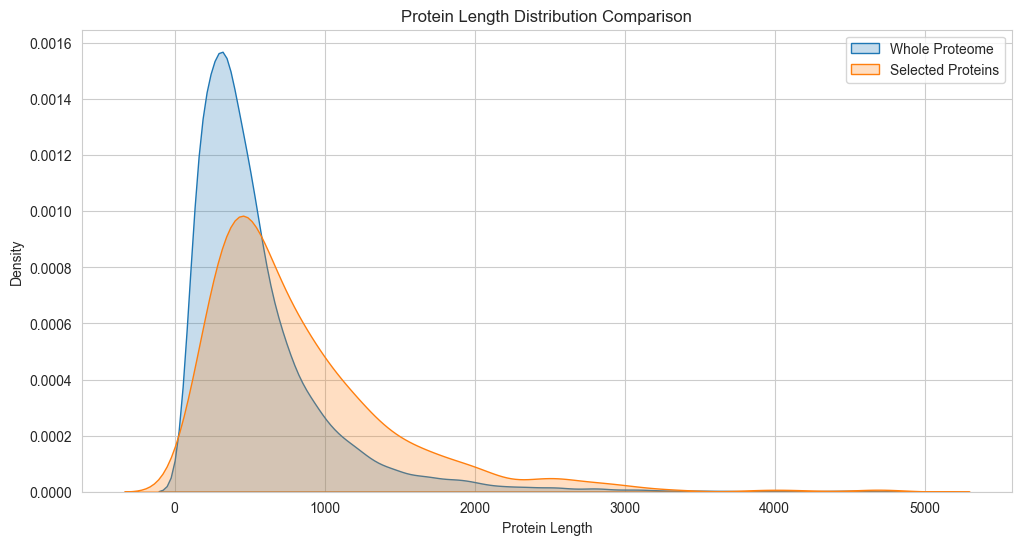

In [51]:
compare_protein_length_distribution(Protein_1433_interactome_known_motif, protein_lengths_csv)
compare_protein_length_distribution(Protein_1433_interactome, protein_lengths_csv)

# 2	Structural Context of 14-3-3 Binding Sites within Intrinsically Disordered Regions

2.1	Characterization of IDR Properties at Binding Sites

Task 14: Predict the IDR scores of 14-3-3 binding sites using IUPred2A.

In [52]:
# https://iupred2a.elte.hu/
# download IUPred2A package and put into src/files folder 

In [53]:
# iterate through the protein in uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# Predict using 'iupred2a_lib.iupred(sequence)'. Using the optional arg 'mode' it can be selected whether to predict long or short disorder. 
# iterate the fasta file, for each sequence, predict it with iupred2a using 'iupred2a_lib.iupred(sequence)'
# predict anchor2 using (iupred2a_lib.anchor2(sequence)) 
# save the each prediction result (iupred and anchor score) as a csv file, using uniprotid as the csv file name

In [54]:
# !pip install biopython

In [55]:
fasta_file = "data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta"
if not os.path.isfile(fasta_file):
    print(f"FASTA file '{fasta_file}' not found.")
    sys.exit(1)

In [56]:
import os
import sys
import pandas as pd
import numpy as np
import src.files.iupred2a.iupred2a_lib as iupred2a_lib
from Bio import SeqIO

def process_sequence(uniprot_id, sequence, iupred_type, path, anchor):
    try:
        # Create the directory if it doesn't exist
        if not os.path.exists(path):
            os.makedirs(path)
        # Predict disorder using iupred2a_lib
        iupred_scores = iupred2a_lib.iupred(sequence, iupred_type)[0]

        # Predict anchor regions using iupred2a_lib if anchor is enabled
        anchor_scores = iupred2a_lib.anchor2(sequence)[0] if anchor else [None] * len(sequence)

        # Prepare the data for saving into a CSV file
        data = {
            "position": list(range(1, len(sequence) + 1)),
            "amino_acid": list(sequence),
            "iupred_score": iupred_scores,
            "anchor_score": anchor_scores,
        }

        # Create a DataFrame from the data
        df = pd.DataFrame(data)

        # Save the DataFrame to a CSV file named by the UniProt ID
        csv_filename = os.path.join(path, f"{uniprot_id}.csv")
        df.to_csv(csv_filename, index=False)
        print(f"Results saved for {uniprot_id} in {csv_filename}")
    except ImportError:
        sys.exit("ERROR: The import of iupred2a_lib failed! Most likely the PYTHONPATH has not been set correctly according to the README file.")


def human_proteome_disorder_cal(fasta_file):
    # Parsing the FASTA file
    for record in SeqIO.parse(fasta_file, "fasta"):
        uniprot_id = record.id.split('|')[1] if '|' in record.id else record.id
        sequence = str(record.seq)
        process_sequence(uniprot_id, sequence, "long", "data/human_proteome_discorder_anchor_score", 1)

In [57]:
# human_proteome_disorder_cal(fasta_file)

Task 15: We confirmed that 14-3-3 binding sites are predicted to have higher IDR scores compared to all serine/threonine sites.

In [58]:
# aggregate the calculated IDR and anchor score for all the S/T sites in the human proteome
import pandas as pd
import os

def collect_st_amino_acids(folder_path):
    # Initialize an empty DataFrame to hold the collected data
    collected_data = pd.DataFrame()

    # Iterate through each file in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            # Filter the DataFrame for rows where amino_acid is 'S' or 'T'
            filtered_df = df[df['amino_acid'].isin(['S', 'T'])]

            filename_pre = filename.split('.')[0]
            # Rename the index to match the format filename_amino_acid_position
            filtered_df.index = [f"{filename_pre}_{row['amino_acid']}_{row['position']}" for _, row in filtered_df.iterrows()]

            # Append the filtered data to the collected_data DataFrame
            collected_data = pd.concat([collected_data, filtered_df])

    return collected_data

# Define the folder path
folder_path = 'data/human_proteome_discorder_anchor_score'

# Collect the data
# st_amino_acids_df = collect_st_amino_acids(folder_path)

# Print the collected DataFrame
# print(st_amino_acids_df)

# Optionally, save the collected DataFrame to a CSV file
# st_amino_acids_df.to_csv('data/collected_st_amino_acids_idrscore_anchorscore.csv')

In [59]:
# download phosphorylation dataset from phosphorysite
# name as Phosphorylation_site_dataset.xlsx
def process_mod_rsd(mod_rsd):
    """
    Process the MOD_RSD value to replace a pattern like S119-p with S_119.
    
    Parameters:
    mod_rsd (str): The original MOD_RSD value.
    
    Returns:
    str: The processed MOD_RSD value.
    """
    if '-' in mod_rsd:
        parts = mod_rsd.split('-')
        return f"{parts[0][0]}_{parts[0][1:]}"
    return mod_rsd


def collect_human_sites(df):
    """
    Collects all human dataset entries from the provided DataFrame where the 8th position letter 
    in the SITE_+/-7_AA column is lowercase 's' or 't'. Each row in the returned DataFrame is 
    named using the format ACC_ID_MOD_RSD with processed MOD_RSD.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with the protein modification data.
    
    Returns:
    pd.DataFrame: Filtered and indexed DataFrame.
    """
    
    # Filter the DataFrame for human datasets
    human_df = df[df['ORGANISM'] == 'human']

    # Further filter the DataFrame where the 8th position letter in the SITE_+/-7_AA column is lowercase 's' or 't'
    filtered_human_df = human_df[human_df['SITE_+/-7_AA'].str[7].isin(['s', 't'])]

    # Process the MOD_RSD values
    filtered_human_df['MOD_RSD'] = filtered_human_df['MOD_RSD'].apply(process_mod_rsd)

    # Set the index using the format ACC_ID_MOD_RSD
    filtered_human_df.index = filtered_human_df.apply(lambda row: f"{row['ACC_ID']}_{row['MOD_RSD']}", axis=1)

    return filtered_human_df

phosphodata_path = "data/Phosphorylation_site_dataset.xlsx"

df = pd.read_excel(phosphodata_path, skiprows=3)

# Apply the function
filtered_human_df = collect_human_sites(df)

# # Print the filtered DataFrame
# print(filtered_human_df)

# Optionally, save the filtered DataFrame to a CSV file
filtered_human_df.to_csv('data/konwn_human_phosphorylated_site_from_phosphosite.csv')

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/709218120.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_human_df['MOD_RSD'] = filtered_human_df['MOD_RSD'].apply(process_mod_rsd)


In [60]:
# count the number of konwn_human_phosphorylated_site_from_phosphosite
filtered_human_df = pd.read_csv('data/konwn_human_phosphorylated_site_from_phosphosite.csv')
konwn_human_phosphorylated_site = set(filtered_human_df["Unnamed: 0"])
len(konwn_human_phosphorylated_site)

200611

In [61]:
# preprocess the collected 14-3-3 site into a uniprot_aminoacid_postion index

def process_string(value):
    # Split the value by '/' to handle scenarios with multiple modifications
    parts = value.split('/')
    for part in parts:
        # Check if the first and last characters of the part match the criteria
        if part[0].isupper() and part[-1].islower() and part[0].upper() == part[-1].upper():
            return f"{part[0].upper()}_{part[1:-1]}"
    
    # If none of the parts match the criteria, return None or handle accordingly
    return None


def collect_1433_sites(df):
    """
    Collects 14-3-3 dataset entries from the provided DataFrame. Each row in the returned DataFrame is 
    named using the format ACC_ID with amino acid and position.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with the protein modification data.
    
    Returns:
    pd.DataFrame: Filtered and indexed DataFrame.
    """
    
    # Filter the DataFrame for human datasets
    filtered_df = df[df['label'] == 1]

    # Process the MOD_RSD values
    filtered_df['human Site and Mutation'] = filtered_df['human Site and Mutation'].apply(process_string)

    # Set the index using the format ACC_ID_MOD_RSD
    filtered_df.index = filtered_df.apply(lambda row: f"{row['human homology accession']}_{row['human Site and Mutation']}", axis=1)

    return filtered_df

phosphodata_path = "data/Table 1.csv"

df = pd.read_csv(phosphodata_path)

# Apply the function
filtered_1433_df = collect_1433_sites(df)

# # Print the filtered DataFrame
# print(filtered_1433_df)

# Optionally, save the filtered DataFrame to a CSV file
filtered_1433_df.to_csv('data/1433_phosphorylated_site.csv')

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/7348465.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['human Site and Mutation'] = filtered_df['human Site and Mutation'].apply(process_string)


In [62]:
filtered_1433_df = pd.read_csv('data/1433_phosphorylated_site.csv')
konwn_1433_site = set(filtered_1433_df["Unnamed: 0"])
len(konwn_1433_site)

427

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_protein_feature_distribution(uniprot_ids_1433, uniprot_ids_known_phospho, protein_lengths_csv, columnname):
    # Load the protein lengths CSV into a DataFrame
    df = pd.read_csv(protein_lengths_csv)
    
    # Filter the DataFrame to get the lengths of the proteins specified in the list of UniProt IDs
    filtered_1433_df = df[df["Unnamed: 0"].isin(uniprot_ids_1433)]
    filtered_known_phospho_df = df[df["Unnamed: 0"].isin(uniprot_ids_known_phospho)]    
    # Set up the plots
    plt.figure(figsize=(12, 6))
    
    # Plot the distribution of the whole proteome
    sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
    
    # Plot the distribution of the 1433 site
    sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)

    # Plot the distribution of the phospho site
    sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)
    
    # Add titles and labels
    plt.title(f'{columnname} Distribution Comparison')
    plt.xlabel(f'{columnname}')
    plt.ylabel('Density')
    plt.legend()
    
    # Show the plot
    plt.show()

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)


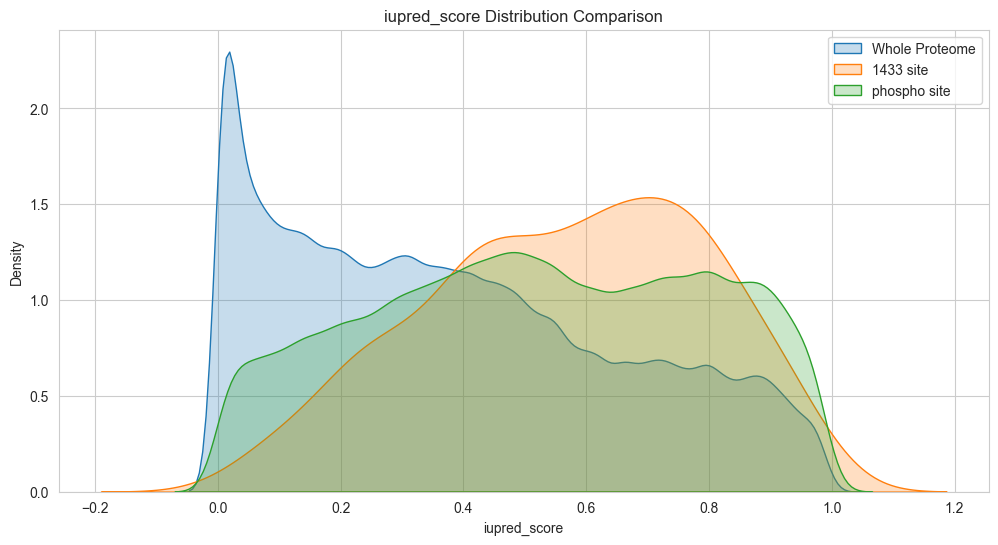

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)


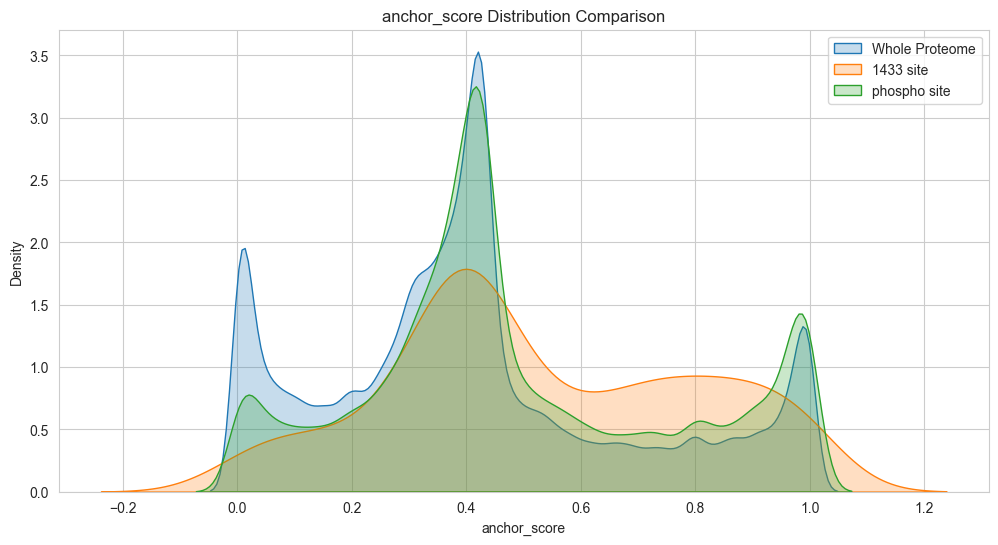

In [64]:
st_idrscore_anchorscore_path = 'data/collected_st_amino_acids_idrscore_anchorscore.csv'
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "iupred_score")
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "anchor_score")

2.2 Analysis of IDR Conformational Properties

Task 16: We used _2023_Tesei_IDRome to extract IDR properties of 14-3-3 binding proteins and compared them with those of all other human IDRs.

Task 17: We found that IDRs with 14-3-3 binding sites have elevated values for Rg/nm, Ree/nm, Rh/nm, Shd, Scd, Kappa, and Qcdpred, reduced values for Nu, Spr, Ete2_rg2, S, Delta, Nu_svr, and Spr_svr, while showing no significant changes in Fcr, Fk, Fr, Fe, Fd, Faro, Mean_lambda, Ncpr, Zdelta, Z_omega, and Fdomain (Figure 2B). Additionally, by comparing the ν values of IDRs containing 14-3-3 binding sites to all human IDRs, we observed that 14-3-3 binding sites are preferentially located in relatively compact IDRs with lower ν values (Figure 2C).

In [65]:
## download the IDRome dataset from
# https://github.com/KULL-Centre/_2023_Tesei_IDRome/blob/main/IDRome_DB.csv

In [66]:
df_1433 = pd.read_csv("data/Table 1.csv")
df_1433
# select positive human sample to see the distribution
df_pos_human = df_1433[(df_1433["label"] == 1)]
df_pos_human

,human homology accession,human homology site without letter,human Site and Mutation,label,PMID
0,P43681,467,S467s,1,20141511
1,P11362,779,S779s,1,23564461
2,P98177,32,T32t,1,20141511
3,P14136,8,S8s,1,20141511
4,P08151,640,S640s,1,20141511
...,...,...,...,...,...
781,Q53ET0,368,S368s,1,18626018
782,Q05086-2,485,T485t,1,28835500
783,P40818,718,S718s/S716A,1,17720156
784,P40818,718,S718s,1,17720156


In [67]:
df_idr = pd.read_csv("data/IDRome_DB.csv")
df_idr

,seq_name,UniProt_ID,N,nu,SPR,ete2_Rg2,S,Delta,Rg/nm,Ree/nm,...,gene_name,QCDpred,z_delta_+-,z_omega_pi,z_omega_+,z_omega_-,z_omega_h,fdomain,nu_svr,SPR_svr
0,A0A024RBG1_145_181,A0A024RBG1,37,0.558,10.284649,6.304027,0.933961,0.225950,1.606561,3.843011,...,NUDT4B,0.254463,0.000000,0.000000,0.000000,0.000000,-0.531910,0.000000,0.565,10.288
1,A0A075B6T7_1_32,A0A075B6T7,32,0.525,10.092351,6.114494,0.901807,0.212670,1.448141,3.390487,...,TRAV6,0.659342,0.000000,0.054230,-0.043142,0.000000,0.061436,0.000000,0.532,10.107
2,A0A087WTH1_1_67,A0A087WTH1,67,0.532,10.160125,6.069995,0.822738,0.199126,2.243991,5.283533,...,TMEM265,0.661272,-1.094918,0.000000,0.384885,2.281943,1.092688,0.298507,0.537,10.167
3,A0A087WTH5_1_132,A0A087WTH5,132,0.496,10.049124,6.150972,0.798438,0.188978,3.034005,7.119714,...,KCNE1B,0.445861,0.000000,-0.463316,0.799692,0.000000,0.627563,0.000000,0.509,10.018
4,A0A087WV53_1_46,A0A087WV53,46,0.567,10.212765,6.439589,0.882210,0.214786,1.882622,4.607908,...,SPEGNB,0.313998,0.000000,0.000000,1.947253,0.000000,0.090132,0.369565,0.578,10.316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28053,Q9Y6Z4_1_181,Q9Y6Z4,181,0.493,10.006512,5.748098,0.799905,0.210890,3.791956,8.607822,...,KIF25-AS1,0.396007,0.000000,0.000000,-1.319891,0.000000,0.163169,0.000000,0.520,9.993
28054,Q9Y6Z5_1_254,Q9Y6Z5,254,0.528,9.830710,6.153759,0.896173,0.221422,4.586832,10.808776,...,AFDN-DT,0.374082,0.000000,0.000000,-2.182869,0.000000,2.214949,0.000000,0.537,9.984
28055,Q9Y6Z7_1_109,Q9Y6Z7,109,0.546,10.025622,6.175505,0.935857,0.216970,3.011145,7.113405,...,COLEC10,0.232155,0.106768,0.000000,0.451957,2.132808,1.114749,0.513761,0.513,10.072
28056,W6CW81_1_113,W6CW81,113,0.519,10.084249,6.191149,0.843169,0.193880,2.943990,6.975229,...,PYDC5,0.310500,0.404828,0.000000,0.554013,2.234693,-1.942090,0.451327,0.512,10.063


In [68]:
df_idr["start_site"] = df_idr["seq_name"].apply(lambda x: int(x.split('_')[1]))
df_idr["end_site"] = df_idr["seq_name"].apply(lambda x: int(x.split('_')[2]))

In [69]:
uniprot_set = set(df_pos_human["human homology accession"])
mask_uniprot = df_idr["UniProt_ID"].isin(uniprot_set)
df_idr_uniprot = df_idr.loc[mask_uniprot]

In [70]:
df_idr_uniprot_position = pd.DataFrame()

In [71]:
for index, row in df_idr_uniprot.iterrows():
    uniprot_id = row["UniProt_ID"]
    start = row["start_site"]
    end = row["end_site"]
    df_filter = df_pos_human[df_pos_human["human homology accession"] == uniprot_id]
    for i, r in df_filter.iterrows():
        position = int(r["human homology site without letter"])
        if position >= start and position <= end:
            df_tmp = row.to_frame().T
            df_tmp["position"] = position
            # print(df_tmp.columns)
            if len(df_idr_uniprot_position)<1:
                df_idr_uniprot_position = df_tmp
            else:
                df_idr_uniprot_position = pd.concat([df_idr_uniprot_position, df_tmp], join="inner", axis=0, ignore_index=True)

df_idr_uniprot_position = df_idr_uniprot_position.drop_duplicates()
df_idr_uniprot_position.head(2)

,seq_name,UniProt_ID,N,nu,SPR,ete2_Rg2,S,Delta,Rg/nm,Ree/nm,...,z_omega_pi,z_omega_+,z_omega_-,z_omega_h,fdomain,nu_svr,SPR_svr,start_site,end_site,position
0,A0AVK6_339_867,A0AVK6,529,0.523,9.947836,6.01185,0.998467,0.224419,7.182813,16.68367,...,0.0,0.0,0.0,1.683024,0.0,0.51,9.963,339,867,396
1,A2RUS2_428_518,A2RUS2,91,0.515,10.144514,5.862947,0.917746,0.218117,2.674128,6.14078,...,0.0,0.247884,0.0,1.322073,0.0,0.523,10.115,428,518,472


In [72]:
feature = df_idr_uniprot_position.columns
feature = feature.drop(['seq_name', 'UniProt_ID', 'start_site', 'end_site', 'position','N',"fasta", "is_btw_folded", "is_nterm",	"is_cterm",	"is_idp", "first", "last",	"N_FL",	"protein_name",	"gene_name"])

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot(column):
    bins=20
    df1_name = "1433_core"
    df2_name = "Whole Human IDR"
    df1 = df_idr_uniprot_position
    df2 = df_idr

    # Set the style for the plot
    # plt.style.use('seaborn')
    
    # Create the figure and axis objects
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot the histograms
    sns.histplot(data=df1, x=column, bins=bins, alpha=0.6, label=df1_name, kde=False, ax=ax, stat='density', color='#FFA07A',)
    sns.histplot(data=df2, x=column, bins=bins, alpha=0.6, label=df2_name, kde=False, ax=ax, stat='density', color='#4682B4')
    
    # Customize the plot
    ax.set_xlabel(column.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribution of {column.capitalize()} in {df1_name} and {df2_name}', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    
    # Add a grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Customize the tick labels
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Add a text box with summary statistics
    stats_text = f"Summary Statistics:\n\n{df1_name}:\nMean: {df1[column].mean():.2f}\nMedian: {df1[column].median():.2f}\n\n{df2_name}:\nMean: {df2[column].mean():.2f}\nMedian: {df2[column].median():.2f}"
    plt.text(0.2, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()

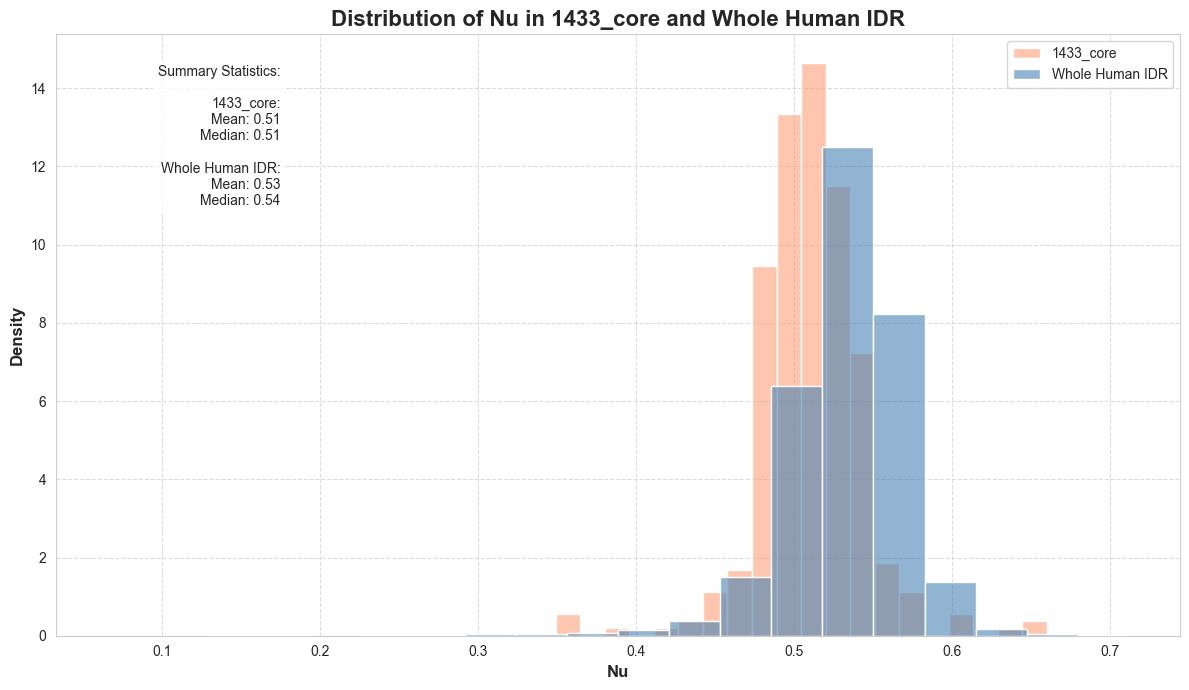

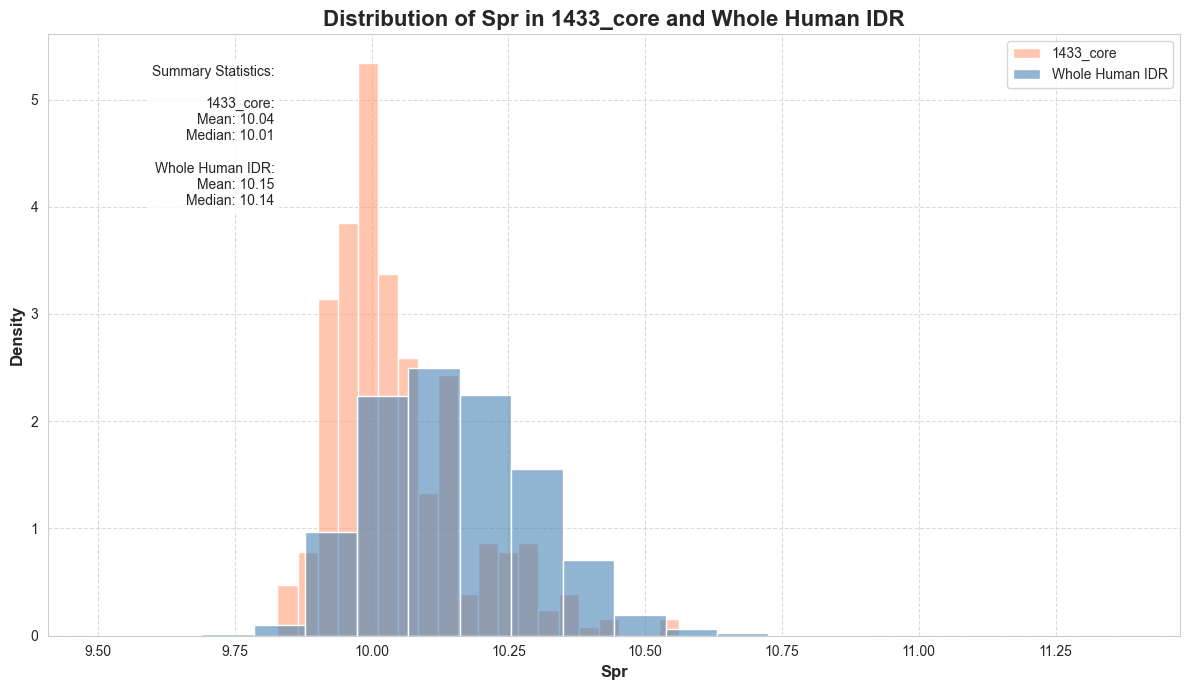

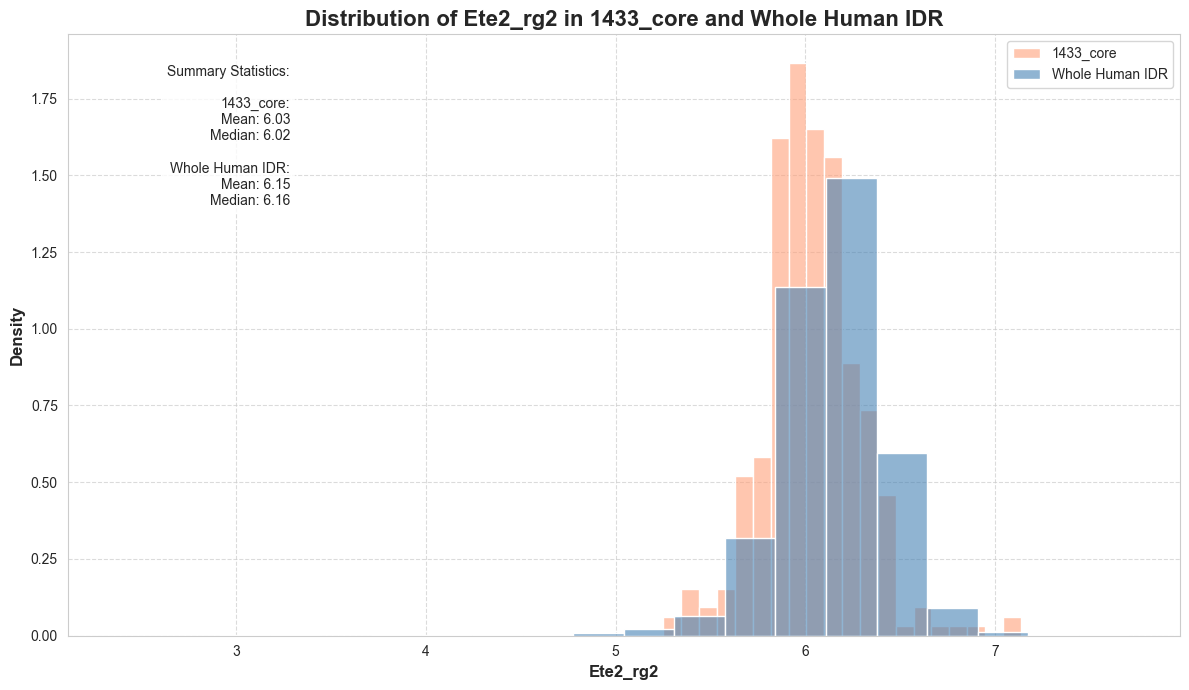

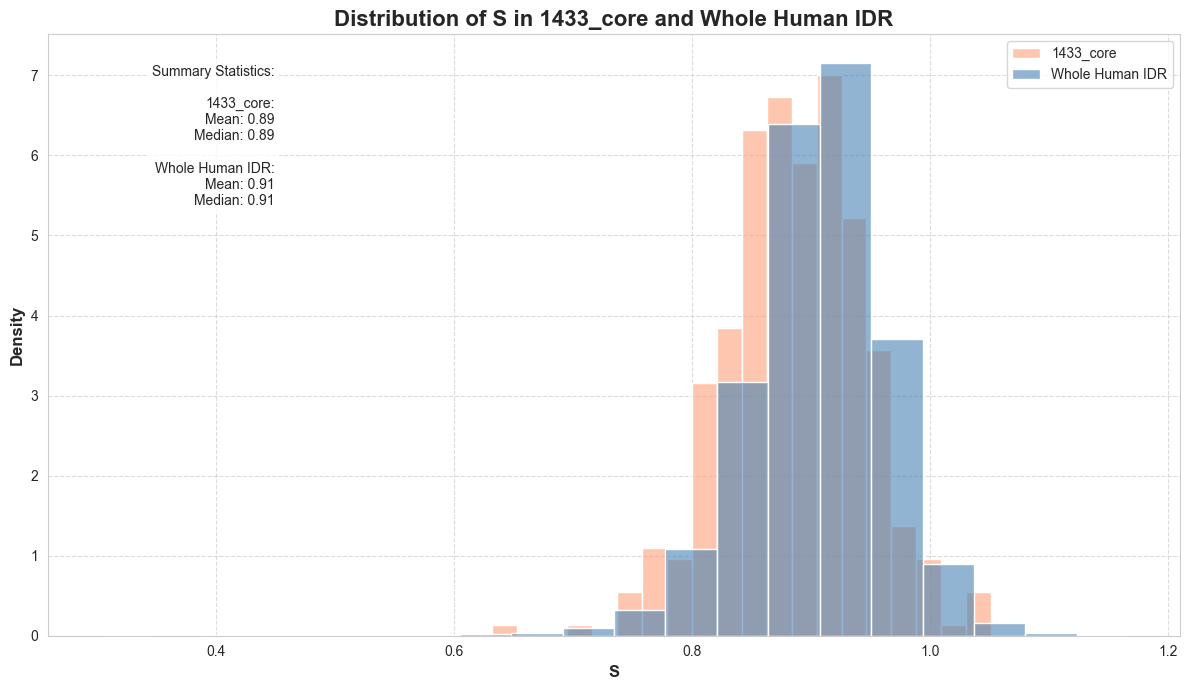

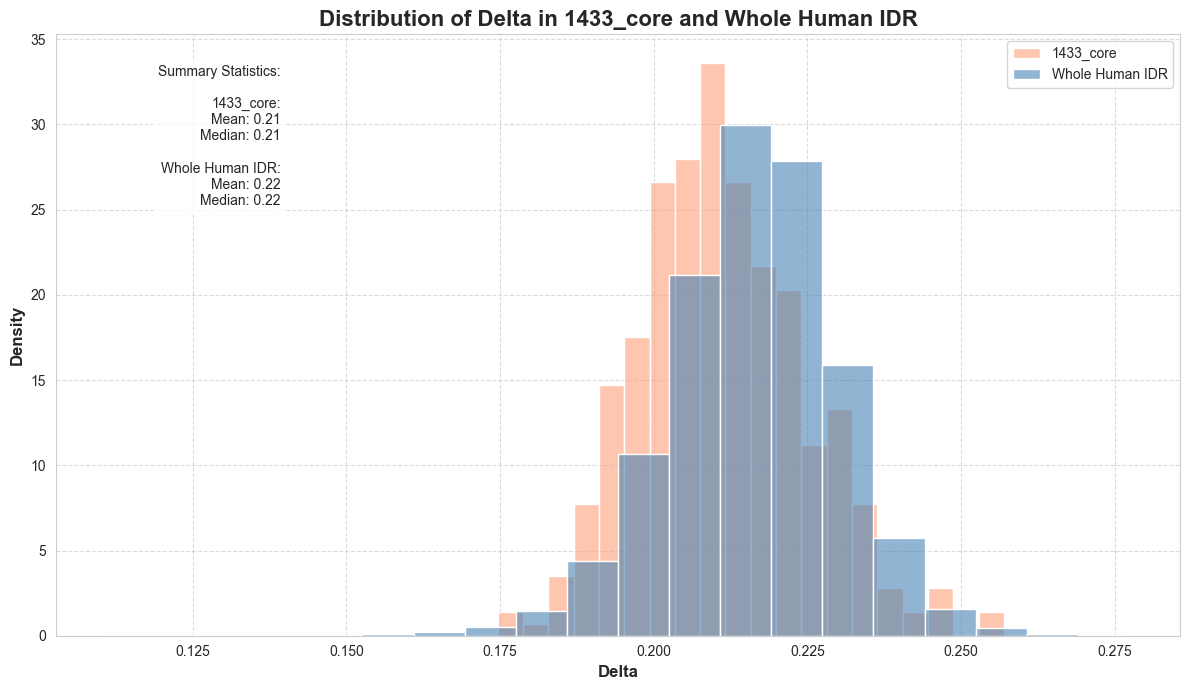

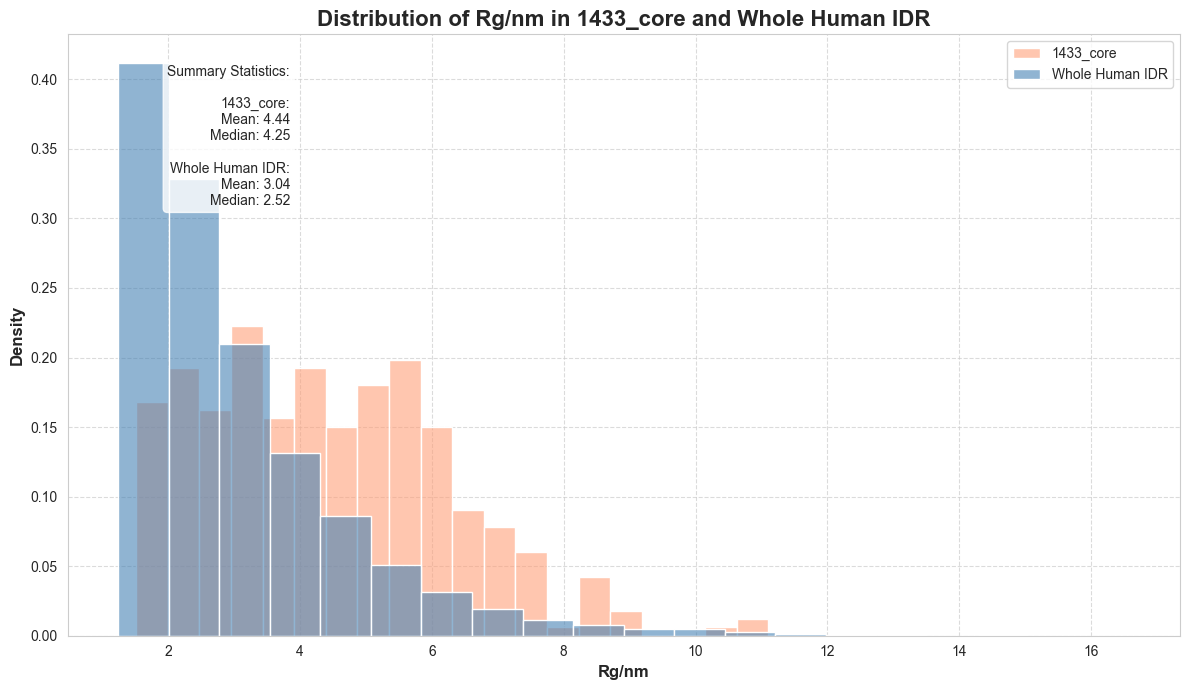

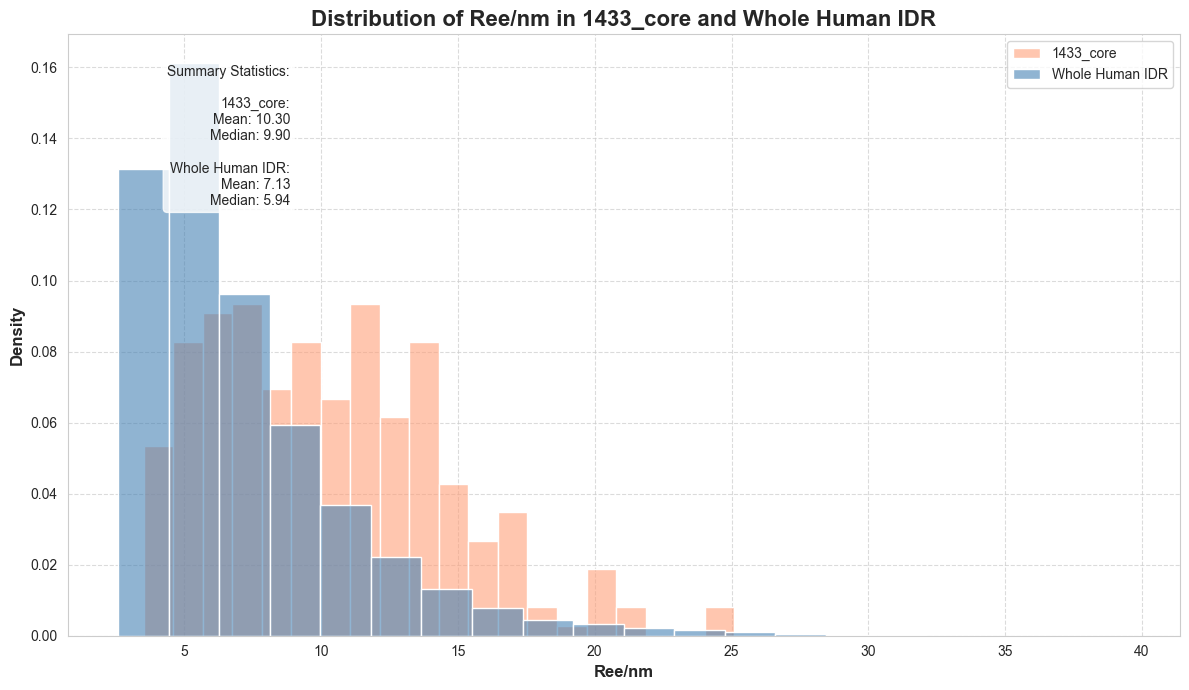

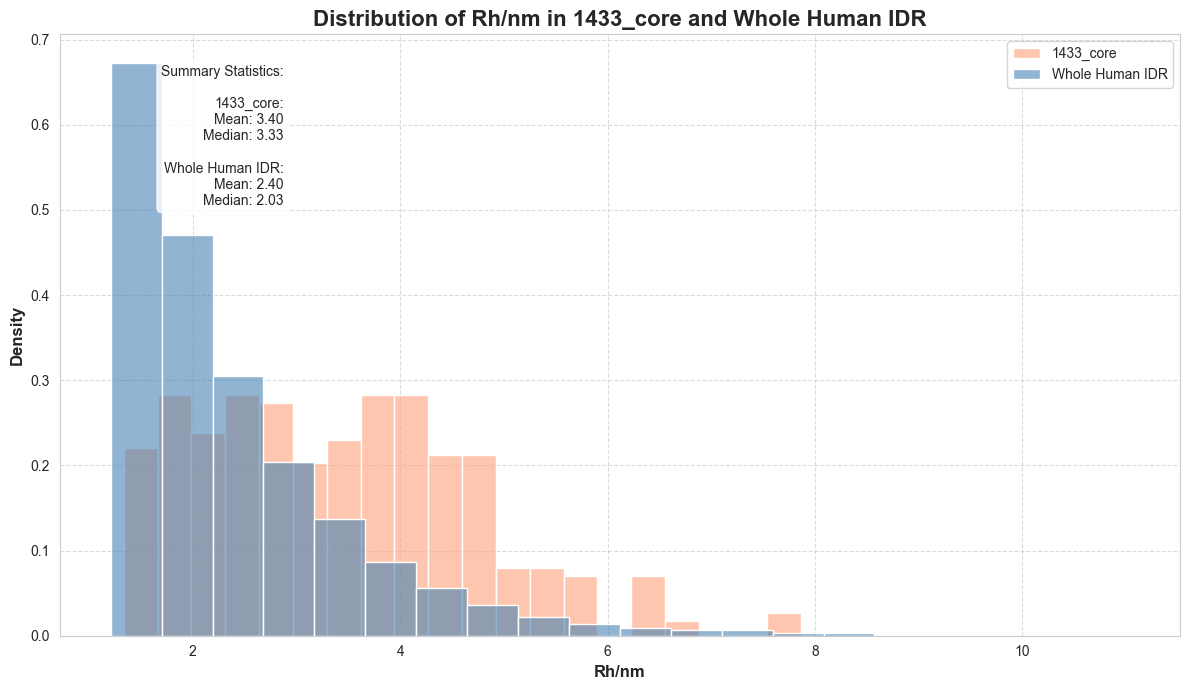

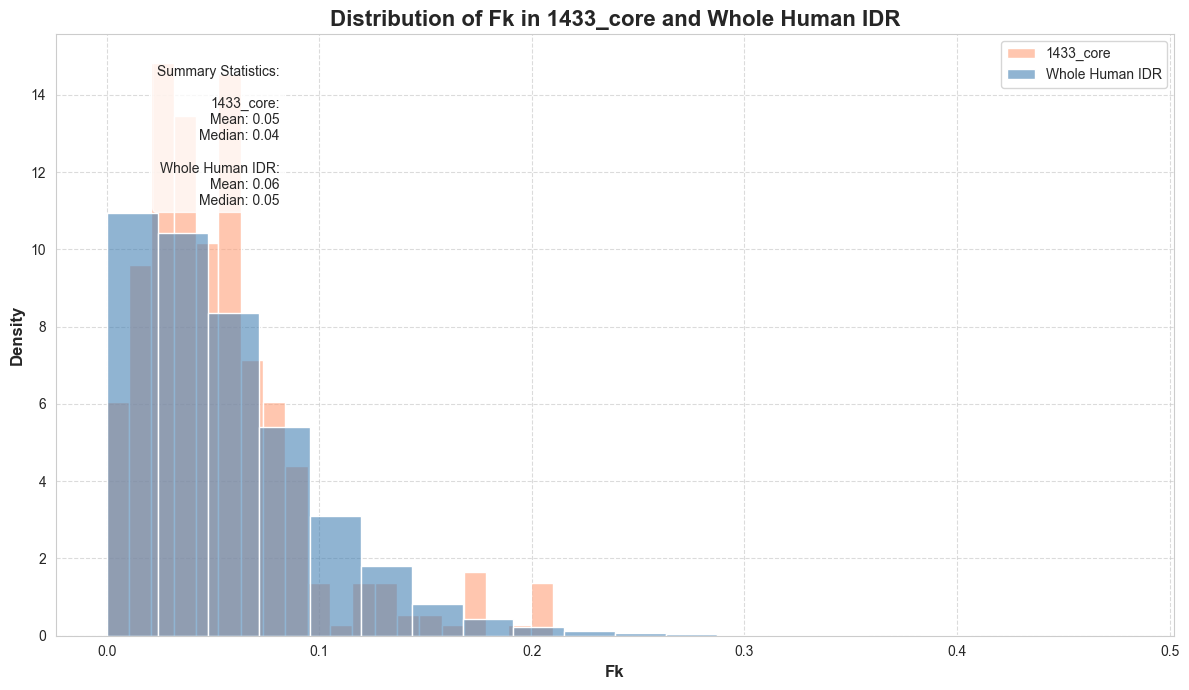

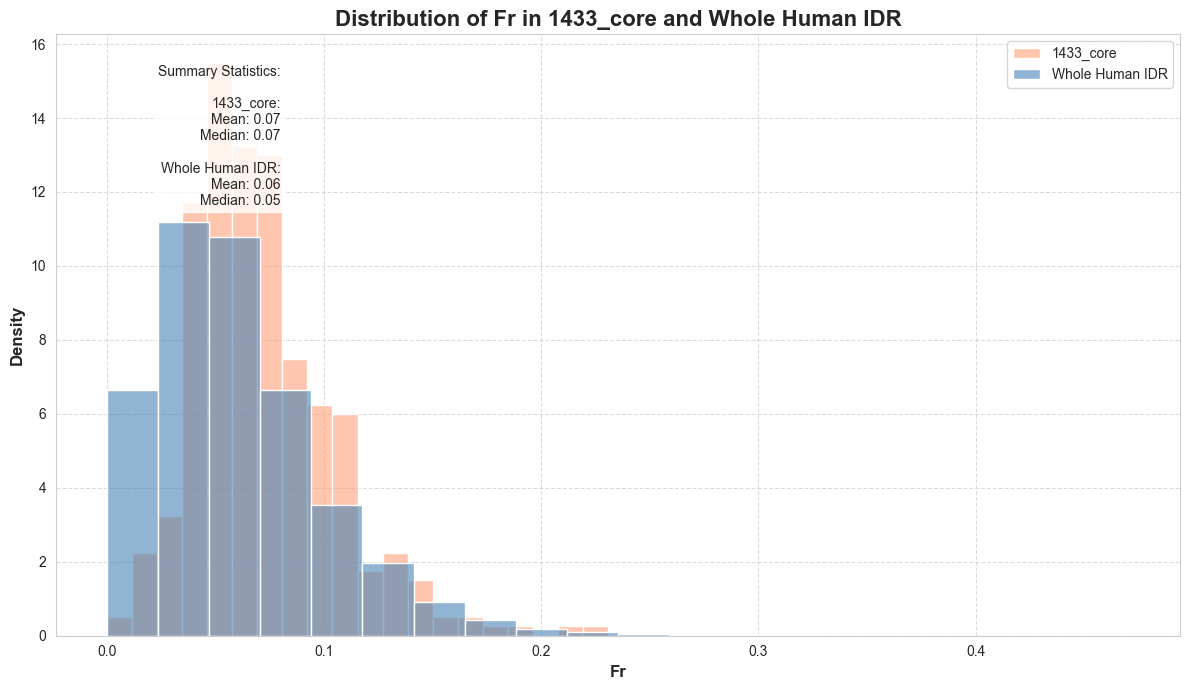

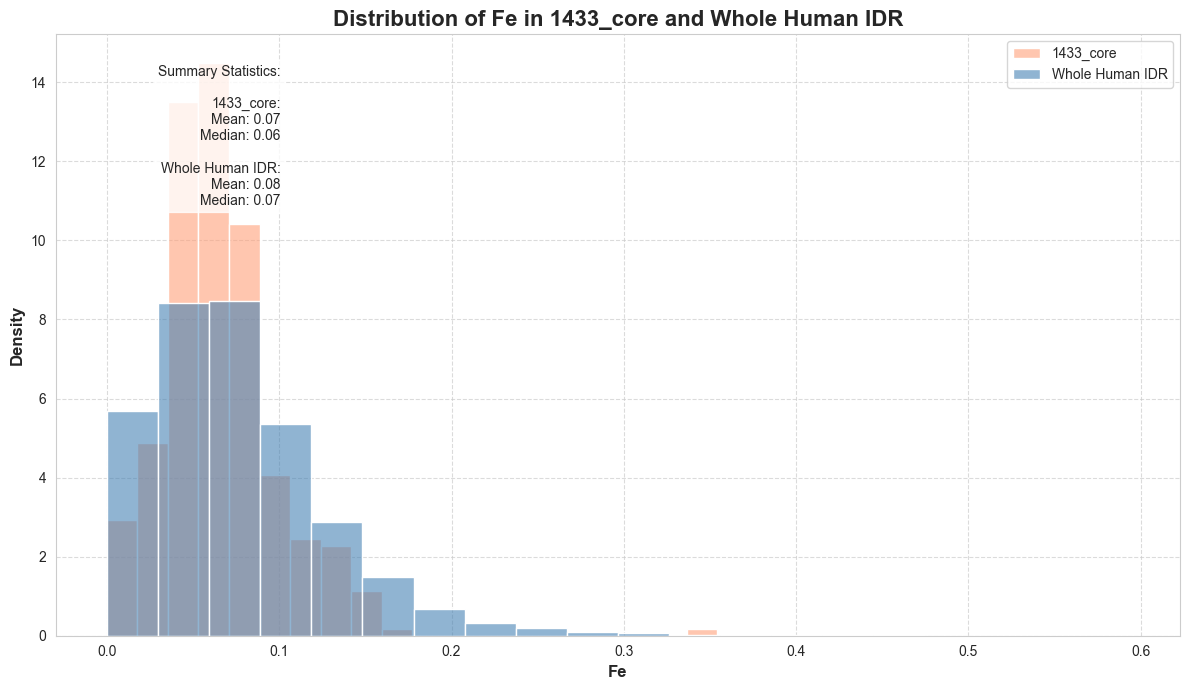

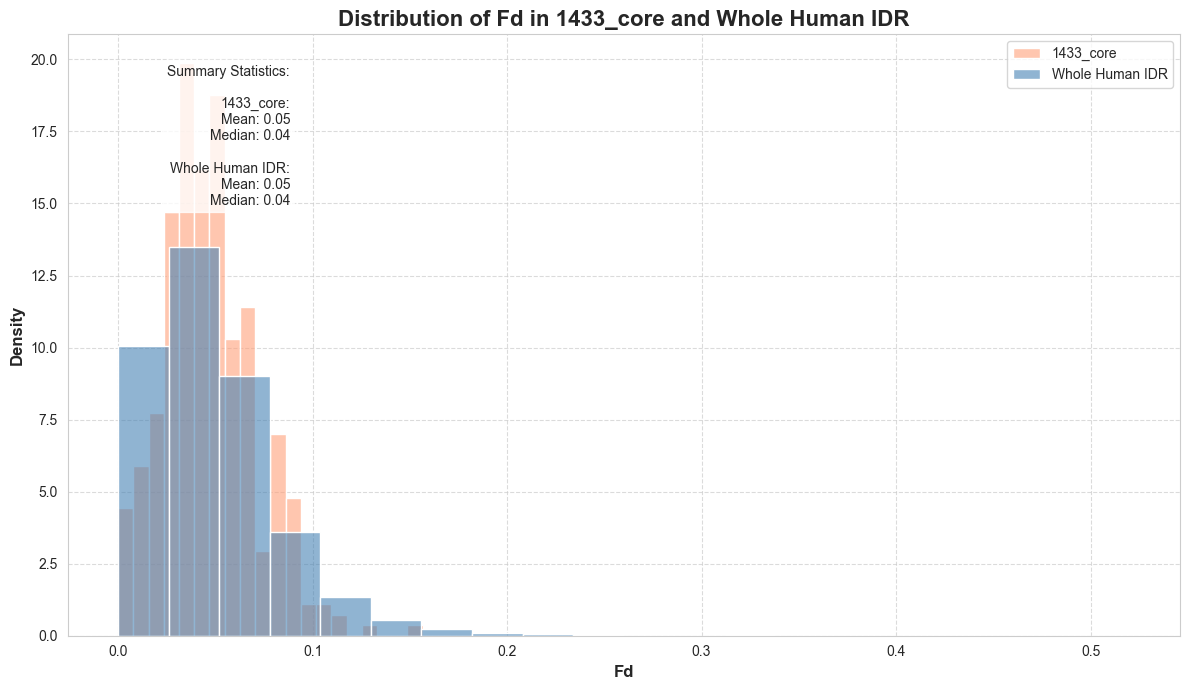

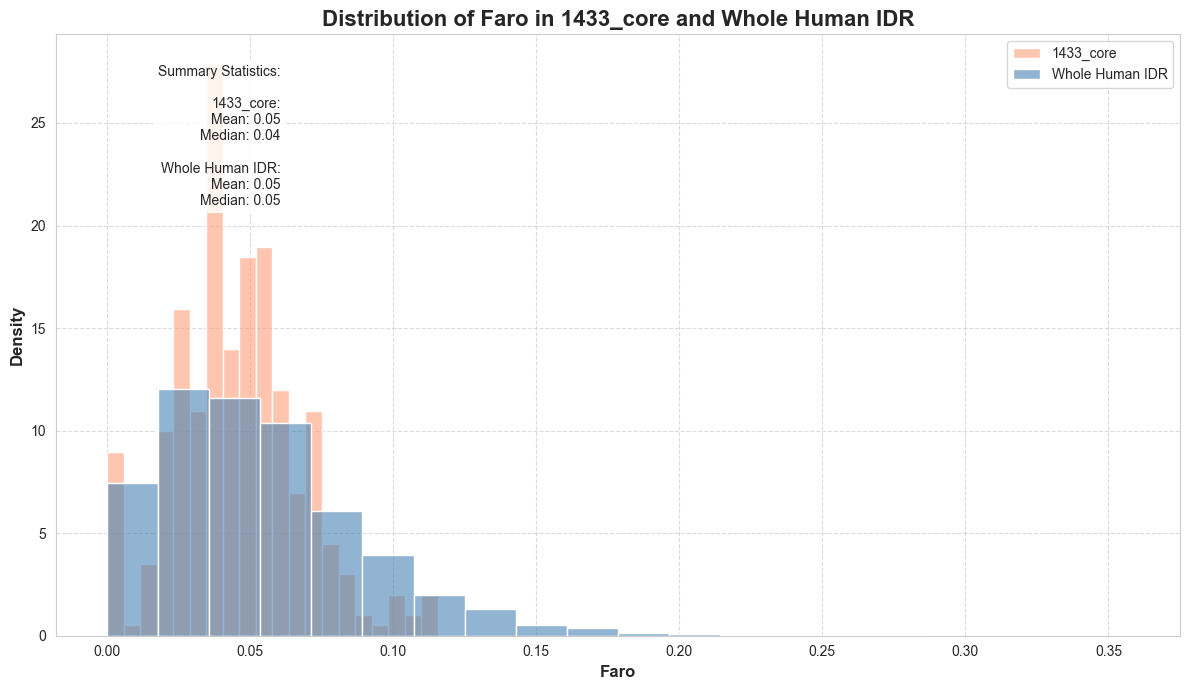

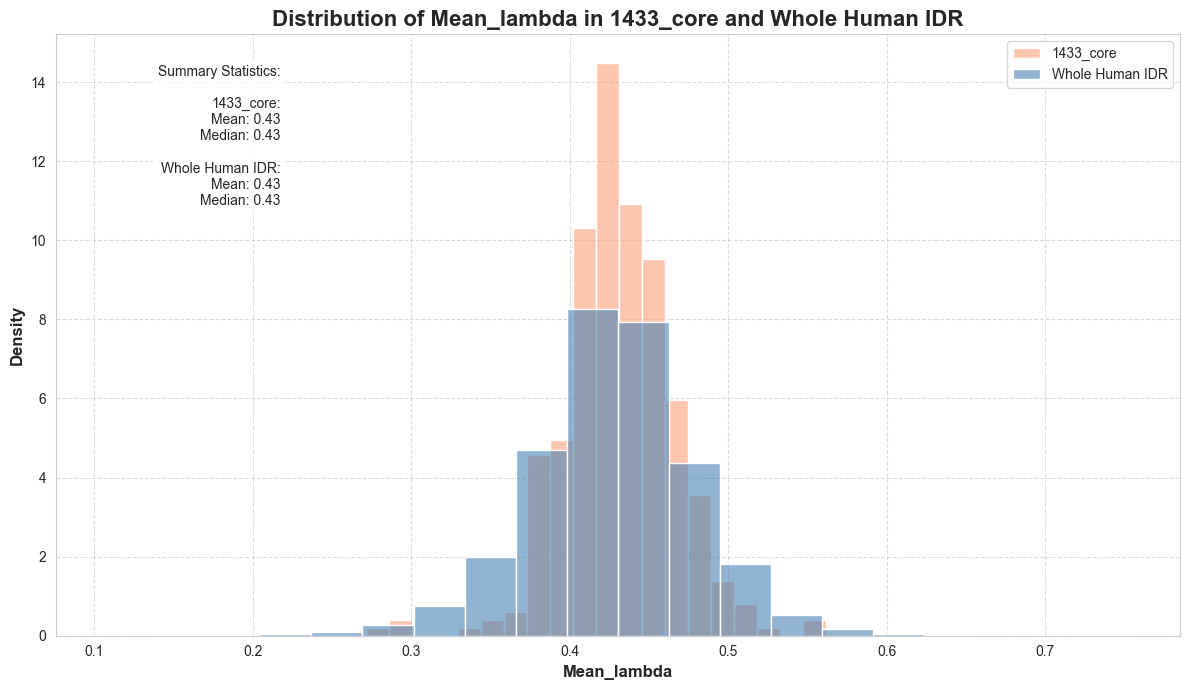

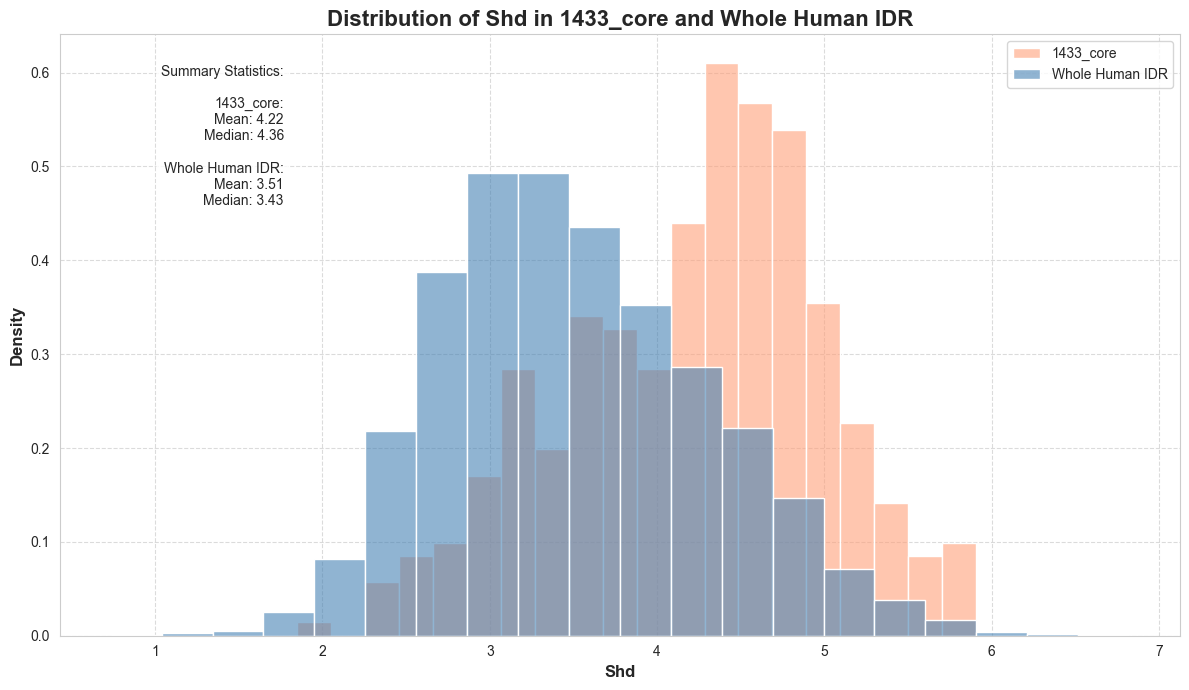

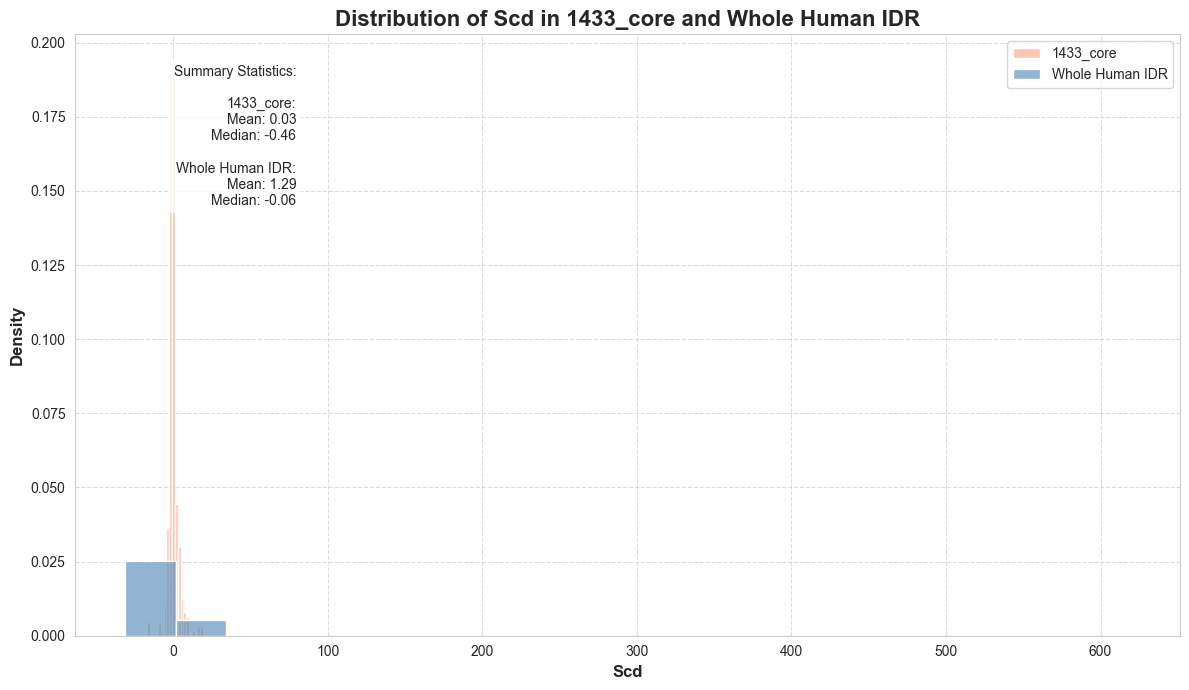

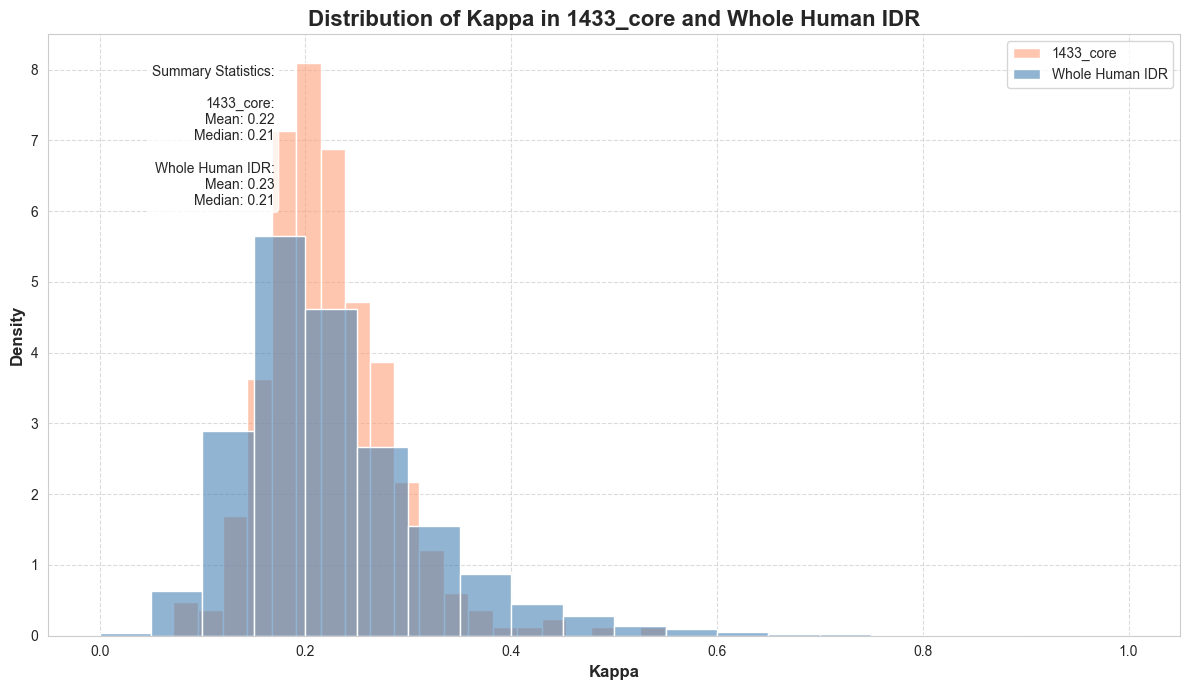

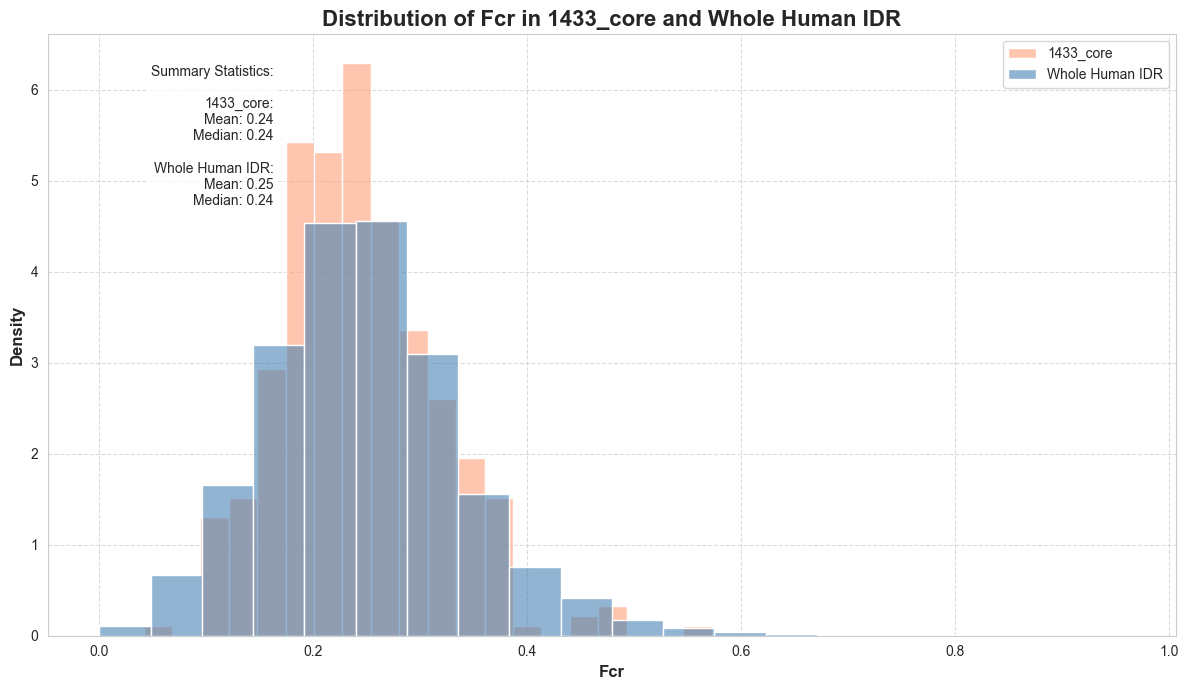

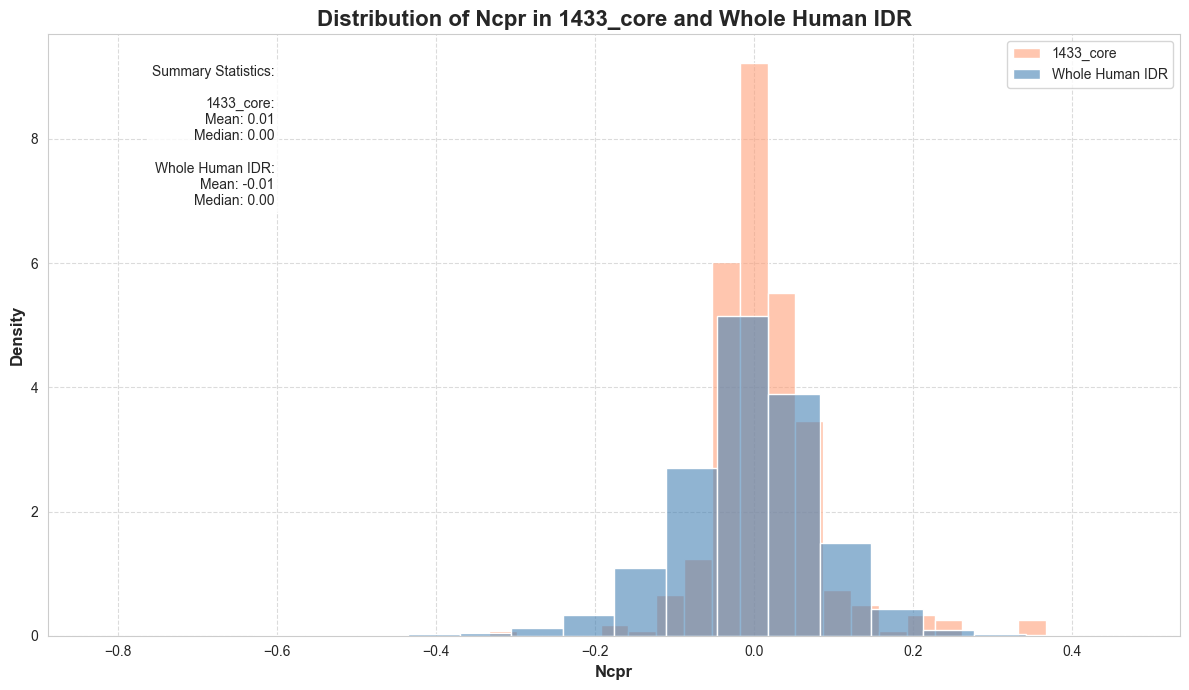

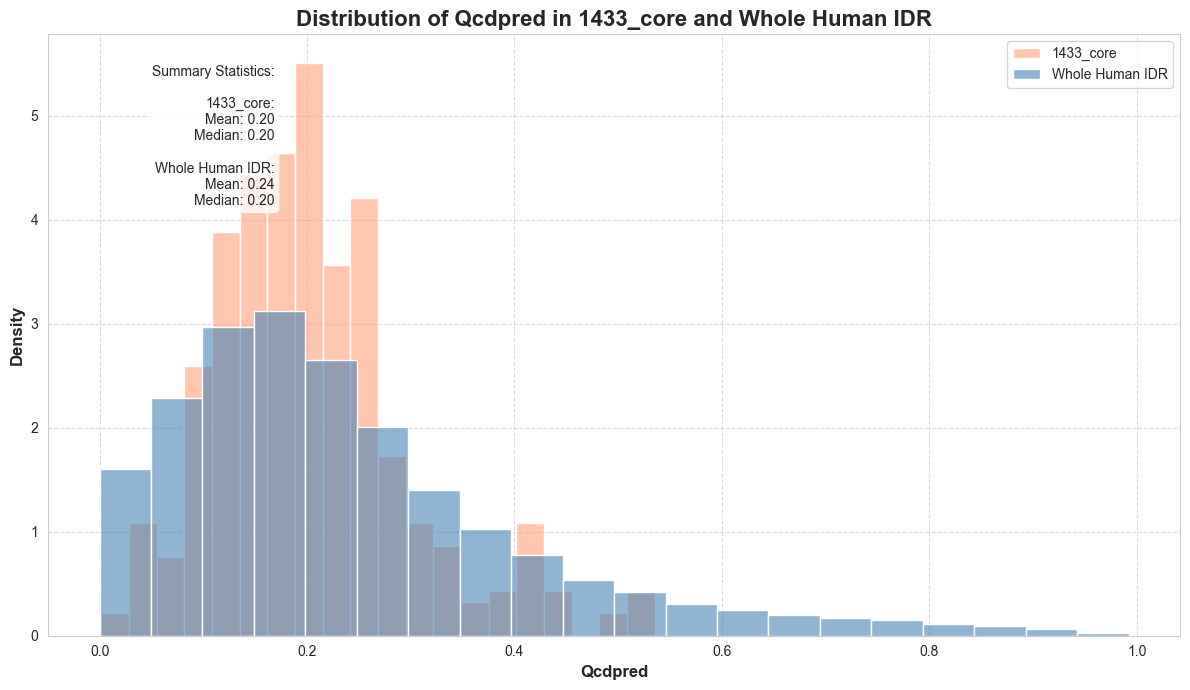

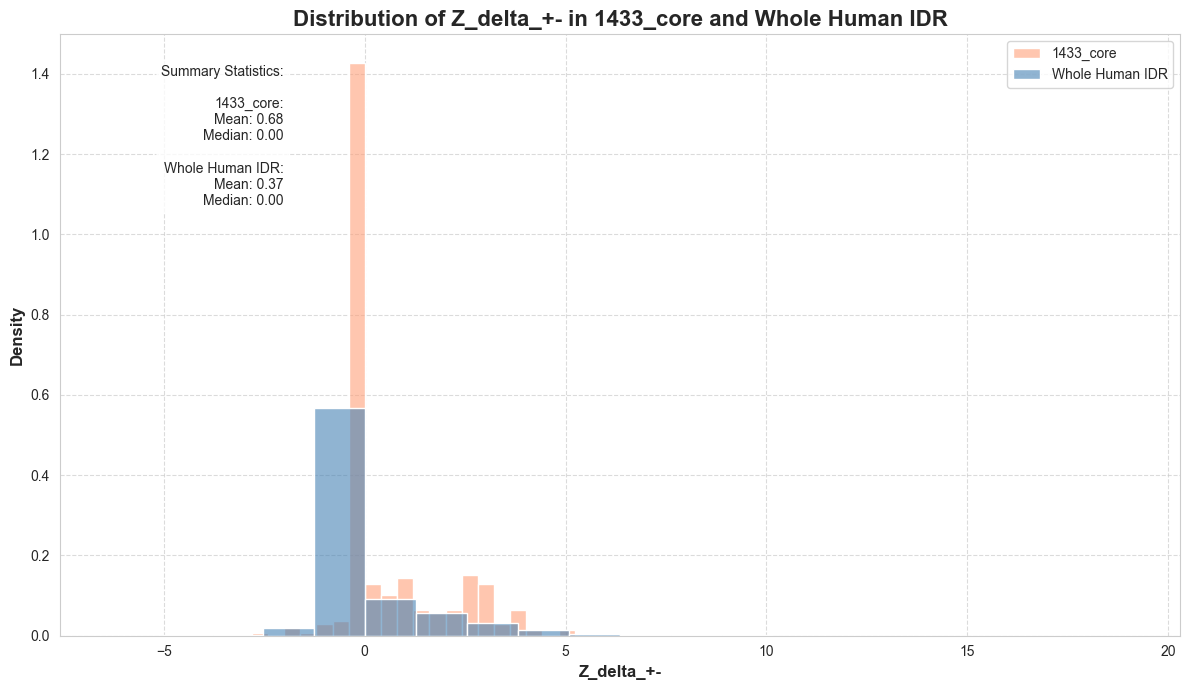

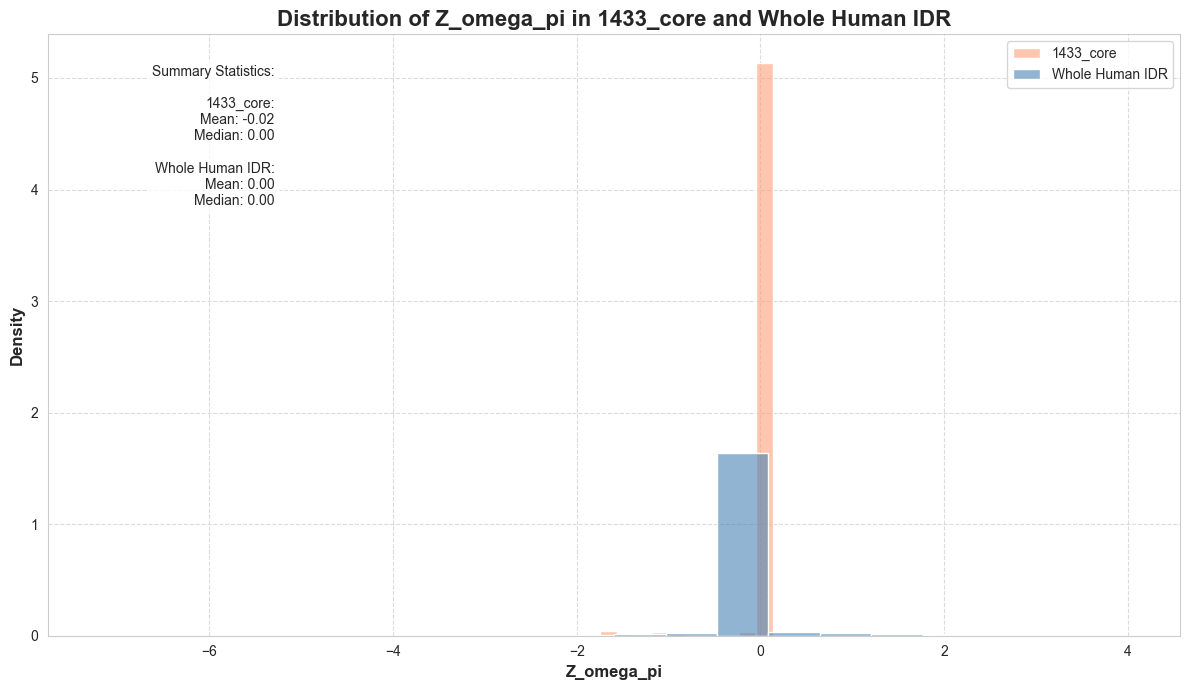

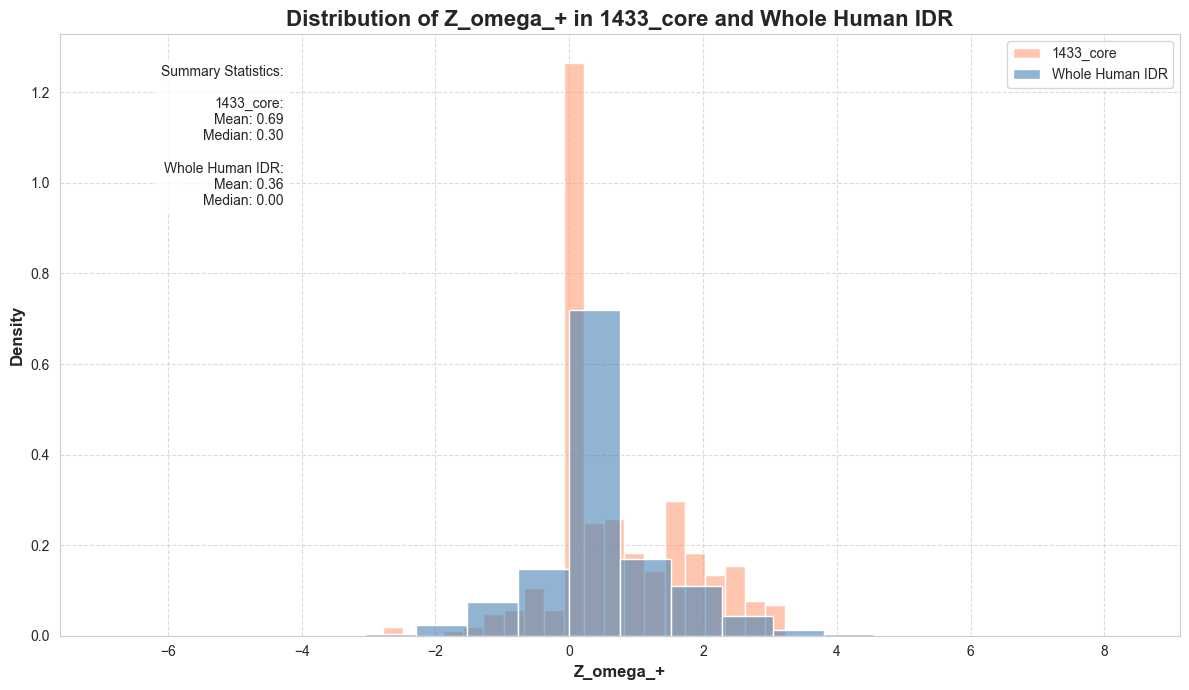

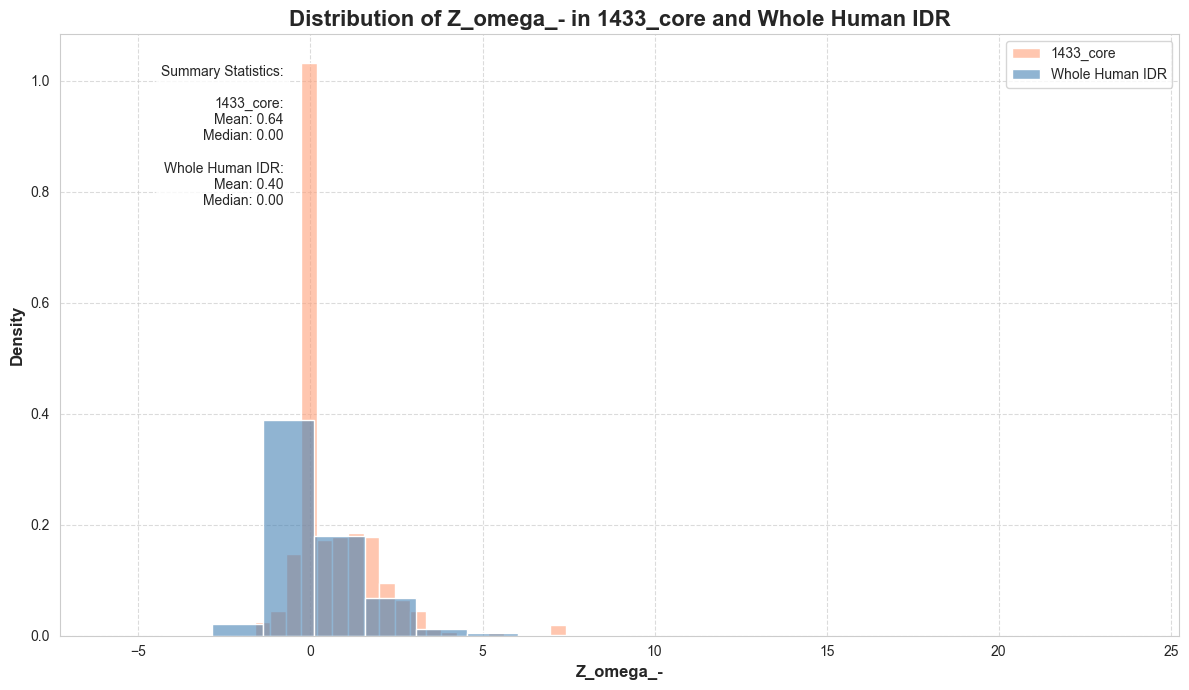

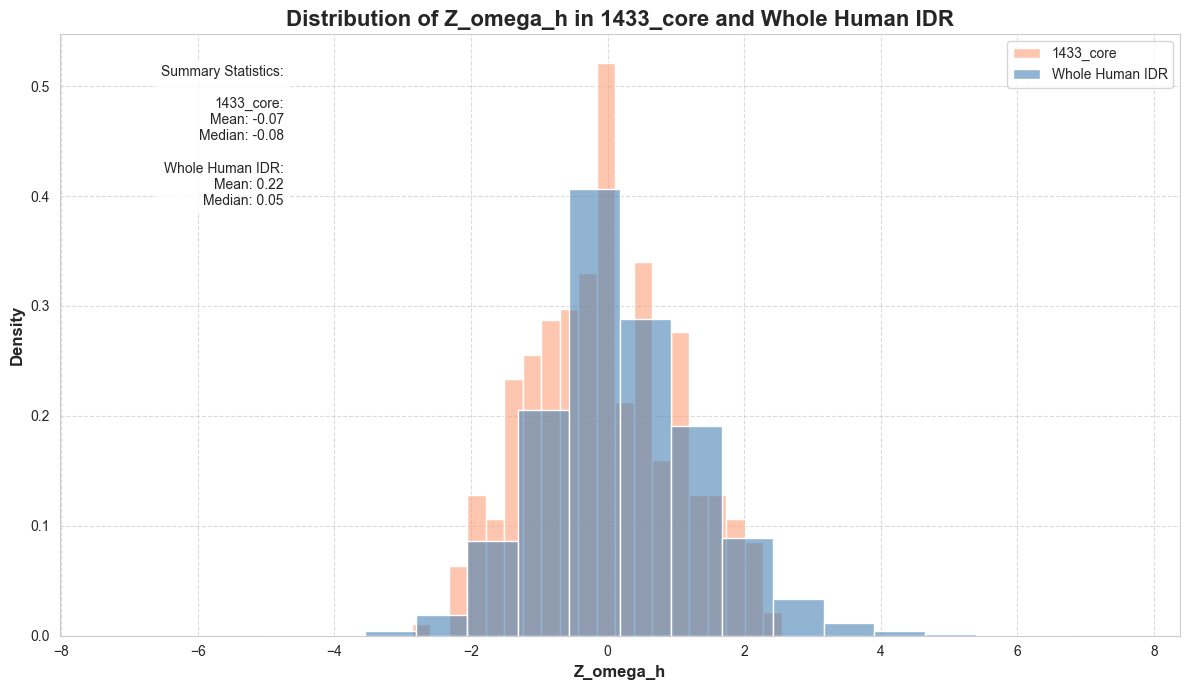

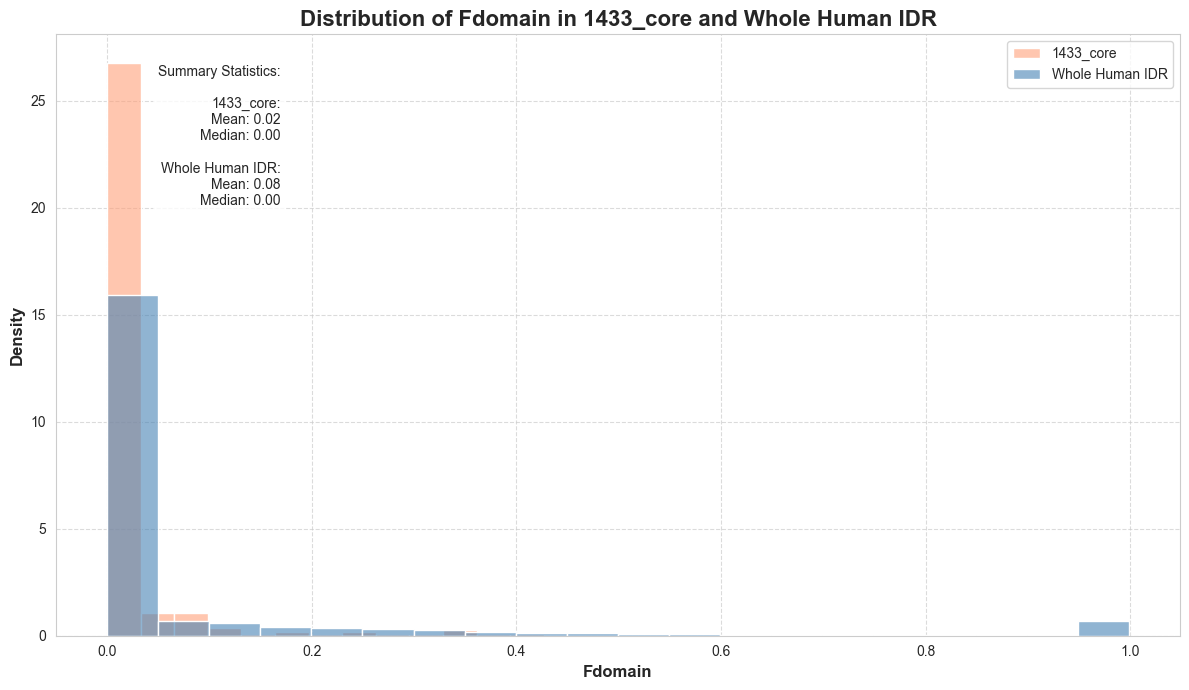

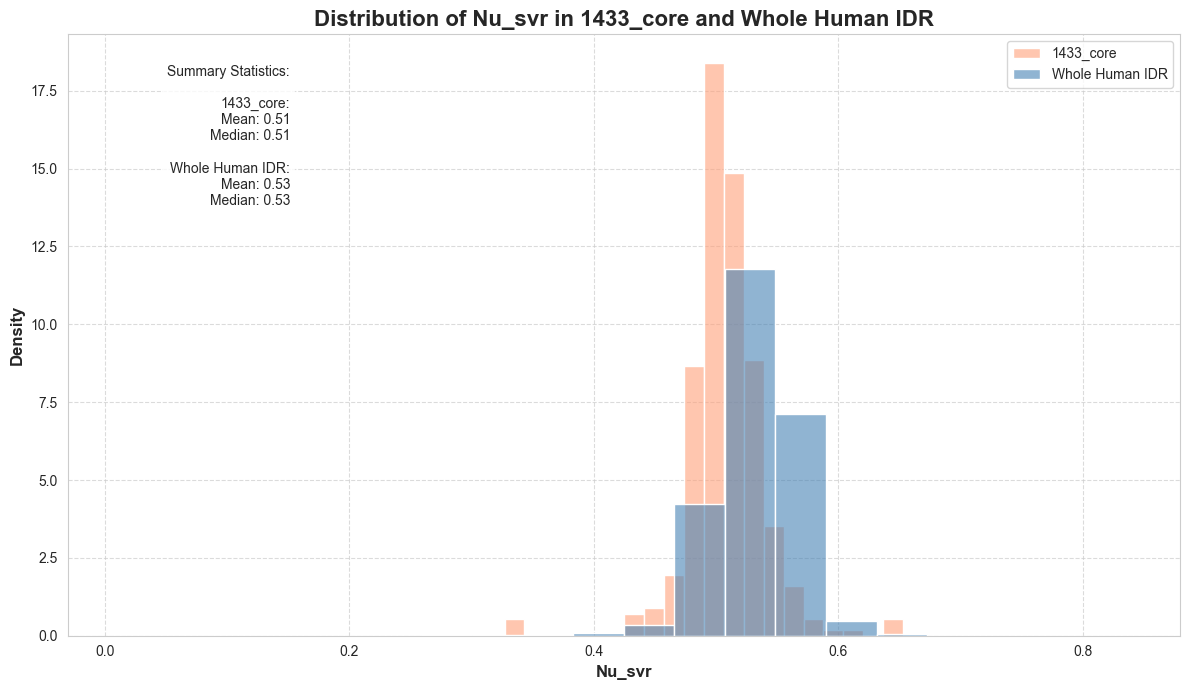

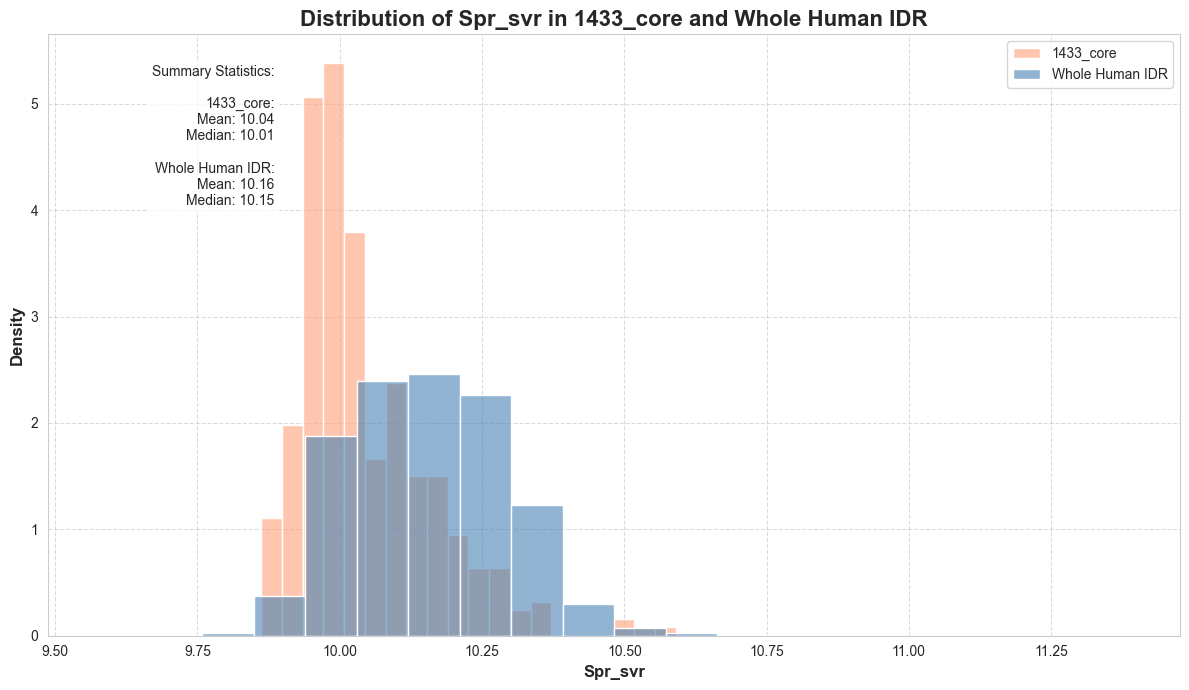

In [74]:
for column in feature:
    plot(column)

In [75]:
from scipy.stats import ks_2samp

def ks_test(column):
    # Perform Kolmogorov-Smirnov test
    statistic, p_value = ks_2samp(df_idr_uniprot_position[column], df_idr[column])
    
    # Interpret the result
    alpha = 0.05  # significance level
    print(f"KS statistic: {statistic}")
    print(f"P-value: {p_value}")
    if p_value < alpha:
        pass
        print(f"The distributions are significantly different in column: {column}.")
    else:
        # pass
        print(f"No significant difference found between the distributions in column: {column}.")

for column in feature:
    ks_test(column)

KS statistic: 0.35928612674075905
P-value: 3.755346268935822e-40
The distributions are significantly different in column: nu.
KS statistic: 0.3715762306280752
P-value: 5.227346493638127e-43
The distributions are significantly different in column: SPR.
KS statistic: 0.2642712306722407
P-value: 1.2427706717329634e-21
The distributions are significantly different in column: ete2_Rg2.
KS statistic: 0.17860378963871254
P-value: 4.81848643534812e-10
The distributions are significantly different in column: S.
KS statistic: 0.22267378215935174
P-value: 2.022772028683541e-15
The distributions are significantly different in column: Delta.
KS statistic: 0.3696004961316236
P-value: 1.5305922722539592e-42
The distributions are significantly different in column: Rg/nm.
KS statistic: 0.37316957483910945
P-value: 2.187416460694046e-43
The distributions are significantly different in column: Ree/nm.
KS statistic: 0.37277249698699455
P-value: 2.718902795075907e-43
The distributions are significantly dif

# 3	Higher-Order Features Revealed Through Domain and Motif Analysis

task 22: ANCHOR2 for prediction compare 14-3-3 binding site with whole human protemo through IUPred2A web

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[columnname], label='Whole Proteome', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_1433_df[columnname], label='1433 site', shade=True)
/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/779504648.py:22: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(filtered_known_phospho_df[columnname], label='phospho site', shade=True)


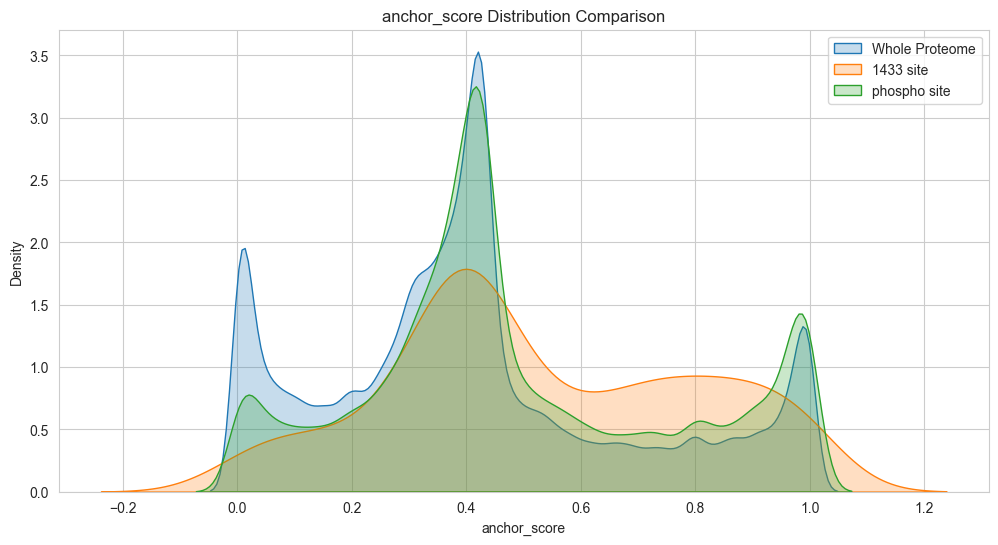

In [76]:
compare_protein_feature_distribution(konwn_1433_site, konwn_human_phosphorylated_site, st_idrscore_anchorscore_path, "anchor_score")

Task 23: We analyzed the sequence composition of 14-3-3 binding sites using windows of various lengths. A window size of 51 (n=25) was used to maximize the prediction performance of the aforementioned PTM sites. Based on the curated dataset, a graphical sequence logo was generated using Two Sample Logo, with statistical significance determined by a t-test (P < 0.05).

In [77]:
# iterate through the protein in uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta
# for all the s and t site, get the window size sequence of 51, means get the -25 to 25 sequence centered with s or t
# name each site by uniprotid_Center amino acid(S OR T)_position of centered S or T
# if the there is not enough sequence in the flank, for example S at position 2 will not have 25 amino acid in the left flank, use "_" to fill the gap
# save the results in a dataframe, then save it into a dataframe


from Bio import SeqIO
import pandas as pd

def extract_window_sequences(fasta_file, window_size=51):
    half_window = window_size // 2
    results = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        uniprot_id = record.id.split('|')[1] if '|' in record.id else record.id
        sequence = str(record.seq)
        for i, aa in enumerate(sequence):
            if aa in ('S', 'T'):
                start = max(0, i - half_window)
                end = min(len(sequence), i + half_window + 1)
                
                window_seq = sequence[start:end]
                
                if len(window_seq) < window_size:
                    left_gap = "_" * (half_window - max(0, i))
                    right_gap = "_" * (half_window - (len(sequence) - 1 - i))
                    window_seq = left_gap + window_seq + right_gap
                
                site_name = f"{uniprot_id}_{aa}_{i+1}"
                results.append([site_name, window_seq])

    return results

def save_to_dataframe(file_path, data):
    df = pd.DataFrame(data, columns=["Site_Name", "Window_Sequence"])
    df.to_csv(file_path, index=False)
    return df

# Path to the input FASTA file and output CSV file
fasta_file = "data/uniprotkb_reviewed_true_AND_model_organ_2024_12_23.fasta"
output_csv_file = "data/protein_sites_51_window.csv"

# Extract window sequences and save to DataFrame
extracted_data = extract_window_sequences(fasta_file, window_size=51)
df = save_to_dataframe(output_csv_file, extracted_data)

print("Data saved to:", output_csv_file)

Data saved to: data/protein_sites_51_window.csv


In [78]:
df.shape

(1573681, 2)

In [79]:
# use Two Sample Logo to analysis the sequence

In [80]:
# get the 14-3-3 binding positve and negative list and dataset
# preprocess the collected 14-3-3 site into a uniprot_aminoacid_postion index

def process_string(value):
    # Split the value by '/' to handle scenarios with multiple modifications
    parts = value.split('/')
    for part in parts:
        # Check if the first and last characters of the part match the criteria
        if part[0].isupper() and part[-1].islower() and part[0].upper() == part[-1].upper():
            return f"{part[0].upper()}_{part[1:-1]}"
    
    # If none of the parts match the criteria, return None or handle accordingly
    return None


def collect_1433_sites(df, label):
    """
    Collects 14-3-3 dataset entries from the provided DataFrame. Each row in the returned DataFrame is 
    named using the format ACC_ID with amino acid and position.
    
    Parameters:
    df (pd.DataFrame): Input DataFrame with the protein modification data.
    
    Returns:
    pd.DataFrame: Filtered and indexed DataFrame.
    """
    
    # Filter the DataFrame for human datasets
    filtered_df = df[df['label'] == label]

    # Process the MOD_RSD values
    filtered_df['human Site and Mutation'] = filtered_df['human Site and Mutation'].apply(process_string)

    # Set the index using the format ACC_ID_MOD_RSD
    filtered_df.index = filtered_df.apply(lambda row: f"{row['human homology accession']}_{row['human Site and Mutation']}", axis=1)

    return filtered_df.index

phosphodata_path = "data/Table 1.csv"

df = pd.read_csv(phosphodata_path)

# Apply the function
filtered_1433_positive_set = set(collect_1433_sites(df, 1))
filtered_1433_negative_set = set(collect_1433_sites(df, 0))
 
print(len(filtered_1433_positive_set))
print(len(filtered_1433_negative_set))


427
480


/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/22551805.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['human Site and Mutation'] = filtered_df['human Site and Mutation'].apply(process_string)


In [81]:
# save the postive and negative dataset
df_protein_sites_51_window = pd.read_csv("data/protein_sites_51_window.csv")

df_1433_positive_51_window = df_protein_sites_51_window[df_protein_sites_51_window["Site_Name"].isin(filtered_1433_positive_set)]
df_1433_negative_51_window = df_protein_sites_51_window[df_protein_sites_51_window["Site_Name"].isin(filtered_1433_negative_set)]

In [82]:
df_1433_positive_51_window.to_csv("data/1433_positive_51_window.csv")
df_1433_negative_51_window.to_csv("data/1433_negative_51_window.csv")

In [83]:
df_1433_positive_51_window.head(2)

,Site_Name,Window_Sequence
526,A0AVK6_S_396,RRSSKENCAKNLFSTRGKPNFTRHPSLIKLVKSIESDRRKINSAPS...
12464,A7KAX9_S_1796,SQYDNMTPAVQDDLGGIYVIHLRSKSDPGKTGLLSVAEGKESRHAA...


In [84]:
# Two Sample Logo 
# http://www.twosamplelogo.org/

In [85]:
# sampling samples from the whole st sequence.
# first read in the fasta file
# remove the duplicated sequence
# check the formate of fasta file
# then sampling n samples, and save it into a fasta file

import random
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord

def read_fasta(file_path):
    """Reads a FASTA file and returns a list of SeqRecord objects."""
    with open(file_path, "r") as file:
        sequences = list(SeqIO.parse(file, "fasta"))
    return sequences

def remove_duplicates(sequences):
    """Removes duplicate sequences based on their sequence strings."""
    unique_sequences = {}
    for record in sequences:
        if str(record.seq) not in unique_sequences:
            unique_sequences[str(record.seq)] = record
    return list(unique_sequences.values())

def check_fasta_format(sequences):
    """Checks if the sequences are in valid FASTA format."""
    for record in sequences:
        if not isinstance(record, SeqRecord) or not record.seq:
            raise ValueError("Invalid FASTA format")

def sample_sequences(sequences, n):
    """Randomly samples n sequences from the list of unique sequences."""
    if n > len(sequences):
        raise ValueError("Sample size n is larger than the number of unique sequences")
    return random.sample(sequences, n)

def save_fasta(sequences, output_path):
    """Saves the sampled sequences into a new FASTA file."""
    with open(output_path, "w") as output_file:
        SeqIO.write(sequences, output_file, "fasta")

def main(input_fasta, output_fasta, sample_size):
    # Read in the FASTA file
    sequences = read_fasta(input_fasta)
    
    # Remove duplicated sequences
    unique_sequences = remove_duplicates(sequences)
    
    # Check the format of FASTA file
    check_fasta_format(unique_sequences)
    
    # Sample n sequences
    sampled_sequences = sample_sequences(unique_sequences, sample_size)
    
    # Save the sampled sequences into a FASTA file
    save_fasta(sampled_sequences, output_fasta)

# Example usage
input_fasta = "data/all_protein_sites_51_window_25_25.fasta"
sample_size = 100000
output_fasta = f"data/all_protein_sites_51_window_25_25_sample_{sample_size}.fasta"


main(input_fasta, output_fasta, sample_size)

In [86]:
# get the phosphorylation protein_sites_51_window_25_25
df_all_st = pd.read_csv("data/protein_sites_51_window.csv")
df_phosphorylated_site = pd.read_csv("data/konwn_human_phosphorylated_site_from_phosphosite.csv")
phosphorylated_site_dict = set(df_phosphorylated_site["Unnamed: 0"])
df_phosphorylated_site_windows_51_seq = df_all_st[df_all_st["Site_Name"].isin(phosphorylated_site_dict)]
df_phosphorylated_site_windows_51_seq.to_csv("data/all_phosphorylation_sites_51_window.csv")

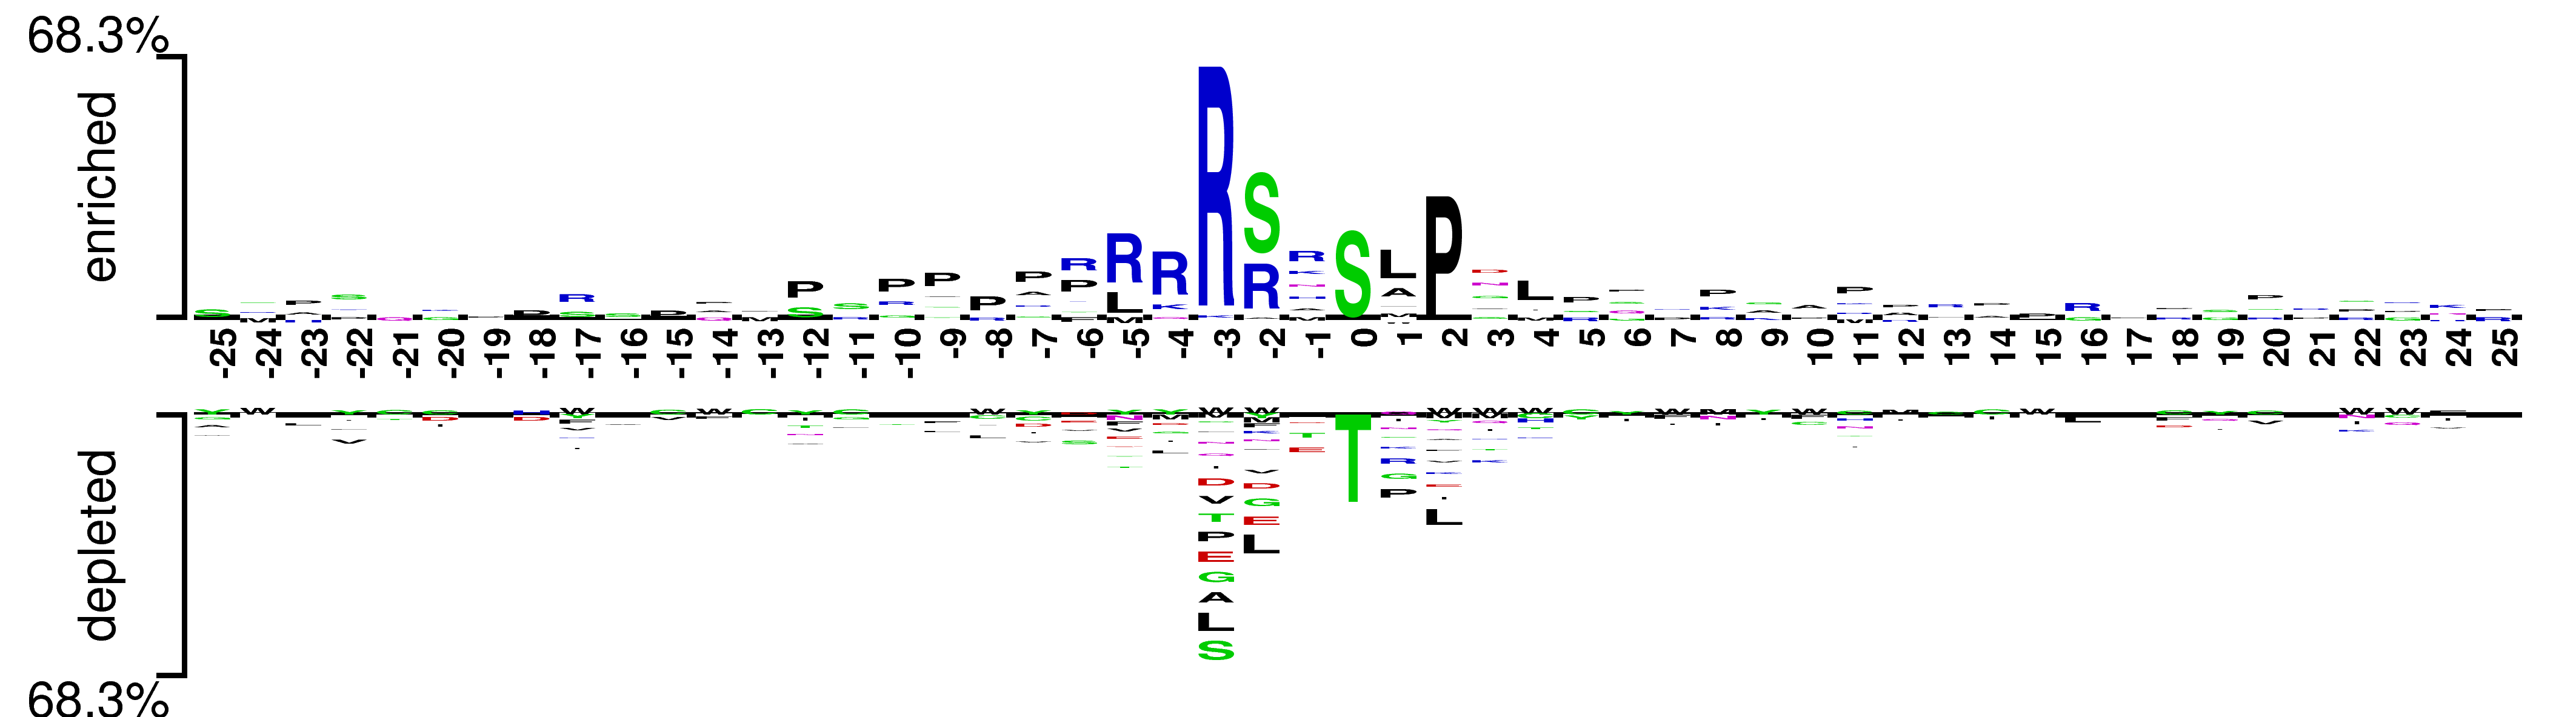

In [87]:
from IPython.display import Image
Image("data/14-3-3 positive vs 100000 sampled from whole st two sample logo.png")

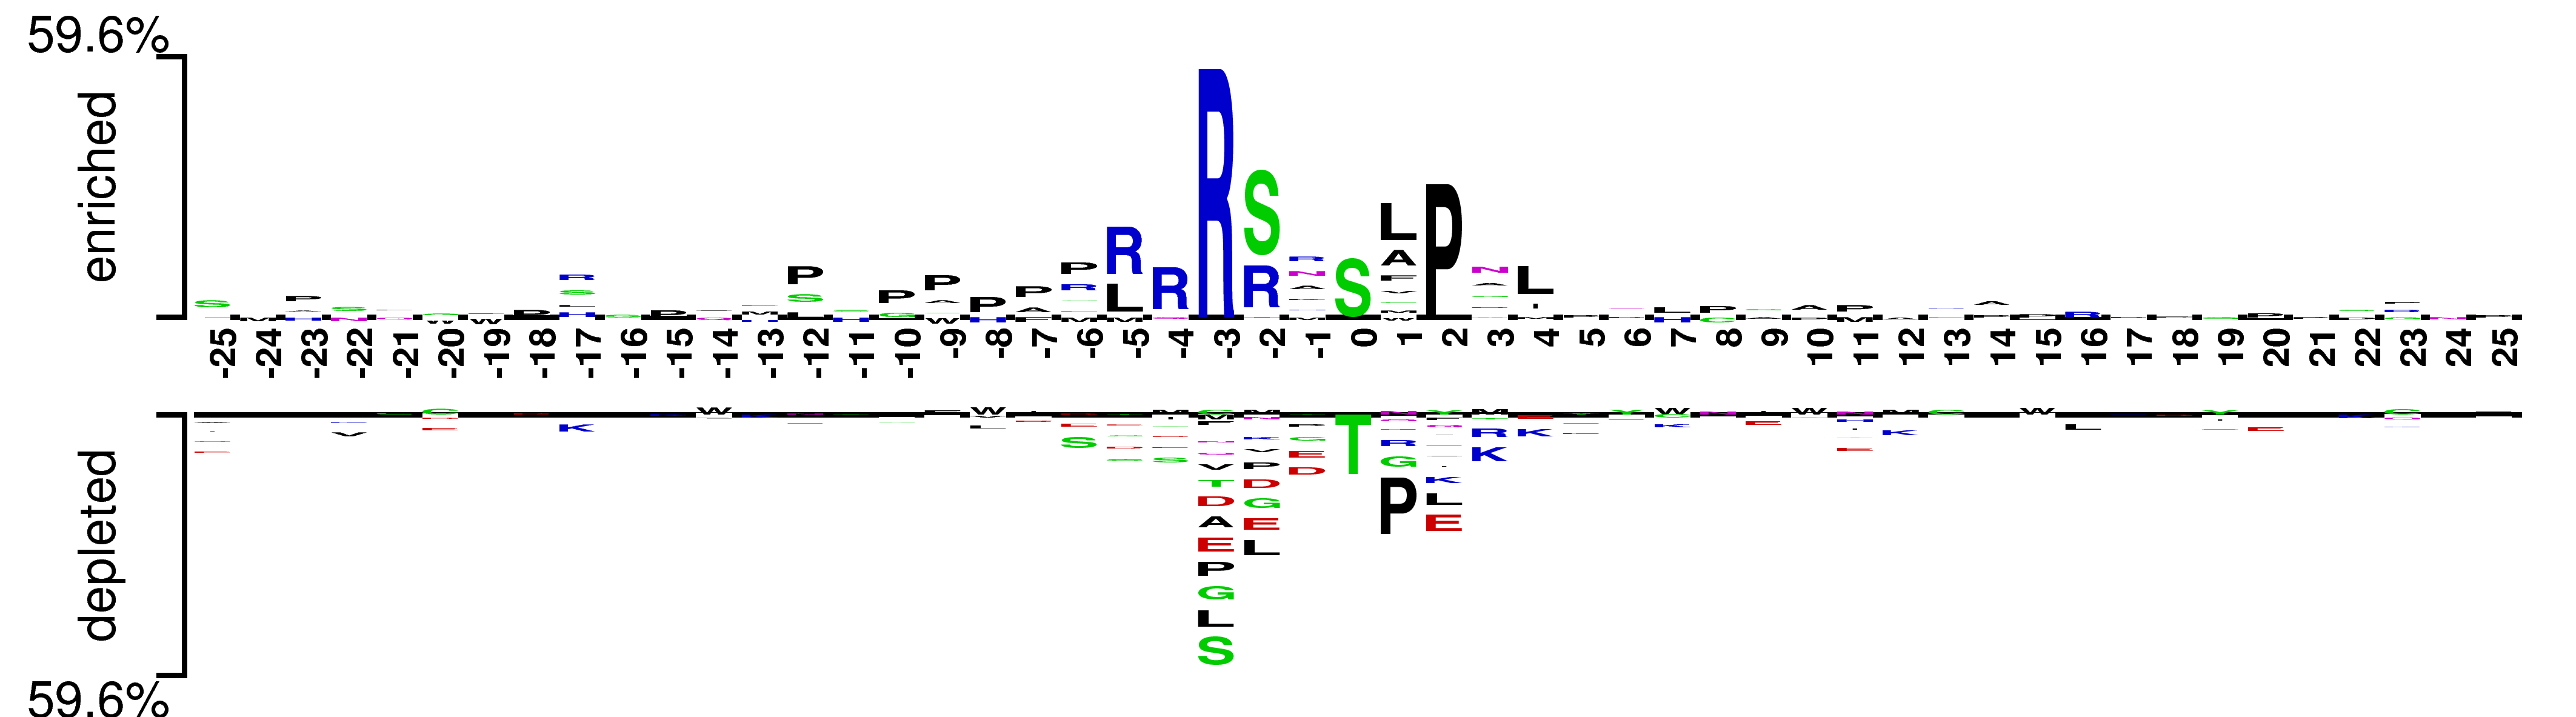

In [88]:
Image("data/14-3-3 positive vs all phosphorylation sites two sample logo.png")

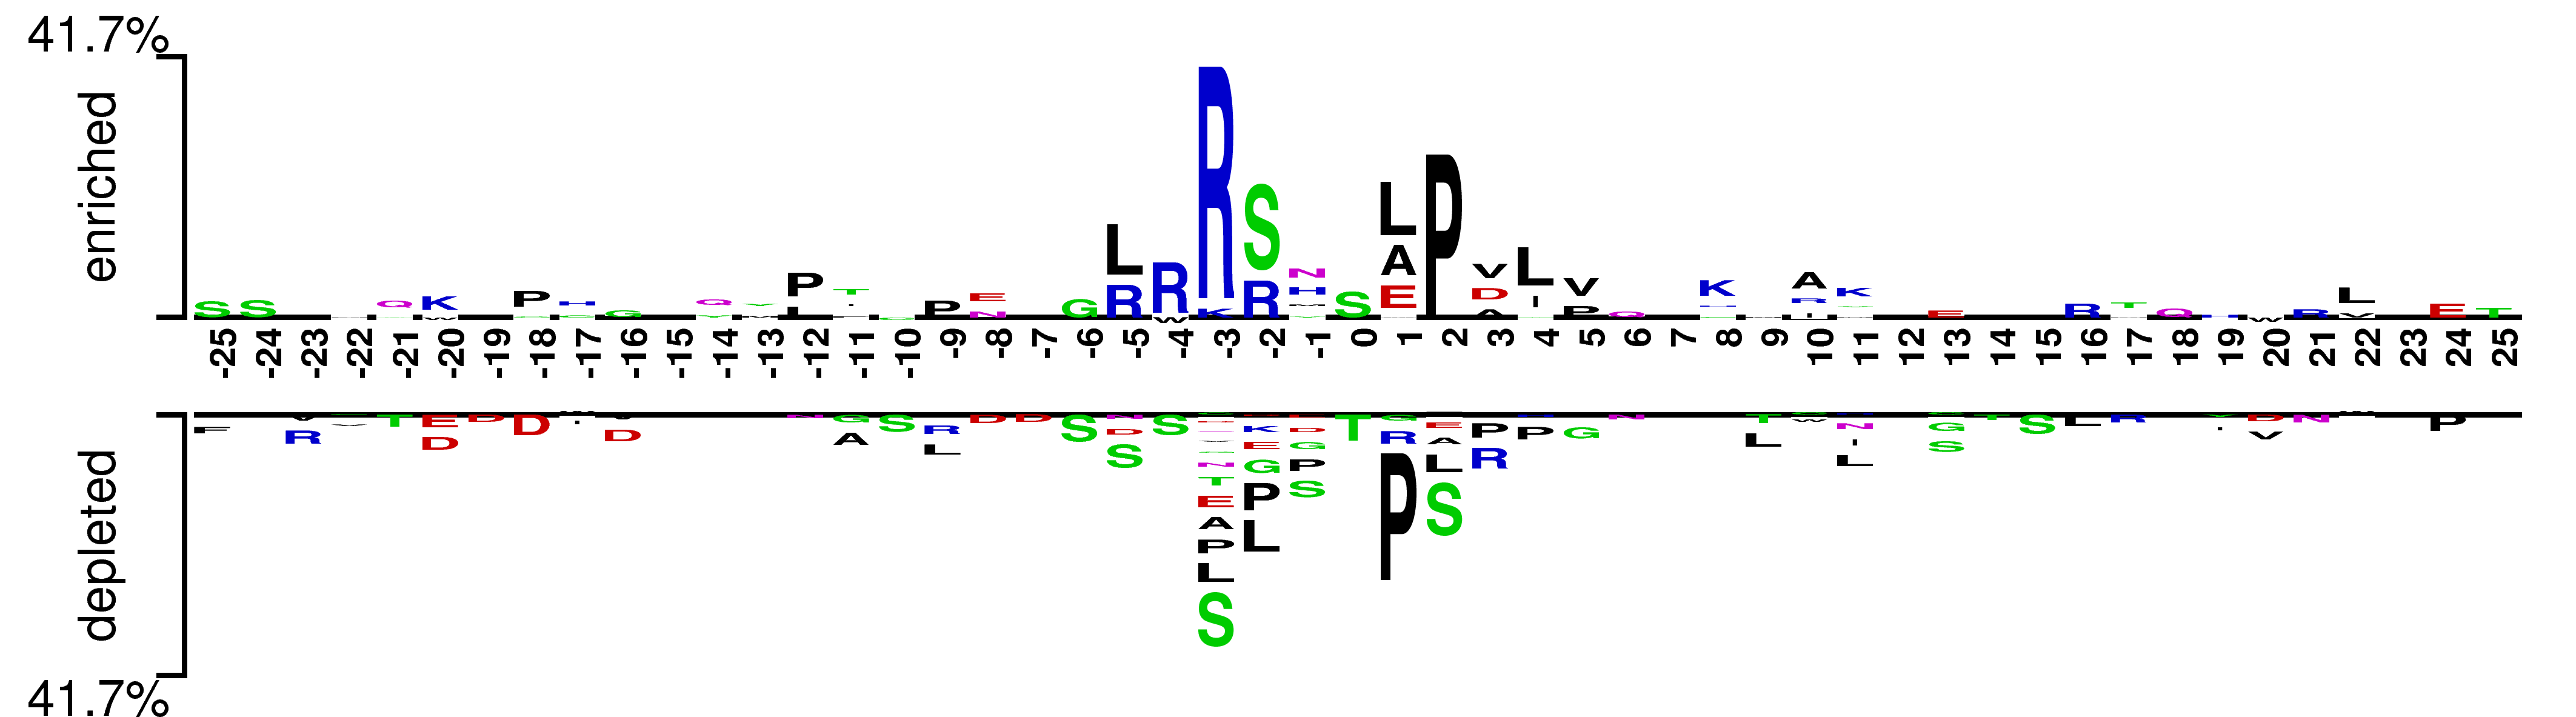

In [89]:
Image("data/14-3-3 positive vs negative two sample logo.png")

Task 26: we also extracted sequence related features including sequence-based features, physicochemical property-based features, and spatial mapping information-based features utilizing iFeature.

In [90]:
# def transfer_csv_data_into_fasta(csv_name, fasta_name, name_colum, sequence_column, left_flank_length=25, right_flank_length=25):
#     # transfer_csv_data_into_fasta, the protein sequence contains from the left_flank to the right_flank with the 
#     # phosphorylation site as center. The nomal amino acid are write in capital letter, the phosphorylation s/t are written in 
#     # lower case
#     df = pd.read_csv(csv_name)
#     with open(fasta_name+"_"+str(left_flank_length)+"_"+str(right_flank_length)+".fasta", 'w') as f:
#         for index, row in df.iterrows():
#             positions_st = len(row[sequence_column])//2
#             motif_sequence = row[sequence_column][positions_st-left_flank_length:positions_st+right_flank_length+1]                              
#             f.write(">"+ f"{row[name_colum]}\n{motif_sequence}\n")

In [91]:
# transfer_csv_data_into_fasta("data/1433_positive_51_window.csv", "data/1433_positive", "Site_Name", "Window_Sequence", left_flank_length=12, right_flank_length=12)
# transfer_csv_data_into_fasta("data/1433_negative_51_window.csv", "data/1433_negative", "Site_Name", "Window_Sequence", left_flank_length=12, right_flank_length=12)

In [92]:
# transfer_csv_data_into_fasta("data/all_phosphorylation_sites_51_window.csv", "data/all_phosphorylation_sites_51_window", "Site_Name", "Window_Sequence", left_flank_length=12, right_flank_length=12)
# transfer_csv_data_into_fasta("data/protein_sites_51_window.csv", "data/all_protein_sites_51_window", "Site_Name", "Window_Sequence", left_flank_length=12, right_flank_length=12)

In [93]:
# import iFeatureOmegaCLI
# import os
# import numpy as np
# import pandas as pd

# def amino_acid_feature_extraction(fasta_file_name, output_folder, feature_list):
#     # Check if output_folder exists, if not, create it
#     if not os.path.exists(output_folder):
#         os.makedirs(output_folder)
    
#     # using iFeatureOmegaCLI to extract feature in the protein, in defined feature_list
#     protein = iFeatureOmegaCLI.iProtein(fasta_file_name)
#     for feature in feature_list:
#         feature_file_path = os.path.join(output_folder, f"{feature}.pkl")
        
#         # Skip if the feature file already exists
#         if os.path.exists(feature_file_path):
#             print(f"Skipped {feature}, file already exists.")
#             continue
        
#         # Extract the feature
#         protein.get_descriptor(feature)
#         result = protein.encodings
#         result.set_index(result.columns[0], inplace=True)
#         result.columns = [f"{feature}_{name}" for name in result.columns]
        
#         # Save the result to a .pkl file
#         result.to_pickle(feature_file_path)
#         print(f"Saved {feature} result to {feature_file_path}")

In [94]:
# feature_list=['EAAC',
#  'CKSAAP type 1','DDE', 'binary', 'AESNN3','EGAAC','CKSAAGP type 1','AAIndex','ZScale','BLOSUM62','NMBroto',
# 'Moran','Geary','CTDC','CTDT','CTDD','CTriad','SOCNumber','QSOrder','PAAC','APAAC','OPF_10bit','ASDC','DistancePair','ACC','PseKRAAC type 1']
# amino_acid_feature_extraction("data/1433_negative_12_12.fasta", "data/1433_negative_aminoacid_feature_12_12", feature_list)
# amino_acid_feature_extraction("data/1433_positive_12_12.fasta", "data/1433_positive_aminoacid_feature_12_12", feature_list)

In [95]:
# feature_list=['EAAC',
#  'CKSAAP type 1','DDE', 'binary', 'AESNN3','EGAAC','CKSAAGP type 1','AAIndex','ZScale','BLOSUM62','NMBroto',
# 'Moran','Geary','CTDC','CTDT','CTDD','CTriad','SOCNumber','QSOrder','PAAC','APAAC','OPF_10bit','ASDC','DistancePair','ACC','PseKRAAC type 1']
# amino_acid_feature_extraction("data/all_phosphorylation_sites_51_window_12_12.fasta", "data/all_phosphorylation_sites_51_window_12_12", feature_list)

In [96]:
# feature_list=['EAAC',
#  'CKSAAP type 1','DDE', 'binary', 'AESNN3','EGAAC','CKSAAGP type 1','AAIndex','ZScale','BLOSUM62','NMBroto',
# 'Moran','Geary','CTDC','CTDT','CTDD','CTriad','SOCNumber','QSOrder','PAAC','APAAC','OPF_10bit','ASDC','DistancePair','ACC','PseKRAAC type 1']

# amino_acid_feature_extraction("data/all_protein_sites_51_window_25_25.txt", "data/all_protein_aminoacid_feature_25_25", feature_list)

In [97]:
# umap analysis the positive, negative and whole human protemo site
# since all those features are high dimension feature, then each features scheme was further processed with dimension reduction using UMAP, and the positive, negative and whole proteome sequence dataset was projected to the UMAP, the result show XXX.  

In [98]:
# %matplotlib inline
# import matplotlib
# print(matplotlib.get_backend())

# import os
# import pandas as pd
# import umap
# import matplotlib.pyplot as plt


# def plot_umap_for_scheme(folder1, folder2, scheme_name, first_df_name, second_df_name):
#     scheme_file1 = os.path.join(folder1, f"{scheme_name}.pkl")
#     scheme_file2 = os.path.join(folder2, f"{scheme_name}.pkl")
#     if not os.path.exists(scheme_file1) or not os.path.exists(scheme_file2):
#         print(f"Files for {scheme_name} not found in both folders.")
#         return
        
#     # Load the scheme files
#     df1_scheme = pd.read_pickle(scheme_file1)
#     df2_scheme = pd.read_pickle(scheme_file2)
    
#     # Ensure both DataFrames have the same scheme columns
#     common_columns = list(set(df1_scheme.columns).intersection(set(df2_scheme.columns)))
#     df1_scheme = df1_scheme[common_columns]
#     df2_scheme = df2_scheme[common_columns]
    
#     # Concatenate the two DataFrames
#     df_combined = pd.concat([df1_scheme, df2_scheme], ignore_index=True)


#     # n_neighbors: Try reducing it
#     # Current: n_neighbors=15
#     # Try: n_neighbors=5 or 10
#     # This will focus more on local structure and might make clusters more distinct
#     # However, too low (like 2) might make the visualization too fragmented
    
    
#     # min_dist: Try lowering it
#     # Current: min_dist=0.1
#     # Try: min_dist=0.01 or 0.05
#     # This will allow points within clusters to pack more tightly
#     # Makes clusters more visible by increasing space between them
#     # Initialize UMAP object
    
#     umap_model = umap.UMAP(n_neighbors=5, min_dist=0.01, n_components=2, random_state=42)
    
#     # Fit and transform the combined data to 2D
#     umap_projection = umap_model.fit_transform(df_combined)
    
#     # Separate the projections for df1 and df2
#     umap_projection_df1 = umap_projection[:len(df1_scheme)]
#     umap_projection_df2 = umap_projection[len(df1_scheme):]
    
#     # Plotting with improvements
#     plt.figure(figsize=(12, 10))
    
#     # Plot blue points first (background)
#     plt.scatter(umap_projection_df2[:, 0], umap_projection_df2[:, 1], 
#                c='blue', label=second_df_name, 
#                s=20, alpha=0.3)  # Increased size but made transparent
    
#     # Plot red points on top with larger size and full opacity
#     plt.scatter(umap_projection_df1[:, 0], umap_projection_df1[:, 1], 
#                c='red', label=first_df_name,
#                s=40, alpha=1.0)  # Larger size and full opacity
    
#     # Optional: Add edge color to red points to make them more visible
#     plt.scatter(umap_projection_df1[:, 0], umap_projection_df1[:, 1],
#                facecolors='none', edgecolors='darkred',
#                s=40, linewidth=1)  # Even larger size for the edges
    
#     plt.title(f"UMAP Projection for {scheme_name}", fontsize=14, pad=20)
#     plt.xlabel("UMAP1", fontsize=12)
#     plt.ylabel("UMAP2", fontsize=12)
    
#     # Improve legend
#     plt.legend(fontsize=10, markerscale=2)
    
#     # Optional: Add grid for better readability
#     plt.grid(True, linestyle='--', alpha=0.3)
    
#     # Adjust layout
#     plt.tight_layout()
#     plt.show()

In [99]:
# # List of scheme names
# scheme_names = ['EAAC',
#  'CKSAAP type 1','DDE', 'binary', 'AESNN3','EGAAC','CKSAAGP type 1','AAIndex','ZScale','BLOSUM62','NMBroto',
# 'Moran','Geary','CTDC','CTDT','CTDD','CTriad','SOCNumber','QSOrder','PAAC','APAAC','OPF_10bit','ASDC','DistancePair','ACC','PseKRAAC type 1']

# # Define folders where the scheme files are stored
# folder1 = 'data/1433_positive_aminoacid_feature_12_12'
# folder2 = 'data/1433_negative_aminoacid_feature_12_12'

# # Plot UMAP for each scheme name
# for scheme_name in scheme_names:
#     plot_umap_for_scheme(folder1, folder2, scheme_name, "14-3-3 binding positive sites", "14-3-3 binding negative sites")

In [100]:
# # List of scheme names
# scheme_names = ['EAAC',
#  'CKSAAP type 1','DDE', 'binary', 'AESNN3','EGAAC','CKSAAGP type 1','AAIndex','ZScale','BLOSUM62','NMBroto',
# 'Moran','Geary','CTDC','CTDT','CTDD','CTriad','SOCNumber','QSOrder','PAAC','APAAC','OPF_10bit','ASDC','DistancePair','ACC','PseKRAAC type 1']

# # compare 14-3-3 with all phospho sites
# folder1 = 'data/1433_positive_aminoacid_feature_12_12'
# df_all_phos_folder = "data/all_phosphorylation_sites_51_window_12_12"

# for scheme_name in scheme_names:
#     plot_umap_for_scheme(folder1, df_all_phos_folder, scheme_name, "14-3-3 binding sites", "all_human_phospho_sites")

In [101]:
# # List of scheme names
# scheme_names = ['EAAC',
#  'CKSAAP type 1','DDE', 'binary', 'AESNN3','EGAAC','CKSAAGP type 1','AAIndex','ZScale','BLOSUM62','NMBroto',
# 'Moran','Geary','CTDC','CTDT','CTDD','CTriad','SOCNumber','QSOrder','PAAC','APAAC','OPF_10bit','ASDC','DistancePair','ACC','PseKRAAC type 1']

# folder1 = 'data/1433_positive_aminoacid_feature_25_25'
# df_all_folder = "data/all_protein_aminoacid_feature_25_25"

# for scheme_name in scheme_names:
#     plot_umap_for_scheme(folder1, df_all_folder, scheme_name, "14-3-3 binding sites", "all_human_st_sites")

Task 27: Download Phospholingo predicted scores. We found that 14-3-3 binding sites exhibit higher phosphorylation potential compared to all known phosphorylation sites and all serine or threonine residues in the proteome.

In [102]:
# load 14-3-3 binding dataset
df_1433 = pd.read_csv("data/Table 1.csv")
df_1433
# select positive human sample to see the distribution
df_positive_human = df_1433[(df_1433["label"] == 1)]
df_positive_human["prot_id_position"] = df_positive_human["human homology accession"] + "_" + df_positive_human['human homology site without letter'].astype(str)
df_positive_human.head(2)

/var/folders/jl/gnkp_hvs3zqb957750yclnqr0000gn/T/ipykernel_42183/2046687628.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_positive_human["prot_id_position"] = df_positive_human["human homology accession"] + "_" + df_positive_human['human homology site without letter'].astype(str)


,human homology accession,human homology site without letter,human Site and Mutation,label,PMID,prot_id_position
0,P43681,467,S467s,1,20141511,P43681_467
1,P11362,779,S779s,1,23564461,P11362_779


In [103]:
# load known phosphorylation binding dataset
df_known_phospho_sites = pd.read_csv("data/konwn_human_phosphorylated_site_from_phosphosite.csv")

# Function to transform values
def transform_value(value):
    parts = value.split('_')
    if len(parts) == 3:
        return f"{parts[0]}_{parts[2]}"
    return value
    
df_known_phospho_sites["prot_id_position"] = df_known_phospho_sites["Unnamed: 0"].apply(transform_value)

df_known_phospho_sites.head(2)

,Unnamed: 0,GENE,PROTEIN,ACC_ID,HU_CHR_LOC,MOD_RSD,SITE_GRP_ID,ORGANISM,MW_kD,DOMAIN,SITE_+/-7_AA,LT_LIT,MS_LIT,MS_CST,CST_CAT#,Ambiguous_Site,prot_id_position
0,P31946_T_2,YWHAB,14-3-3 beta,P31946,20q13.12,T_2,15718712,human,28.08,NaN,______MtMDksELV,NaN,3.0,1.0,NaN,0,P31946_2
1,P31946_S_6,YWHAB,14-3-3 beta,P31946,20q13.12,S_6,15718709,human,28.08,NaN,__MtMDksELVQkAk,NaN,8.0,NaN,NaN,0,P31946_6


In [104]:
# download the predicted score of whole human proteome from PhosphoLingo
# https://github.com/jasperzuallaert/PhosphoLingo/blob/master/predictions/preds_swissprot_ST.csv

In [105]:
phospholingo_file_path = "data/preds_swissprot_ST.csv"
current_directory = os.getcwd()
full_path = os.path.join(current_directory, phospholingo_file_path)
df_phospholingo_score = pd.read_csv(full_path)
df_phospholingo_score["prot_id_position"] = df_phospholingo_score["prot_id"] + "_" + df_phospholingo_score["position"].astype(str)
df_phospholingo_score.head(2)

,prot_id,position,pred,prot_id_position
0,A0A087X1C5,54,0.051,A0A087X1C5_54
1,A0A087X1C5,70,0.039,A0A087X1C5_70


In [106]:
# Filter rows in df_phospholingo_score_human based on the common Uniprot IDs
common_1433_phospholingo = df_phospholingo_score[df_phospholingo_score["prot_id_position"].isin(df_positive_human["prot_id_position"])]
common_known_phospho_sites_phospholingo = df_phospholingo_score[df_phospholingo_score["prot_id_position"].isin(df_known_phospho_sites["prot_id_position"])]

In [107]:
from scipy.stats import ks_2samp
# Extract the phospho Score data from both DataFrames
phospholingo_score_1433 = common_1433_phospholingo['pred']
phospholingo_score_known_phosphosites = common_known_phospho_sites_phospholingo["pred"]

# Perform the two-sample Kolmogorov-Smirnov test
ks_statistic, p_value = ks_2samp(phospholingo_score_1433, phospholingo_score_known_phosphosites)

# Define a significance level (alpha)
alpha = 0.05

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Compare p-value to the significance level
if p_value < alpha:
    print("Reject the null hypothesis: The two distributions are significantly different.")
else:
    print("Fail to reject the null hypothesis: The two distributions are not significantly different.")

KS Statistic: 0.4226906986382443
P-value: 6.034406063297958e-67
Reject the null hypothesis: The two distributions are significantly different.


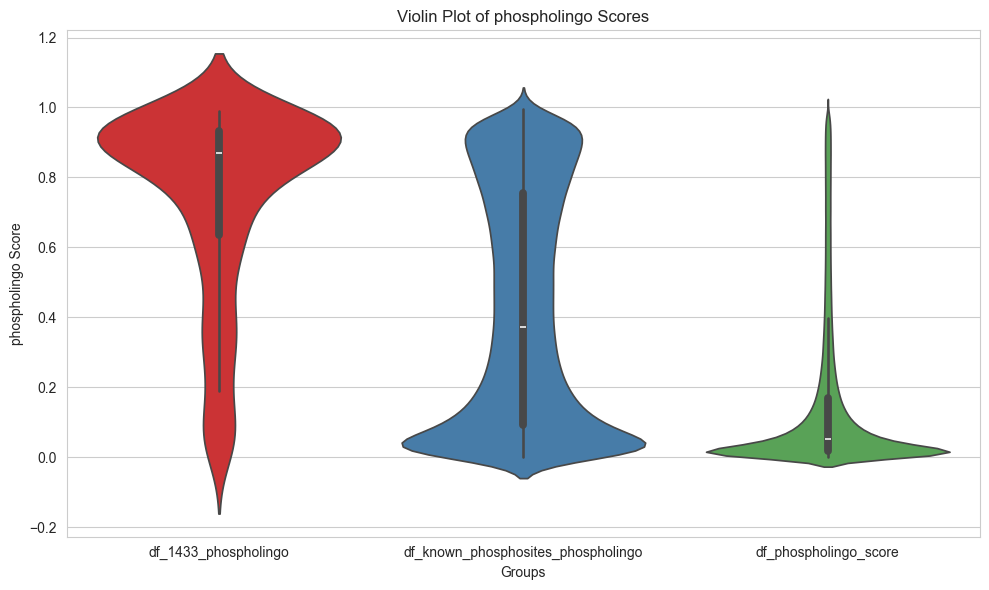

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined DataFrame for the violin plot
combined_data = pd.concat([common_1433_phospholingo['pred'], common_known_phospho_sites_phospholingo['pred'], df_phospholingo_score["pred"]], axis=1)
combined_data.columns = ['df_1433_phospholingo', 'df_known_phosphosites_phospholingo', 'df_phospholingo_score']

# Create a violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=combined_data, palette='Set1')
plt.title('Violin Plot of phospholingo Scores')
plt.ylabel('phospholingo Score')
plt.xlabel('Groups')

# Show the plot
plt.tight_layout()
plt.show()

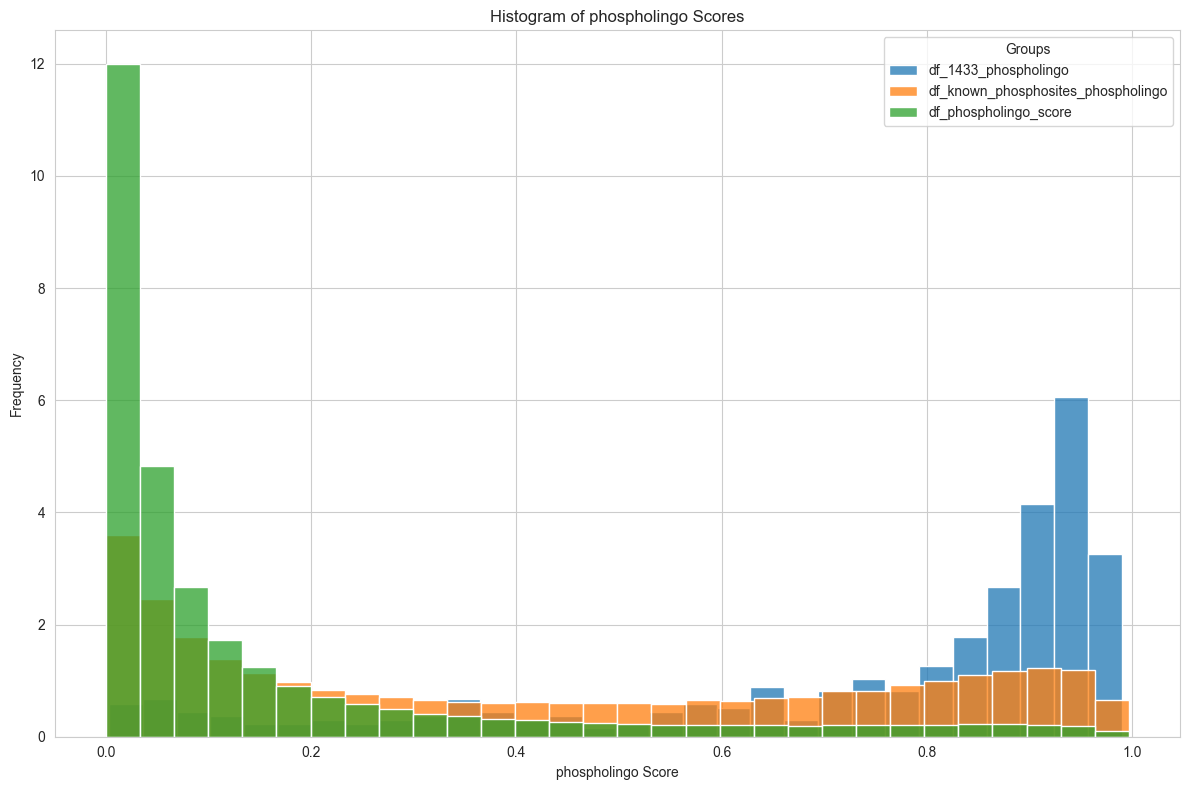

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a combined DataFrame for the histogram plot
combined_data = pd.concat([common_1433_phospholingo['pred'], common_known_phospho_sites_phospholingo['pred'], df_phospholingo_score["pred"]], axis=1)
combined_data.columns = ['df_1433_phospholingo', 'df_known_phosphosites_phospholingo', 'df_phospholingo_score']

# Create a histogram plot for each group
plt.figure(figsize=(12, 8))

# Plot histograms for each column in the combined DataFrame
for column in combined_data.columns:
    sns.histplot(combined_data[column], label=column, kde=False, bins=30, stat='density')

# Adding labels and title
plt.title('Histogram of phospholingo Scores')
plt.ylabel('Frequency')
plt.xlabel('phospholingo Score')
plt.legend(title='Groups')

# Show the plot
plt.tight_layout()
plt.show()